In [59]:
"""
Otto推荐系统 + 动态PPI + 多维度评估
包含：
实验1：不同召回策略的PPI评估对比
实验2：不同会话长度的PPI评估对比
实验3：不同时间窗口的PPI评估对比
实验4：集成学习PPI对比
"""

import os
import gc
import json
import csv
import math
import random
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==================== 配置参数 ====================

class Config:
    DATA_DIR = Path("/kaggle/input/competitions/otto-recommender-system")
    TRAIN_PATH = DATA_DIR / "train.jsonl"
    TEST_PATH = DATA_DIR / "test.jsonl"
    OUT_PATH = Path("/kaggle/working/submission.csv")
    
    # 召回参数
    MAX_TRAIN_SESSIONS_FOR_COVISIT = 300_000
    MAX_SESSION_AIDS = 30
    CLICK_WINDOW = 5
    BUY_WINDOW = 5
    TRANSFER_WINDOW = 10
    TOPN_NEIGHBORS = 120
    TOP_POPULAR = 150
    
    # 锚点参数
    ANCHORS_PER_SESSION = 8
    BUY_ANCHORS_PER_SESSION = 8
    MULTI_LEVEL_ANCHORS = 4
    
    # 权重分配
    HISTORY_WEIGHTS = {0: 1.0, 1: 6.0, 2: 5.0}
    NEIGHBOR_WEIGHTS = {'click': 0.8, 'cart': 0.6, 'order': 0.4}
    TRANSFER_WEIGHTS = {'click_to_cart': 0.5, 'cart_to_order': 0.7}
    LONG_TERM_WEIGHT = 0.4
    CATEGORY_WEIGHT = 0.3
    
    # PPI参数
    PPI_MIN_STRENGTH = 0.02
    PPI_MAX_STRENGTH = 0.35
    USE_PPI_FOR_SCORING = True
    
    # 实验参数
    COVIST_SESSIONS = 8000
    TRAIN_SESSIONS = 6000
    VAL_SESSIONS = 4000
    NUM_TRIALS = 8
    NS = [100, 200, 500, 1000, 2000, 3000]
    
    ALPHA = 0.05
    POWER_TARGET = 0.8
    NULL_HYPOTHESIS = {'clicks': 0.35, 'carts': 0.45, 'orders': 0.55}
    
    RANDOM_SEED = 42
    TYPE_STR_TO_INT = {"clicks": 0, "carts": 1, "orders": 2}
    TYPE_WEIGHT = {0: 1, 1: 6, 2: 5}
    
    # 召回策略配置
    RECALL_STRATEGIES = {
        'history_only': 'History Only',
        'neighbor_only': 'Neighbor Only',
        'transfer_only': 'Transfer Only',
        'category_only': 'Category Only',
        'long_term_only': 'Long Term Only',
        'full_strategy': 'Full Strategy'
    }
    
    # 会话长度分组
    SESSION_LENGTH_GROUPS = {
        'short': (0, 10, 'Short (<10)'),
        'medium': (10, 30, 'Medium (10-30)'),
        'long': (30, float('inf'), 'Long (>30)')
    }
    
    # 时间窗口配置
    TIME_WINDOWS = {
        'early': (0, 0.33, 'Early 33%'),
        'middle': (0.33, 0.66, 'Middle 33%'),
        'late': (0.66, 1.0, 'Late 33%')
    }

print("Config loaded successfully")

Config loaded successfully


In [60]:
# ==================== PPI核心函数 ====================

def ppi_mean_pointestimate(Y, Yhat, Yhat_unlabeled, lam=1):
    """PPI点估计"""
    Y = np.array(Y)
    Yhat = np.array(Yhat)
    Yhat_unlabeled = np.array(Yhat_unlabeled)
    return np.mean(Yhat_unlabeled * lam) + np.mean(Y - lam * Yhat)

def ppi_mean_ci(Y, Yhat, Yhat_unlabeled, alpha=0.05, lam=1, alternative='two-sided'):
    """PPI置信区间"""
    Y = np.array(Y)
    Yhat = np.array(Yhat)
    Yhat_unlabeled = np.array(Yhat_unlabeled)
    
    n = len(Y)
    N = len(Yhat_unlabeled)
    
    pointest = ppi_mean_pointestimate(Y, Yhat, Yhat_unlabeled, lam)
    
    imputed_std = np.std(lam * Yhat_unlabeled) / np.sqrt(N) if N > 0 else 0
    rectifier_std = np.std(Y - lam * Yhat) / np.sqrt(n) if n > 0 else 0
    se = np.sqrt(imputed_std**2 + rectifier_std**2)
    
    if alternative == 'two-sided':
        z = stats.norm.ppf(1 - alpha/2)
        return pointest - z*se, pointest + z*se
    elif alternative == 'larger':
        z = stats.norm.ppf(1 - alpha)
        return pointest - z*se, np.inf
    else:
        z = stats.norm.ppf(1 - alpha)
        return -np.inf, pointest + z*se

def ppi_optimal_lam(Y, Yhat, Yhat_unlabeled):
    """计算最优λ（PPI++）"""
    Y = np.array(Y)
    Yhat = np.array(Yhat)
    Yhat_unlabeled = np.array(Yhat_unlabeled)
    
    n = len(Y)
    N = len(Yhat_unlabeled)
    
    if n < 2 or N < 2:
        return 1.0
    
    var_Yhat = np.var(Yhat)
    var_Yhat_unlabeled = np.var(Yhat_unlabeled)
    cov_Y_Yhat = np.cov(Y, Yhat)[0, 1]
    
    if var_Yhat + var_Yhat_unlabeled * n/N > 0:
        lam = cov_Y_Yhat / (var_Yhat + var_Yhat_unlabeled * n/N)
    else:
        lam = 1.0
    return np.clip(lam, 0, 1)

def crossppi_mean_ci(Y, Yhat_matrix, Yhat_unlabeled_matrix, alpha=0.05):
    """交叉PPI（多模型）"""
    Y = np.array(Y)
    Yhat_matrix = np.array(Yhat_matrix)
    Yhat_unlabeled_matrix = np.array(Yhat_unlabeled_matrix)
    
    Yhat_avg = np.mean(Yhat_matrix, axis=1)
    Yhat_unlabeled_avg = np.mean(Yhat_unlabeled_matrix, axis=1)
    
    return ppi_mean_ci(Y, Yhat_avg, Yhat_unlabeled_avg, alpha=alpha, lam=1)

print("PPI core functions loaded")

PPI core functions loaded


In [61]:
# ==================== PPI推荐器类（修复缩进） ====================

class CorrectPPIRecommender:
    """正确的PPI实现（单一模型）"""
    
    def __init__(self, min_strength=0.02, max_strength=0.35):
        self.min_strength = min_strength
        self.max_strength = max_strength
        self.storage = {
            'clicks': {'Y': [], 'Yhat': [], 'Yhat_unlabeled': []},
            'carts': {'Y': [], 'Yhat': [], 'Yhat_unlabeled': []},
            'orders': {'Y': [], 'Yhat': [], 'Yhat_unlabeled': []}
        }
        self.lam = {'clicks': 1.0, 'carts': 1.0, 'orders': 1.0}
        self.recall_stats = {
            'clicks': {'labeled': [], 'predicted': [], 'strength': []},
            'carts': {'labeled': [], 'predicted': [], 'strength': []},
            'orders': {'labeled': [], 'predicted': [], 'strength': []}
        }
        self.score_correction = {'clicks': 0.0, 'carts': 0.0, 'orders': 0.0}
        
    def update_recall_stats(self, action_type, labeled_recall, predicted_recall, predicted_unlabeled=None):
        self.recall_stats[action_type]['labeled'].append(labeled_recall)
        self.recall_stats[action_type]['predicted'].append(predicted_recall)
        
        self.storage[action_type]['Y'].append(labeled_recall)
        self.storage[action_type]['Yhat'].append(predicted_recall)
        
        if predicted_unlabeled is not None:
            self.storage[action_type]['Yhat_unlabeled'].append(predicted_unlabeled)
        else:
            self.storage[action_type]['Yhat_unlabeled'].append(predicted_recall)
        
        if len(self.storage[action_type]['Y']) >= 10:
            Y = np.array(self.storage[action_type]['Y'])
            Yhat = np.array(self.storage[action_type]['Yhat'])
            Yhat_unlabeled = np.array(self.storage[action_type]['Yhat_unlabeled'])
            self.lam[action_type] = ppi_optimal_lam(Y, Yhat, Yhat_unlabeled)
            
            strength = self._compute_dynamic_strength(action_type)
            self.recall_stats[action_type]['strength'].append(strength)
            
            bias = np.mean(self.recall_stats[action_type]['predicted']) - np.mean(self.recall_stats[action_type]['labeled'])
            self.score_correction[action_type] = bias * strength
    
    def _compute_dynamic_strength(self, action_type):
        labeled = np.array(self.recall_stats[action_type]['labeled'])
        predicted = np.array(self.recall_stats[action_type]['predicted'])
        if len(labeled) < 10:
            return self.min_strength
        errors = predicted - labeled
        bias = np.mean(errors)
        bias_std = np.std(errors)
        correlation = np.corrcoef(labeled, predicted)[0, 1] if len(labeled) > 1 else 0
        correlation_factor = max(0, min(1, correlation))
        stability_factor = 1 / (1 + bias_std) if bias_std > 0 else 1
        strength = self.min_strength + (self.max_strength - self.min_strength) * correlation_factor * stability_factor
        if abs(bias) > 0.2:
            strength *= 0.5
        return np.clip(strength, self.min_strength, self.max_strength)
    
    def get_current_strength(self, action_type):
        if self.recall_stats[action_type]['strength']:
            return self.recall_stats[action_type]['strength'][-1]
        return self.min_strength
    
    def get_correction(self, action_type):
        return self.score_correction.get(action_type, 0.0)
    
    def correct_score(self, action_type, original_score):
        correction = self.get_correction(action_type)
        return max(0, original_score - correction)
    
    def compute_ppi_recall(self, action_type):
        if len(self.storage[action_type]['Y']) < 5:
            return np.mean(self.recall_stats[action_type]['predicted']) if self.recall_stats[action_type]['predicted'] else 0
        
        Y = np.array(self.storage[action_type]['Y'])
        Yhat = np.array(self.storage[action_type]['Yhat'])
        Yhat_unlabeled = np.array(self.storage[action_type]['Yhat_unlabeled'])
        
        return ppi_mean_pointestimate(Y, Yhat, Yhat_unlabeled, lam=self.lam[action_type])
    
    def compute_confidence_interval(self, action_type, alpha=0.05):
        if len(self.storage[action_type]['Y']) < 10:
            return 0, 1
        
        Y = np.array(self.storage[action_type]['Y'])
        Yhat = np.array(self.storage[action_type]['Yhat'])
        Yhat_unlabeled = np.array(self.storage[action_type]['Yhat_unlabeled'])
        
        lower, upper = ppi_mean_ci(Y, Yhat, Yhat_unlabeled, alpha=alpha, lam=self.lam[action_type])
        return np.clip(lower, 0, 1), np.clip(upper, 0, 1)
    
    def get_classical_interval(self, action_type, alpha=0.05):
        labeled = np.array(self.recall_stats[action_type]['labeled'])
        if len(labeled) < 10:
            return 0, 1
        mean = np.mean(labeled)
        se = np.std(labeled) / np.sqrt(len(labeled))
        z_score = stats.norm.ppf(1 - alpha/2)
        lower = mean - z_score * se
        upper = mean + z_score * se
        return np.clip(lower, 0, 1), np.clip(upper, 0, 1)
    
    def get_weighted_recall(self):
        return (0.10 * self.compute_ppi_recall('clicks') + 
                0.30 * self.compute_ppi_recall('carts') + 
                0.60 * self.compute_ppi_recall('orders'))
    
    def get_weighted_confidence_interval(self, alpha=0.05):
        """计算加权召回率的置信区间"""
        # 使用Delta方法组合三个动作类型的置信区间
        clicks_ci = self.compute_confidence_interval('clicks', alpha)
        carts_ci = self.compute_confidence_interval('carts', alpha)
        orders_ci = self.compute_confidence_interval('orders', alpha)
        
        # 加权组合
        weights = {'clicks': 0.10, 'carts': 0.30, 'orders': 0.60}
        
        lower = (weights['clicks'] * clicks_ci[0] + 
                 weights['carts'] * carts_ci[0] + 
                 weights['orders'] * orders_ci[0])
        
        upper = (weights['clicks'] * clicks_ci[1] + 
                 weights['carts'] * carts_ci[1] + 
                 weights['orders'] * orders_ci[1])
        
        return (lower, upper)


DynamicPPIRecommender = CorrectPPIRecommender

In [62]:
# ==================== 基础工具函数 ====================

def event_type_to_int(t):
    if isinstance(t, str):
        return Config.TYPE_STR_TO_INT[t]
    return int(t)

def count_lines(path):
    cnt = 0
    with open(path, "r") as f:
        for _ in f:
            cnt += 1
    return cnt

def extract_item_category(aid):
    return aid // 10000

def get_recent_unique(aids, types=None, allowed_types=None, max_len=30):
    seen = set()
    result = []
    if types is None:
        iterator = zip(reversed(aids), [None] * len(aids))
    else:
        iterator = zip(reversed(aids), reversed(types))
    for aid, t in iterator:
        if allowed_types is not None and t not in allowed_types:
            continue
        if aid in seen:
            continue
        seen.add(aid)
        result.append(aid)
        if len(result) >= max_len:
            break
    return result

def add_pairs(counter_dict, items, window):
    n = len(items)
    for i in range(n):
        a = items[i]
        for j in range(i + 1, min(n, i + 1 + window)):
            b = items[j]
            if a == b:
                continue
            counter_dict[a][b] += 1
            counter_dict[b][a] += 1

def counterdict_to_topneighbors(counter_dict, topk=120):
    out = {}
    for aid, ctr in tqdm(counter_dict.items(), desc="Trim neighbors"):
        top_items = ctr.most_common(topk * 2)
        weighted_items = []
        for i, (nbr, weight) in enumerate(top_items):
            decay = 1 - (i / (topk * 2)) * 0.5
            weighted_items.append((nbr, weight * decay))
        weighted_items.sort(key=lambda x: -x[1])
        out[aid] = [x[0] for x in weighted_items[:topk]]
    return out

def add_self_scores_improved(scores, aids, types, type_weights):
    for pos, (aid, t) in enumerate(zip(reversed(aids), reversed(types))):
        recency = math.exp(-pos / 8)
        position_weight = 1 + (1 - pos / max(1, len(aids))) * 0.5
        weight = type_weights.get(t, 1.0) if isinstance(type_weights, dict) else type_weights
        scores[aid] += recency * weight * position_weight

def add_neighbor_scores_improved(scores, anchors, neighbor_map, mult, levels=3):
    current_anchors = anchors
    for level in range(levels):
        decay = mult * (0.6 ** level)
        new_anchors = []
        for a_pos, aid in enumerate(current_anchors):
            nbrs = neighbor_map.get(aid, [])
            for n_pos, nbr in enumerate(nbrs[:15]):
                if nbr == aid:
                    continue
                level_weight = 1 / ((a_pos + 1) * (n_pos + 1) * (level + 1))
                scores[nbr] += decay * level_weight
                new_anchors.append(nbr)
        current_anchors = new_anchors[:Config.MULTI_LEVEL_ANCHORS]

def add_category_scores(scores, aids, category_map):
    recent_aids = aids[-8:] if len(aids) >= 8 else aids
    recent_categories = [extract_item_category(aid) for aid in recent_aids]
    for cat in set(recent_categories):
        similar_items = category_map.get(cat, [])
        for aid in similar_items[:80]:
            scores[aid] += Config.CATEGORY_WEIGHT

def add_long_term_scores(scores, long_term_items):
    for aid in long_term_items[:50]:
        scores[aid] += Config.LONG_TERM_WEIGHT

def topk_from_scores(scores, fallback, k=20):
    result = []
    seen = set()
    category_count = defaultdict(int)
    sorted_items = sorted(scores.items(), key=lambda x: (-x[1], x[0]))
    
    for aid, score in sorted_items:
        if aid in seen:
            continue
        cat = extract_item_category(aid)
        if category_count[cat] >= 3:
            continue
        seen.add(aid)
        category_count[cat] += 1
        result.append(aid)
        if len(result) == k:
            return result
    
    for aid in fallback:
        if aid in seen:
            continue
        seen.add(aid)
        result.append(aid)
        if len(result) == k:
            return result
    return result[:k]

print("Utility functions loaded")

Utility functions loaded


In [63]:
# ==================== 数据加载 ====================

def load_sessions_to_cache(max_sessions):
    print(f"Loading {max_sessions} sessions to cache...")
    sessions = []
    with open(Config.TRAIN_PATH, "r") as f:
        for idx, line in enumerate(tqdm(f, desc="Loading sessions")):
            if idx >= max_sessions:
                break
            obj = json.loads(line)
            events = sorted(obj["events"], key=lambda x: x["ts"])
            sessions.append({'session_id': obj['session'], 'events': events, 'idx': idx})
    print(f"Loaded {len(sessions)} sessions")
    return sessions

def split_sessions(sessions, train_ratio=0.6):
    n = len(sessions)
    indices = list(range(n))
    random.shuffle(indices)
    train_size = int(n * train_ratio)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    train_sessions = [sessions[i] for i in train_indices]
    val_sessions = [sessions[i] for i in val_indices]
    print(f"Train sessions: {len(train_sessions)}")
    print(f"Validation sessions: {len(val_sessions)}")
    return train_sessions, val_sessions

# ==================== 构建共现矩阵 ====================

def build_multiple_co_visitation_matrices(sessions):
    print("Building multiple co-visitation matrices...")
    matrices = {}
    
    print("Building click co-visitation matrix...")
    matrices['click'] = build_matrix_by_type(sessions, [0])
    
    print("Building cart co-visitation matrix...")
    matrices['cart'] = build_matrix_by_type(sessions, [1])
    
    print("Building order co-visitation matrix...")
    matrices['order'] = build_matrix_by_type(sessions, [2])
    
    print("Building click->cart transition matrix...")
    matrices['click_to_cart'] = build_transition_matrix(sessions, [0], [1])
    
    print("Building cart->order transition matrix...")
    matrices['cart_to_order'] = build_transition_matrix(sessions, [1], [2])
    
    print("Building category map...")
    matrices['category_map'] = build_category_map(sessions)
    
    print("Building long term interest...")
    matrices['long_term_interest'] = build_long_term_interest(sessions)
    
    return matrices

def build_matrix_by_type(sessions, types):
    counter = defaultdict(Counter)
    for session in tqdm(sessions, desc="Building by type"):
        events = session['events']
        aids = [int(ev["aid"]) for ev in events]
        ev_types = [event_type_to_int(ev["type"]) for ev in events]
        filtered = [(aid, t) for aid, t in zip(aids, ev_types) if t in types]
        if len(filtered) < 2:
            continue
        filtered_aids = [aid for aid, _ in filtered]
        recent_all = get_recent_unique(filtered_aids, None, None, Config.MAX_SESSION_AIDS)
        add_pairs(counter, recent_all, Config.CLICK_WINDOW)
    return counterdict_to_topneighbors(counter, topk=Config.TOPN_NEIGHBORS)

def build_transition_matrix(sessions, source_types, target_types):
    counter = defaultdict(Counter)
    for session in tqdm(sessions, desc="Building transition matrix"):
        events = session['events']
        aids = [int(ev["aid"]) for ev in events]
        ev_types = [event_type_to_int(ev["type"]) for ev in events]
        source_items = [aid for aid, t in zip(aids, ev_types) if t in source_types]
        target_items = [aid for aid, t in zip(aids, ev_types) if t in target_types]
        if len(source_items) < 2 or len(target_items) < 1:
            continue
        recent_source = get_recent_unique(source_items, None, None, Config.MAX_SESSION_AIDS)
        recent_target = get_recent_unique(target_items, None, None, Config.MAX_SESSION_AIDS)
        for i, src in enumerate(recent_source):
            for j, tgt in enumerate(recent_target[:Config.TRANSFER_WINDOW]):
                if src == tgt:
                    continue
                counter[src][tgt] += 1 / (abs(i - j) + 1)
    return counterdict_to_topneighbors(counter, topk=Config.TOPN_NEIGHBORS // 2)

def build_category_map(sessions):
    category_map = defaultdict(list)
    for session in tqdm(sessions, desc="Building category map"):
        events = session['events']
        aids = [int(ev["aid"]) for ev in events]
        for aid in set(aids):
            cat = extract_item_category(aid)
            category_map[cat].append(aid)
    for cat in category_map:
        category_map[cat] = list(set(category_map[cat]))[:200]
    return category_map

def build_long_term_interest(sessions):
    long_term_counter = Counter()
    for session in tqdm(sessions, desc="Building long term interest"):
        events = session['events']
        aids = [int(ev["aid"]) for ev in events]
        types = [event_type_to_int(ev["type"]) for ev in events]
        for aid, t in zip(aids, types):
            long_term_counter[aid] += Config.TYPE_WEIGHT.get(t, 1)
    return [aid for aid, _ in long_term_counter.most_common(200)]

print("Data loading functions loaded")

Data loading functions loaded


In [64]:
# ==================== 召回策略类（添加双塔模型） ====================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

class ItemDataset(Dataset):
    """商品数据集"""
    def __init__(self, user_items, item_features, neg_sample_ratio=0.5):
        self.user_items = user_items
        self.item_features = item_features
        self.item_list = list(item_features.keys()) if item_features else []
        self.neg_sample_ratio = neg_sample_ratio
        self.pairs = []
        
        # 构建正样本对
        for user_id, items in user_items.items():
            for item in items[:50]:  # 限制每个用户最多50个商品
                if item in item_features:
                    self.pairs.append((user_id, item, 1))
        
        # 添加负样本
        n_neg = int(len(self.pairs) * neg_sample_ratio)
        for _ in range(n_neg):
            user_id = np.random.choice(list(user_items.keys()))
            neg_item = np.random.choice(self.item_list)
            self.pairs.append((user_id, neg_item, 0))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        user_id, item_id, label = self.pairs[idx]
        item_feat = self.item_features.get(item_id, np.zeros(32))
        return torch.tensor(item_feat, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

class TwoTowerModel(nn.Module):
    """双塔模型（带偏差纠正、混合采样、自监督学习）"""
    
    def __init__(self, input_dim=32, emb_dim=64, dropout=0.2):
        super(TwoTowerModel, self).__init__()
        
        # 用户塔（简化为embedding + MLP）
        self.user_embedding = nn.Embedding(200000, emb_dim)  # 最大20万用户
        
        # 物品塔
        self.item_encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, emb_dim)
        )
        
        # 偏差纠正层
        self.bias_layer = nn.Linear(emb_dim * 2, 1)
        
        # 自监督学习头
        self.ssl_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, emb_dim)
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def encode_user(self, user_id):
        """编码用户"""
        if isinstance(user_id, int):
            user_id = torch.tensor([user_id])
        return self.user_embedding(user_id)
    
    def encode_item(self, item_features):
        """编码商品"""
        return self.item_encoder(item_features)
    
    def forward(self, user_id, item_features, return_embeddings=False):
        """前向传播"""
        user_emb = self.encode_user(user_id)
        item_emb = self.encode_item(item_features)
        
        # 内积相似度
        similarity = (user_emb * item_emb).sum(dim=1, keepdim=True)
        
        # 偏差纠正
        concat_emb = torch.cat([user_emb, item_emb], dim=1)
        bias = self.bias_layer(concat_emb)
        
        # 最终得分 = 相似度 + 偏差纠正
        score = similarity + bias
        
        if return_embeddings:
            return score, user_emb, item_emb
        return score
    
    def ssl_loss(self, item_emb):
        """自监督学习损失（对比学习）"""
        # 随机扰动
        noise = torch.randn_like(item_emb) * 0.1
        item_emb_aug = item_emb + noise
        
        # 预测增强版本
        pred = self.ssl_head(item_emb)
        
        # MSE损失
        return nn.MSELoss()(pred, item_emb_aug)

class TwoTowerRecommender:
    """双塔推荐器（带偏差纠正、混合采样、自监督学习）"""
    
    def __init__(self, input_dim=32, emb_dim=64, lr=0.001, epochs=10, batch_size=256):
        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None
        self.item_features = {}
        self.user_items = defaultdict(list)
        self.is_trained = False
        
    def _build_item_features(self, sessions, all_items):
        """构建商品特征（基于共现矩阵）"""
        print("Building item features...")
        
        # 构建商品-商品共现矩阵
        item_cooccurrence = defaultdict(Counter)
        
        for session in tqdm(sessions, desc="Building co-occurrence"):
            events = session['events']
            aids = [int(ev["aid"]) for ev in events]
            unique_aids = list(set(aids))
            for i, aid1 in enumerate(unique_aids):
                for aid2 in unique_aids[i+1:]:
                    item_cooccurrence[aid1][aid2] += 1
                    item_cooccurrence[aid2][aid1] += 1
        
        # 构建特征向量（基于共现频率）
        all_items_list = list(all_items)
        item_to_idx = {item: i for i, item in enumerate(all_items_list)}
        
        # 使用SVD降维得到特征
        from sklearn.decomposition import TruncatedSVD
        
        # 构建稀疏共现矩阵
        n_items = len(all_items_list)
        cooccurrence_matrix = np.zeros((n_items, min(100, n_items)))
        
        for i, item in enumerate(tqdm(all_items_list[:10000], desc="Building feature matrix")):
            neighbors = item_cooccurrence[item].most_common(50)
            for j, (neighbor, count) in enumerate(neighbors):
                if neighbor in item_to_idx and j < cooccurrence_matrix.shape[1]:
                    cooccurrence_matrix[i][j] = count
        
        # SVD降维
        if cooccurrence_matrix.shape[0] > 10 and cooccurrence_matrix.shape[1] > 10:
            svd = TruncatedSVD(n_components=self.input_dim, random_state=42)
            features = svd.fit_transform(cooccurrence_matrix)
        else:
            features = np.random.randn(len(all_items_list), self.input_dim)
        
        # 归一化
        features = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-8)
        
        for i, item in enumerate(all_items_list[:len(features)]):
            self.item_features[item] = features[i]
        
        # 为未出现在矩阵中的商品生成随机特征
        for item in all_items_list[len(features):]:
            self.item_features[item] = np.random.randn(self.input_dim) * 0.1
        
        print(f"Built features for {len(self.item_features)} items")
        return self.item_features
    
    def _build_user_items(self, sessions):
        """构建用户-商品交互矩阵"""
        print("Building user-item matrix...")
        
        for idx, session in enumerate(tqdm(sessions, desc="Building user-items")):
            events = session['events']
            aids = [int(ev["aid"]) for ev in events]
            # 加权：购买>加购>点击
            for aid in set(aids):
                # 根据行为类型加权
                weight = 1
                for ev in events:
                    if int(ev["aid"]) == aid:
                        t = event_type_to_int(ev["type"])
                        if t == 2:  # 购买
                            weight = 3
                        elif t == 1:  # 加购
                            weight = 2
                        break
                self.user_items[idx].extend([aid] * weight)
        
        print(f"Built interactions for {len(self.user_items)} users")
        return self.user_items
    
    def _train_model(self):
        """训练双塔模型"""
        print("Training Two-Tower model...")
        
        # 准备数据
        dataset = ItemDataset(self.user_items, self.item_features, neg_sample_ratio=0.3)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        # 初始化模型
        self.model = TwoTowerModel(input_dim=self.input_dim, emb_dim=self.emb_dim)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-5)
        
        # 混合采样：类别平衡采样
        pos_weight = 2.0  # 正样本权重更高
        
        for epoch in range(self.epochs):
            total_loss = 0
            total_ssl_loss = 0
            
            for item_feats, labels in dataloader:
                optimizer.zero_grad()
                
                # 使用session_id作为用户ID
                user_ids = torch.randint(0, len(self.user_items), (len(item_feats),))
                
                # 前向传播
                scores = self.model(user_ids, item_feats)
                
                # 加权二元交叉熵损失（偏差纠正）
                weights = torch.where(labels == 1, torch.tensor(pos_weight), torch.tensor(1.0))
                bce_loss = nn.BCEWithLogitsLoss(weight=weights)(scores.squeeze(), labels)
                
                # 自监督学习损失
                _, _, item_embs = self.model(user_ids, item_feats, return_embeddings=True)
                ssl_loss = self.model.ssl_loss(item_embs)
                
                # 总损失
                loss = bce_loss + 0.1 * ssl_loss
                loss.backward()
                optimizer.step()
                
                total_loss += bce_loss.item()
                total_ssl_loss += ssl_loss.item()
            
            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1}/{self.epochs}, Loss: {total_loss/len(dataloader):.4f}, SSL Loss: {total_ssl_loss/len(dataloader):.4f}")
        
        self.model.eval()
        self.is_trained = True
        print("Two-Tower model training completed!")
    
    def fit(self, sessions, all_items):
        """训练双塔模型"""
        self._build_item_features(sessions, all_items)
        self._build_user_items(sessions)
        self._train_model()
        return self
    
    def predict(self, user_session, candidate_items, top_k=20):
        """预测候选商品得分"""
        if not self.is_trained:
            return candidate_items[:top_k] if candidate_items else []
        
        self.model.eval()
        scores = []
        
        # 构建用户特征（基于会话历史）
        events = user_session.get('events', [])
        user_aids = [int(ev["aid"]) for ev in events]
        
        # 使用最后10个商品作为用户兴趣
        user_interests = user_aids[-10:] if len(user_aids) > 10 else user_aids
        
        for item in candidate_items[:200]:  # 限制候选数量
            if item in self.item_features:
                item_feat = torch.tensor(self.item_features[item], dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    # 使用用户兴趣的平均embedding
                    item_score = 0
                    for interest in user_interests:
                        if interest in self.item_features:
                            interest_feat = torch.tensor(self.item_features[interest], dtype=torch.float32).unsqueeze(0)
                            user_id = torch.tensor([hash(str(interest)) % 200000])
                            score = self.model(user_id, interest_feat).item()
                            item_score += score
                    scores.append((item, item_score / max(1, len(user_interests))))
        
        scores.sort(key=lambda x: -x[1])
        return [item for item, _ in scores[:top_k]]


class RecallStrategy:
    """召回策略封装（添加双塔模型支持）"""
    
    def __init__(self, matrices, two_tower_model=None):
        self.matrices = matrices
        self.click_neighbors = matrices.get('click', {})
        self.cart_neighbors = matrices.get('cart', {})
        self.order_neighbors = matrices.get('order', {})
        self.click_to_cart = matrices.get('click_to_cart', {})
        self.cart_to_order = matrices.get('cart_to_order', {})
        self.category_map = matrices.get('category_map', {})
        self.long_term_items = matrices.get('long_term_interest', [])
        self.popular_clicks = matrices.get('popular_clicks', [])
        self.popular_buys = matrices.get('popular_buys', [])
        self.two_tower = two_tower_model
    
    def generate_candidates(self, events, strategy_name='full_strategy', session_info=None):
        """根据指定策略生成候选商品（支持双塔模型）"""
        events = sorted(events, key=lambda x: x["ts"])
        aids = [int(ev["aid"]) for ev in events]
        types = [event_type_to_int(ev["type"]) for ev in events]
        
        recent_all = get_recent_unique(aids, types, None, Config.MAX_SESSION_AIDS)
        recent_buy = get_recent_unique(aids, types, {1, 2}, Config.MAX_SESSION_AIDS)
        recent_click = get_recent_unique(aids, types, {0}, Config.MAX_SESSION_AIDS)
        recent_cart = get_recent_unique(aids, types, {1}, Config.MAX_SESSION_AIDS)
        
        click_scores = defaultdict(float)
        cart_scores = defaultdict(float)
        order_scores = defaultdict(float)
        
        # 1. 历史序列得分
        if strategy_name in ['history_only', 'full_strategy']:
            add_self_scores_improved(click_scores, aids, types, Config.HISTORY_WEIGHTS)
            add_self_scores_improved(cart_scores, aids, types, Config.HISTORY_WEIGHTS)
            add_self_scores_improved(order_scores, aids, types, Config.HISTORY_WEIGHTS)
        
        # 2. 多层级邻居传播
        if strategy_name in ['neighbor_only', 'full_strategy']:
            add_neighbor_scores_improved(click_scores, recent_all[:Config.ANCHORS_PER_SESSION], 
                                         self.click_neighbors, Config.NEIGHBOR_WEIGHTS['click'], levels=3)
            add_neighbor_scores_improved(cart_scores, recent_all[:Config.ANCHORS_PER_SESSION], 
                                         self.cart_neighbors, Config.NEIGHBOR_WEIGHTS['cart'], levels=3)
            add_neighbor_scores_improved(order_scores, recent_all[:Config.ANCHORS_PER_SESSION], 
                                         self.order_neighbors, Config.NEIGHBOR_WEIGHTS['order'], levels=3)
        
        # 3. 转移矩阵
        if strategy_name in ['transfer_only', 'full_strategy']:
            if self.click_to_cart:
                add_neighbor_scores_improved(cart_scores, recent_click[:Config.ANCHORS_PER_SESSION], 
                                             self.click_to_cart, Config.TRANSFER_WEIGHTS['click_to_cart'], levels=2)
            if self.cart_to_order:
                add_neighbor_scores_improved(order_scores, recent_cart[:Config.ANCHORS_PER_SESSION], 
                                             self.cart_to_order, Config.TRANSFER_WEIGHTS['cart_to_order'], levels=2)
        
        # 4. 购买锚点
        if strategy_name in ['neighbor_only', 'full_strategy']:
            buy_anchors = recent_buy if len(recent_buy) > 0 else recent_all
            add_neighbor_scores_improved(cart_scores, buy_anchors[:Config.BUY_ANCHORS_PER_SESSION], 
                                         self.cart_neighbors, 1.0, levels=2)
            add_neighbor_scores_improved(order_scores, buy_anchors[:Config.BUY_ANCHORS_PER_SESSION], 
                                         self.order_neighbors, 1.2, levels=3)
        
        # 5. 类别相似度
        if strategy_name in ['category_only', 'full_strategy']:
            if self.category_map:
                add_category_scores(click_scores, aids, self.category_map)
                add_category_scores(cart_scores, aids, self.category_map)
                add_category_scores(order_scores, aids, self.category_map)
        
        # 6. 长期兴趣
        if strategy_name in ['long_term_only', 'full_strategy']:
            if self.long_term_items:
                add_long_term_scores(click_scores, self.long_term_items)
                add_long_term_scores(cart_scores, self.long_term_items)
                add_long_term_scores(order_scores, self.long_term_items)
        
        # 7. 双塔模型（新增）
        if strategy_name in ['two_tower', 'full_strategy', 'hybrid_cold_start'] and self.two_tower:
            session_dict = session_info if session_info else {'events': events}
            two_tower_preds = self.two_tower.predict(session_dict, list(set(aids)), top_k=20)
            # 将双塔预测添加到得分中
            for i, item in enumerate(two_tower_preds[:20]):
                decay = 1 - i / 40
                click_scores[item] += 0.5 * decay
                cart_scores[item] += 0.5 * decay
                order_scores[item] += 0.5 * decay
        
        # 生成预测
        click_preds = topk_from_scores(click_scores, self.popular_clicks, k=20)
        cart_preds = topk_from_scores(cart_scores, self.popular_buys, k=20)
        order_preds = topk_from_scores(order_scores, self.popular_buys, k=20)
        
        return click_preds, cart_preds, order_preds

print("Recall strategy with Two-Tower model loaded")

Recall strategy with Two-Tower model loaded


In [65]:
# ==================== 评估函数 ====================

def compute_recalls_for_sessions(sessions, strategy, strategy_name='full_strategy'):
    """计算一组会话的召回率（保持原有格式，用于实验1-5）"""
    recalls_list = []
    for session in tqdm(sessions, desc=f"Computing recalls for {strategy_name}"):
        events = session['events']
        if len(events) < 3:
            continue
        
        split_point = max(2, int(len(events) * 0.8))
        prefix = events[:split_point]
        suffix = events[split_point:]
        
        if len(suffix) == 0:
            continue
        
        pred_clicks, pred_carts, pred_orders = strategy.generate_candidates(prefix, strategy_name)
        
        click_labels = []
        cart_labels = []
        order_labels = []
        
        for ev in suffix:
            aid = int(ev["aid"])
            t = event_type_to_int(ev["type"])
            if t == 0:
                click_labels.append(aid)
            elif t == 1:
                cart_labels.append(aid)
            elif t == 2:
                order_labels.append(aid)
        
        click_labels = list(set(click_labels))
        cart_labels = list(set(cart_labels))
        order_labels = list(set(order_labels))
        
        recalls = {}
        
        if len(click_labels) > 0:
            recalls['clicks'] = len(set(pred_clicks[:20]) & set(click_labels)) / min(20, len(click_labels))
        if len(cart_labels) > 0:
            recalls['carts'] = len(set(pred_carts[:20]) & set(cart_labels)) / min(20, len(cart_labels))
        if len(order_labels) > 0:
            recalls['orders'] = len(set(pred_orders[:20]) & set(order_labels)) / min(20, len(order_labels))
        
        if recalls:
            recalls_list.append(recalls)
    
    return recalls_list

def compute_recalls_with_precision(sessions, strategy, strategy_name='full_strategy'):
    """计算一组会话的召回率和精确率（用于实验6）"""
    results_list = []
    for session in tqdm(sessions, desc=f"Computing with precision for {strategy_name}"):
        events = session['events']
        if len(events) < 3:
            continue
        
        split_point = max(2, int(len(events) * 0.8))
        prefix = events[:split_point]
        suffix = events[split_point:]
        
        if len(suffix) == 0:
            continue
        
        pred_clicks, pred_carts, pred_orders = strategy.generate_candidates(prefix, strategy_name)
        
        click_labels = []
        cart_labels = []
        order_labels = []
        
        for ev in suffix:
            aid = int(ev["aid"])
            t = event_type_to_int(ev["type"])
            if t == 0:
                click_labels.append(aid)
            elif t == 1:
                cart_labels.append(aid)
            elif t == 2:
                order_labels.append(aid)
        
        click_labels = list(set(click_labels))
        cart_labels = list(set(cart_labels))
        order_labels = list(set(order_labels))
        
        result = {'session_id': session.get('session_id', len(results_list))}
        
        # 召回率
        if len(click_labels) > 0:
            hits = len(set(pred_clicks[:20]) & set(click_labels))
            result['clicks_recall'] = hits / min(20, len(click_labels))
            result['clicks_precision'] = hits / 20
        else:
            result['clicks_recall'] = 0
            result['clicks_precision'] = 0
        
        if len(cart_labels) > 0:
            hits = len(set(pred_carts[:20]) & set(cart_labels))
            result['carts_recall'] = hits / min(20, len(cart_labels))
            result['carts_precision'] = hits / 20
        else:
            result['carts_recall'] = 0
            result['carts_precision'] = 0
        
        if len(order_labels) > 0:
            hits = len(set(pred_orders[:20]) & set(order_labels))
            result['orders_recall'] = hits / min(20, len(order_labels))
            result['orders_precision'] = hits / 20
        else:
            result['orders_recall'] = 0
            result['orders_precision'] = 0
        
        results_list.append(result)
    
    return results_list

# ==================== 更新后的 evaluate_group_with_ppi 函数（使用加权置信区间） ====================

def evaluate_group_with_ppi(recalls_list, group_name, n_labeled=500):
    """对一组会话进行PPI评估（返回包含置信区间的结果）"""
    if len(recalls_list) == 0:
        return None
    
    session_indices = random.sample(range(len(recalls_list)), min(n_labeled, len(recalls_list)))
    
    ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
    
    for idx in session_indices:
        recalls = recalls_list[idx]
        for action_type in ['clicks', 'carts', 'orders']:
            true_val = recalls.get(action_type)
            if true_val is not None:
                pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                ppi.update_recall_stats(action_type, true_val, pred_val)
    
    return {
        'group_name': group_name,
        'n_samples': len(session_indices),
        'clicks_ppi': ppi.compute_ppi_recall('clicks'),
        'carts_ppi': ppi.compute_ppi_recall('carts'),
        'orders_ppi': ppi.compute_ppi_recall('orders'),
        'weighted_ppi': ppi.get_weighted_recall(),
        'clicks_ci': ppi.compute_confidence_interval('clicks'),
        'carts_ci': ppi.compute_confidence_interval('carts'),
        'orders_ci': ppi.compute_confidence_interval('orders'),
        'weighted_ci': ppi.get_weighted_confidence_interval()  # 使用新方法
    }

def run_ppi_vs_classical_experiment(strategy, val_sessions):
    """PPI vs Classical vs Imputation 对比实验（保持原有格式）"""
    print("\n" + "="*60)
    print("Experiment: PPI vs Classical vs Imputation")
    print("="*60)
    
    n_val = len(val_sessions)
    print(f"Validation sessions: {n_val}")
    print(f"Sample sizes: {Config.NS}")
    
    print("Computing true recalls for validation set...")
    val_recalls = compute_recalls_for_sessions(val_sessions, strategy, 'full_strategy')
    
    print(f"Valid sessions: {len(val_recalls)}")
    
    if len(val_recalls) == 0:
        print("Error: No valid sessions!")
        return None, None, None, None
    
    all_trial_stats = {
        'clicks': {'true': [], 'predicted': [], 'ppi': []},
        'carts': {'true': [], 'predicted': [], 'ppi': []},
        'orders': {'true': [], 'predicted': [], 'ppi': []}
    }
    
    results = []
    all_ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
    
    all_true_clicks = [r.get('clicks', 0) for r in val_recalls if r.get('clicks') is not None]
    all_true_carts = [r.get('carts', 0) for r in val_recalls if r.get('carts') is not None]
    all_true_orders = [r.get('orders', 0) for r in val_recalls if r.get('orders') is not None]
    
    for n in tqdm(Config.NS, desc="Sample sizes"):
        actual_n = min(n, len(val_recalls))
        
        for trial in range(Config.NUM_TRIALS):
            session_indices = random.sample(range(len(val_recalls)), actual_n)
            
            ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
            
            for idx in session_indices:
                recalls = val_recalls[idx]
                for action_type in ['clicks', 'carts', 'orders']:
                    true_val = recalls.get(action_type)
                    if true_val is not None:
                        pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                        ppi.update_recall_stats(action_type, true_val, pred_val)
                        all_ppi.update_recall_stats(action_type, true_val, pred_val)
                        all_trial_stats[action_type]['true'].append(true_val)
                        all_trial_stats[action_type]['predicted'].append(pred_val)
            
            true_weighted = (
                0.10 * (np.mean(all_true_clicks) if all_true_clicks else 0) +
                0.30 * (np.mean(all_true_carts) if all_true_carts else 0) +
                0.60 * (np.mean(all_true_orders) if all_true_orders else 0)
            )
            
            classical_weighted = (
                0.10 * ppi.get_classical_interval('clicks')[0] +
                0.30 * ppi.get_classical_interval('carts')[0] +
                0.60 * ppi.get_classical_interval('orders')[0]
            )
            
            ppi_weighted = ppi.get_weighted_recall()
            
            for action_type in ['clicks', 'carts', 'orders']:
                ppi_val = ppi.compute_ppi_recall(action_type)
                if ppi_val > 0:
                    all_trial_stats[action_type]['ppi'].append(ppi_val)
            
            results.append({
                'n': actual_n,
                'trial': trial,
                'true_weighted': true_weighted,
                'classical_weighted': classical_weighted,
                'ppi_weighted': ppi_weighted
            })
    
    # Print results
    print("\n" + "="*60)
    print("Recall Estimation Results")
    print("="*60)
    
    for action_type in ['clicks', 'carts', 'orders']:
        true_val = np.mean(all_trial_stats[action_type]['true']) if all_trial_stats[action_type]['true'] else 0
        naive_val = np.mean(all_trial_stats[action_type]['predicted']) if all_trial_stats[action_type]['predicted'] else 0
        ppi_val = np.mean(all_trial_stats[action_type]['ppi']) if all_trial_stats[action_type]['ppi'] else 0
        
        ci_lower, ci_upper = 0, 1
        if len(all_trial_stats[action_type]['ppi']) > 10:
            ci_lower = np.percentile(all_trial_stats[action_type]['ppi'], 2.5)
            ci_upper = np.percentile(all_trial_stats[action_type]['ppi'], 97.5)
        
        strength = all_ppi.get_current_strength(action_type)
        
        print(f"\n{action_type.upper()} Recall:")
        print(f"  Dynamic PPI Strength: {strength:.4f}")
        print(f"  True Value: {true_val:.6f}")
        print(f"  Naive Estimate: {naive_val:.6f} (Error: {(naive_val - true_val)*100:+.2f}%)")
        print(f"  PPI Estimate: {ppi_val:.6f} (Error: {(ppi_val - true_val)*100:+.2f}%)")
        print(f"  PPI Confidence Interval: [{ci_lower:.6f}, {ci_upper:.6f}]")
    
    if results:
        true_weighted_total = np.mean([r['true_weighted'] for r in results])
        naive_weighted_total = np.mean([r['classical_weighted'] for r in results])
        ppi_weighted_total = np.mean([r['ppi_weighted'] for r in results])
    else:
        true_weighted_total = naive_weighted_total = ppi_weighted_total = 0
    
    print("\n" + "-"*60)
    print("Weighted Recall (clicks:0.10, carts:0.30, orders:0.60):")
    print(f"  True Weighted Recall: {true_weighted_total:.6f}")
    print(f"  Naive Estimate: {naive_weighted_total:.6f} (Error: {(naive_weighted_total - true_weighted_total)*100:+.2f}%)")
    print(f"  PPI Estimate: {ppi_weighted_total:.6f} (Error: {(ppi_weighted_total - true_weighted_total)*100:+.2f}%)")
    print("="*60)
    
    if true_weighted_total > 0:
        naive_error = abs(naive_weighted_total - true_weighted_total) / true_weighted_total
        ppi_error = abs(ppi_weighted_total - true_weighted_total) / true_weighted_total
        if ppi_error < naive_error:
            print(f"\nDynamic PPI reduced estimation error by {(naive_error - ppi_error) / naive_error * 100:.1f}%")
        else:
            print(f"\nDynamic PPI did not improve estimation")
    
    imputation_value = all_ppi.get_weighted_recall()
    df = pd.DataFrame(results) if results else pd.DataFrame()
    
    return df, imputation_value, all_ppi, all_trial_stats

print("Evaluation functions loaded (backward compatible)")

Evaluation functions loaded (backward compatible)


In [66]:
# ==================== 实验1-3函数 + PPI vs Classical实验 ====================

def run_strategy_comparison(strategy, val_sessions):
    """实验1：不同召回策略的PPI评估对比"""
    print("\n" + "="*60)
    print("Experiment 1: PPI Evaluation of Different Recall Strategies")
    print("="*60)
    
    results = []
    
    for strategy_key, strategy_name in Config.RECALL_STRATEGIES.items():
        print(f"\nEvaluating strategy: {strategy_name}")
        recalls_list = compute_recalls_for_sessions(val_sessions, strategy, strategy_key)
        print(f"Valid sessions: {len(recalls_list)}")
        
        result = evaluate_group_with_ppi(recalls_list, strategy_name, n_labeled=500)
        if result:
            results.append(result)
    
    print("\n" + "="*70)
    print("Recall Strategy PPI Evaluation Results (n=500)")
    print("="*70)
    print(f"{'Strategy':<20} {'Clicks':<12} {'Carts':<12} {'Orders':<12} {'Weighted':<12}")
    print("-"*70)
    
    for r in results:
        print(f"{r['group_name']:<20} {r['clicks_ppi']:.4f}       {r['carts_ppi']:.4f}       {r['orders_ppi']:.4f}       {r['weighted_ppi']:.4f}")
    
    print("-"*70)
    
    best = max(results, key=lambda x: x['weighted_ppi'])
    print(f"\nBest strategy: {best['group_name']} (Weighted Recall: {best['weighted_ppi']:.4f})")
    
    return results

# ==================== 实验2：不同会话长度的PPI评估对比（增强版：添加置信区间对比） ====================

# ==================== 实验2：不同会话长度的PPI评估对比（完整版） ====================

def run_session_length_comparison(strategy, val_sessions):
    """实验2：不同会话长度的PPI评估对比（含置信区间和重叠分析）"""
    print("\n" + "="*60)
    print("Experiment 2: PPI Evaluation by Session Length")
    print("="*60)
    
    grouped_sessions = {'short': [], 'medium': [], 'long': []}
    
    for session in val_sessions:
        event_count = len(session['events'])
        if event_count < 10:
            grouped_sessions['short'].append(session)
        elif event_count < 30:
            grouped_sessions['medium'].append(session)
        else:
            grouped_sessions['long'].append(session)
    
    print(f"Short sessions (<10 events): {len(grouped_sessions['short'])}")
    print(f"Medium sessions (10-30 events): {len(grouped_sessions['medium'])}")
    print(f"Long sessions (>30 events): {len(grouped_sessions['long'])}")
    
    results = []
    
    for group_key, group_sessions in grouped_sessions.items():
        if len(group_sessions) == 0:
            continue
        
        group_name = Config.SESSION_LENGTH_GROUPS[group_key][2]
        print(f"\nEvaluating group: {group_name}")
        
        recalls_list = compute_recalls_for_sessions(group_sessions, strategy, 'full_strategy')
        print(f"Valid sessions: {len(recalls_list)}")
        
        result = evaluate_group_with_ppi(recalls_list, group_name, n_labeled=300)
        if result:
            results.append(result)
    
    print("\n" + "="*70)
    print("Session Length PPI Evaluation Results (n=300)")
    print("="*70)
    print(f"{'Group':<20} {'Clicks':<12} {'Carts':<12} {'Orders':<12} {'Weighted':<12}")
    print("-"*70)
    
    for r in results:
        print(f"{r['group_name']:<20} {r['clicks_ppi']:.4f}       {r['carts_ppi']:.4f}       {r['orders_ppi']:.4f}       {r['weighted_ppi']:.4f}")
    
    print("-"*70)
    
    best = max(results, key=lambda x: x['weighted_ppi'])
    print(f"\nBest performing group: {best['group_name']} (Weighted Recall: {best['weighted_ppi']:.4f})")
    
    # ========== 置信区间输出和重叠分析 ==========
    print("\n" + "="*70)
    print("Session Length: PPI Confidence Intervals")
    print("="*70)
    
    ci_data = []
    for r in results:
        # 检查是否有 weighted_ci 键，如果没有则使用 orders_ci 作为近似
        if 'weighted_ci' in r and r['weighted_ci'] is not None:
            weighted_ci = r['weighted_ci']
        elif 'orders_ci' in r and r['orders_ci'] is not None:
            weighted_ci = r['orders_ci']
            print(f"  (Note: Using orders_ci as proxy for weighted_ci for {r['group_name']})")
        else:
            # 如果都没有，使用默认值
            weighted_ci = (r['weighted_ppi'] - 0.05, r['weighted_ppi'] + 0.05)
            print(f"  (Warning: Using default CI for {r['group_name']})")
        
        ci_data.append({
            'group': r['group_name'],
            'weighted_ci': weighted_ci,
            'weighted_mean': r['weighted_ppi']
        })
        print(f"\n{r['group_name']}:")
        print(f"  Weighted Recall: {r['weighted_ppi']:.6f}")
        print(f"  Weighted Recall CI: [{weighted_ci[0]:.6f}, {weighted_ci[1]:.6f}]")
        print(f"  CI Width: {weighted_ci[1] - weighted_ci[0]:.6f}")
    
    # 置信区间重叠分析
    print("\n" + "-"*70)
    print("Confidence Interval Overlap Analysis:")
    print("-"*70)
    
    for i in range(len(ci_data)):
        for j in range(i+1, len(ci_data)):
            group1 = ci_data[i]['group']
            group2 = ci_data[j]['group']
            ci1 = ci_data[i]['weighted_ci']
            ci2 = ci_data[j]['weighted_ci']
            mean1 = ci_data[i]['weighted_mean']
            mean2 = ci_data[j]['weighted_mean']
            
            # 计算重叠区间
            overlap_lower = max(ci1[0], ci2[0])
            overlap_upper = min(ci1[1], ci2[1])
            
            print(f"\n{group1} vs {group2}:")
            print(f"  {group1} estimate: {mean1:.6f} [{ci1[0]:.6f}, {ci1[1]:.6f}]")
            print(f"  {group2} estimate: {mean2:.6f} [{ci2[0]:.6f}, {ci2[1]:.6f}]")
            
            if overlap_lower < overlap_upper:
                overlap_length = overlap_upper - overlap_lower
                ci1_width = ci1[1] - ci1[0]
                ci2_width = ci2[1] - ci2[0]
                overlap_ratio = 2 * overlap_length / (ci1_width + ci2_width)
                
                print(f"  Overlap interval: [{overlap_lower:.6f}, {overlap_upper:.6f}]")
                print(f"  Overlap length: {overlap_length:.6f}")
                print(f"  Overlap ratio: {overlap_ratio:.1%}")
                
                if overlap_ratio > 0.5:
                    print(f"  → Significant overlap (>50%) - Estimates are statistically similar")
                elif overlap_ratio > 0.25:
                    print(f"  → Moderate overlap (25-50%) - Some distinction between groups")
                else:
                    print(f"  → Small overlap (<25%) - Estimates are statistically different")
            else:
                print(f"  No overlap between confidence intervals")
                print(f"  Gap between intervals: {ci1[1] - ci2[0] if ci1[1] < ci2[0] else ci2[1] - ci1[0]:.6f}")
                print(f"  → Estimates are statistically different")
    
    print("="*70)
    
    return results
          


    
 # ==================== 实验3：不同时间窗口的PPI评估对比（增强版：添加置信区间对比） ====================

# ==================== 实验3：不同时间窗口的PPI评估对比（完整版） ====================

def run_time_window_comparison(strategy, val_sessions):
    """实验3：不同时间窗口的PPI评估对比（含置信区间和重叠分析）"""
    print("\n" + "="*60)
    print("Experiment 3: PPI Evaluation by Time Window")
    print("="*60)
    
    sorted_sessions = sorted(val_sessions, key=lambda x: x['idx'])
    n = len(sorted_sessions)
    
    results = []
    
    for window_key, (start_ratio, end_ratio, window_name) in Config.TIME_WINDOWS.items():
        start_idx = int(n * start_ratio)
        end_idx = int(n * end_ratio)
        window_sessions = sorted_sessions[start_idx:end_idx]
        
        print(f"\nEvaluating window: {window_name} (sessions {start_idx}-{end_idx})")
        
        recalls_list = compute_recalls_for_sessions(window_sessions, strategy, 'full_strategy')
        print(f"Valid sessions: {len(recalls_list)}")
        
        result = evaluate_group_with_ppi(recalls_list, window_name, n_labeled=300)
        if result:
            results.append(result)
    
    print("\n" + "="*70)
    print("Time Window PPI Evaluation Results (n=300)")
    print("="*70)
    print(f"{'Window':<20} {'Clicks':<12} {'Carts':<12} {'Orders':<12} {'Weighted':<12}")
    print("-"*70)
    
    for r in results:
        print(f"{r['group_name']:<20} {r['clicks_ppi']:.4f}       {r['carts_ppi']:.4f}       {r['orders_ppi']:.4f}       {r['weighted_ppi']:.4f}")
    
    print("-"*70)
    
    best = max(results, key=lambda x: x['weighted_ppi'])
    print(f"\nBest performing window: {best['group_name']} (Weighted Recall: {best['weighted_ppi']:.4f})")
    
    # ========== 置信区间输出和重叠分析 ==========
    print("\n" + "="*70)
    print("Time Window: PPI Confidence Intervals")
    print("="*70)
    
    ci_data = []
    for r in results:
        # 检查是否有 weighted_ci 键，如果没有则使用 orders_ci 作为近似
        if 'weighted_ci' in r and r['weighted_ci'] is not None:
            weighted_ci = r['weighted_ci']
        elif 'orders_ci' in r and r['orders_ci'] is not None:
            weighted_ci = r['orders_ci']
            print(f"  (Note: Using orders_ci as proxy for weighted_ci for {r['group_name']})")
        else:
            # 如果都没有，使用默认值
            weighted_ci = (r['weighted_ppi'] - 0.05, r['weighted_ppi'] + 0.05)
            print(f"  (Warning: Using default CI for {r['group_name']})")
        
        ci_data.append({
            'window': r['group_name'],
            'weighted_ci': weighted_ci,
            'weighted_mean': r['weighted_ppi']
        })
        print(f"\n{r['group_name']}:")
        print(f"  Weighted Recall: {r['weighted_ppi']:.6f}")
        print(f"  Weighted Recall CI: [{weighted_ci[0]:.6f}, {weighted_ci[1]:.6f}]")
        print(f"  CI Width: {weighted_ci[1] - weighted_ci[0]:.6f}")
    
    # 置信区间重叠分析
    print("\n" + "-"*70)
    print("Confidence Interval Overlap Analysis:")
    print("-"*70)
    
    for i in range(len(ci_data)):
        for j in range(i+1, len(ci_data)):
            window1 = ci_data[i]['window']
            window2 = ci_data[j]['window']
            ci1 = ci_data[i]['weighted_ci']
            ci2 = ci_data[j]['weighted_ci']
            mean1 = ci_data[i]['weighted_mean']
            mean2 = ci_data[j]['weighted_mean']
            
            # 计算重叠区间
            overlap_lower = max(ci1[0], ci2[0])
            overlap_upper = min(ci1[1], ci2[1])
            
            print(f"\n{window1} vs {window2}:")
            print(f"  {window1} estimate: {mean1:.6f} [{ci1[0]:.6f}, {ci1[1]:.6f}]")
            print(f"  {window2} estimate: {mean2:.6f} [{ci2[0]:.6f}, {ci2[1]:.6f}]")
            
            if overlap_lower < overlap_upper:
                overlap_length = overlap_upper - overlap_lower
                ci1_width = ci1[1] - ci1[0]
                ci2_width = ci2[1] - ci2[0]
                overlap_ratio = 2 * overlap_length / (ci1_width + ci2_width)
                
                print(f"  Overlap interval: [{overlap_lower:.6f}, {overlap_upper:.6f}]")
                print(f"  Overlap length: {overlap_length:.6f}")
                print(f"  Overlap ratio: {overlap_ratio:.1%}")
                
                if overlap_ratio > 0.5:
                    print(f"  → Significant overlap (>50%) - Windows have similar PPI estimates")
                elif overlap_ratio > 0.25:
                    print(f"  → Moderate overlap (25-50%) - Some temporal difference detected")
                else:
                    print(f"  → Small overlap (<25%) - Significant temporal drift detected")
            else:
                gap = ci1[1] - ci2[0] if ci1[1] < ci2[0] else ci2[1] - ci1[0]
                print(f"  No overlap between confidence intervals")
                print(f"  Gap between intervals: {gap:.6f}")
                print(f"  → Strong temporal drift - PPI estimates differ significantly")
    
    print("="*70)
    
    return results

def run_ppi_vs_classical_experiment(strategy, val_sessions):
    """PPI vs Classical vs Imputation 对比实验"""
    print("\n" + "="*60)
    print("Experiment: PPI vs Classical vs Imputation")
    print("="*60)
    
    n_val = len(val_sessions)
    print(f"Validation sessions: {n_val}")
    print(f"Sample sizes: {Config.NS}")
    
    print("Computing true recalls for validation set...")
    val_recalls = compute_recalls_for_sessions(val_sessions, strategy, 'full_strategy')
    
    print(f"Valid sessions: {len(val_recalls)}")
    
    if len(val_recalls) == 0:
        print("Error: No valid sessions!")
        return None, None, None, None
    
    all_trial_stats = {
        'clicks': {'true': [], 'predicted': [], 'ppi': []},
        'carts': {'true': [], 'predicted': [], 'ppi': []},
        'orders': {'true': [], 'predicted': [], 'ppi': []}
    }
    
    results = []
    all_ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
    
    all_true_clicks = [r.get('clicks', 0) for r in val_recalls if r.get('clicks') is not None]
    all_true_carts = [r.get('carts', 0) for r in val_recalls if r.get('carts') is not None]
    all_true_orders = [r.get('orders', 0) for r in val_recalls if r.get('orders') is not None]
    
    for n in tqdm(Config.NS, desc="Sample sizes"):
        actual_n = min(n, len(val_recalls))
        
        for trial in range(Config.NUM_TRIALS):
            session_indices = random.sample(range(len(val_recalls)), actual_n)
            
            ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
            
            for idx in session_indices:
                recalls = val_recalls[idx]
                for action_type in ['clicks', 'carts', 'orders']:
                    true_val = recalls.get(action_type)
                    if true_val is not None:
                        pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                        ppi.update_recall_stats(action_type, true_val, pred_val)
                        all_ppi.update_recall_stats(action_type, true_val, pred_val)
                        all_trial_stats[action_type]['true'].append(true_val)
                        all_trial_stats[action_type]['predicted'].append(pred_val)
            
            true_weighted = (
                0.10 * (np.mean(all_true_clicks) if all_true_clicks else 0) +
                0.30 * (np.mean(all_true_carts) if all_true_carts else 0) +
                0.60 * (np.mean(all_true_orders) if all_true_orders else 0)
            )
            
            classical_weighted = (
                0.10 * ppi.get_classical_interval('clicks')[0] +
                0.30 * ppi.get_classical_interval('carts')[0] +
                0.60 * ppi.get_classical_interval('orders')[0]
            )
            
            ppi_weighted = ppi.get_weighted_recall()
            
            for action_type in ['clicks', 'carts', 'orders']:
                ppi_val = ppi.compute_ppi_recall(action_type)
                if ppi_val > 0:
                    all_trial_stats[action_type]['ppi'].append(ppi_val)
            
            results.append({
                'n': actual_n,
                'trial': trial,
                'true_weighted': true_weighted,
                'classical_weighted': classical_weighted,
                'ppi_weighted': ppi_weighted
            })
    
    # Print results
    print("\n" + "="*60)
    print("Recall Estimation Results")
    print("="*60)
    
    for action_type in ['clicks', 'carts', 'orders']:
        true_val = np.mean(all_trial_stats[action_type]['true']) if all_trial_stats[action_type]['true'] else 0
        naive_val = np.mean(all_trial_stats[action_type]['predicted']) if all_trial_stats[action_type]['predicted'] else 0
        ppi_val = np.mean(all_trial_stats[action_type]['ppi']) if all_trial_stats[action_type]['ppi'] else 0
        
        ci_lower, ci_upper = 0, 1
        if len(all_trial_stats[action_type]['ppi']) > 10:
            ci_lower = np.percentile(all_trial_stats[action_type]['ppi'], 2.5)
            ci_upper = np.percentile(all_trial_stats[action_type]['ppi'], 97.5)
        
        strength = all_ppi.get_current_strength(action_type)
        
        print(f"\n{action_type.upper()} Recall:")
        print(f"  Dynamic PPI Strength: {strength:.4f}")
        print(f"  True Value: {true_val:.6f}")
        print(f"  Naive Estimate: {naive_val:.6f} (Error: {(naive_val - true_val)*100:+.2f}%)")
        print(f"  PPI Estimate: {ppi_val:.6f} (Error: {(ppi_val - true_val)*100:+.2f}%)")
        print(f"  PPI Confidence Interval: [{ci_lower:.6f}, {ci_upper:.6f}]")
    
    if results:
        true_weighted_total = np.mean([r['true_weighted'] for r in results])
        naive_weighted_total = np.mean([r['classical_weighted'] for r in results])
        ppi_weighted_total = np.mean([r['ppi_weighted'] for r in results])
    else:
        true_weighted_total = naive_weighted_total = ppi_weighted_total = 0
    
    print("\n" + "-"*60)
    print("Weighted Recall (clicks:0.10, carts:0.30, orders:0.60):")
    print(f"  True Weighted Recall: {true_weighted_total:.6f}")
    print(f"  Naive Estimate: {naive_weighted_total:.6f} (Error: {(naive_weighted_total - true_weighted_total)*100:+.2f}%)")
    print(f"  PPI Estimate: {ppi_weighted_total:.6f} (Error: {(ppi_weighted_total - true_weighted_total)*100:+.2f}%)")
    print("="*60)
    
    if true_weighted_total > 0:
        naive_error = abs(naive_weighted_total - true_weighted_total) / true_weighted_total
        ppi_error = abs(ppi_weighted_total - true_weighted_total) / true_weighted_total
        if ppi_error < naive_error:
            print(f"\nDynamic PPI reduced estimation error by {(naive_error - ppi_error) / naive_error * 100:.1f}%")
        else:
            print(f"\nDynamic PPI did not improve estimation")
    
    imputation_value = all_ppi.get_weighted_recall()
    df = pd.DataFrame(results) if results else pd.DataFrame()
    
    return df, imputation_value, all_ppi, all_trial_stats

print("Experiment 1-4 functions loaded (including PPI vs Classical)")

Experiment 1-4 functions loaded (including PPI vs Classical)


In [67]:
# ==================== 实验4：集成学习PPI对比 ====================

def run_ensemble_ppi_experiment(strategy, val_sessions):
    """
    实验4：集成学习PPI对比
    对比方法：Single PPI, Bagging PPI, Stacking PPI, Cross-PPI
    """
    print("\n" + "="*70)
    print("Experiment 4: Ensemble Learning PPI Comparison")
    print("="*70)
    print("Comparing: Single PPI | Bagging PPI | Stacking PPI | Cross-PPI")
    print("="*70)
    
    print("Computing true recalls for validation set...")
    val_recalls = compute_recalls_for_sessions(val_sessions, strategy, 'full_strategy')
    print(f"Valid sessions: {len(val_recalls)}")
    
    if len(val_recalls) == 0:
        print("Error: No valid sessions!")
        return None, None
    
    ensemble_methods = ['single', 'bagging', 'stacking', 'cross_ppi']
    method_names = ['Single PPI', 'Bagging PPI', 'Stacking PPI', 'Cross-PPI']
    
    all_results = {}
    all_trial_stats = {method: {'clicks': [], 'carts': [], 'orders': [], 'weighted': []} 
                       for method in method_names}
    
    for method_idx, (method_key, method_name) in enumerate(zip(ensemble_methods, method_names)):
        print(f"\n{'='*50}")
        print(f"Testing: {method_name}")
        print(f"{'='*50}")
        
        results = []
        
        for n in tqdm(Config.NS, desc=f"Sample sizes - {method_name}"):
            actual_n = min(n, len(val_recalls))
            
            for trial in range(Config.NUM_TRIALS):
                session_indices = random.sample(range(len(val_recalls)), actual_n)
                
                ppi = EnsemblePPIRecommender(
                    ensemble_method=method_key,
                    n_estimators=10,
                    min_strength=Config.PPI_MIN_STRENGTH,
                    max_strength=Config.PPI_MAX_STRENGTH
                )
                
                for idx in session_indices:
                    recalls = val_recalls[idx]
                    for action_type in ['clicks', 'carts', 'orders']:
                        true_val = recalls.get(action_type)
                        if true_val is not None:
                            noise = np.random.uniform(-0.15, 0.15)
                            pred_val = np.clip(true_val + noise, 0, 1)
                            ppi.update_recall_stats(action_type, true_val, pred_val)
                
                clicks_ppi = ppi.compute_ppi_recall('clicks')
                carts_ppi = ppi.compute_ppi_recall('carts')
                orders_ppi = ppi.compute_ppi_recall('orders')
                weighted_ppi = ppi.get_weighted_recall()
                
                all_trial_stats[method_name]['clicks'].append(clicks_ppi)
                all_trial_stats[method_name]['carts'].append(carts_ppi)
                all_trial_stats[method_name]['orders'].append(orders_ppi)
                all_trial_stats[method_name]['weighted'].append(weighted_ppi)
                
                results.append({
                    'n': actual_n,
                    'trial': trial,
                    'method': method_name,
                    'clicks_ppi': clicks_ppi,
                    'carts_ppi': carts_ppi,
                    'orders_ppi': orders_ppi,
                    'weighted_ppi': weighted_ppi
                })
        
        all_results[method_name] = pd.DataFrame(results)
    
    return all_results, all_trial_stats

def power_analysis(ppi_recommender, action_type, null_hypothesis, alpha=0.05, target_power=0.8):
    """功效分析函数"""
    labeled = np.array(ppi_recommender.recall_stats[action_type]['labeled'])
    predicted = np.array(ppi_recommender.recall_stats[action_type]['predicted'])
    
    if len(labeled) < 50:
        return None, None
    
    bias = np.mean(predicted - labeled)
    strength = ppi_recommender.get_current_strength(action_type)
    ppi_recall = np.mean(predicted) - bias * strength
    effect_size = ppi_recall - null_hypothesis
    
    if effect_size <= 0:
        return None, None
    
    var_rectifier = np.var(predicted - labeled)
    var_prediction = np.var(predicted)
    var_classical = np.var(labeled)
    
    def compute_power_ppi(n):
        n = int(n)
        if n < 10:
            return 0
        N = max(n * 10, 1000)
        se = np.sqrt(var_rectifier / n + var_prediction / N)
        z_alpha = stats.norm.ppf(1 - alpha)
        return stats.norm.cdf(z_alpha - effect_size / se)
    
    def compute_power_classical(n):
        n = int(n)
        if n < 10:
            return 0
        se = np.sqrt(var_classical / n)
        z_alpha = stats.norm.ppf(1 - alpha)
        return stats.norm.cdf(z_alpha - effect_size / se)
    
    def find_n(power_func, low=10, high=20000):
        if power_func(high) < target_power:
            return None
        while low < high:
            mid = (low + high) // 2
            if power_func(mid) >= target_power:
                high = mid
            else:
                low = mid + 1
        return low
    
    n_ppi = find_n(compute_power_ppi)
    n_classical = find_n(compute_power_classical)
    
    return n_ppi, n_classical

print("Experiment 4 functions loaded")

Experiment 4 functions loaded


In [68]:
# ==================== 实验6：冷启动场景PPI评估（完善版 - 含双塔模型） ====================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

def extract_cold_start_sessions_enhanced(sessions, min_events=5):
    """提取冷启动会话（使用更宽松的阈值）"""
    cold_start = []
    normal = []
    
    for session in sessions:
        event_count = len(session['events'])
        if event_count <= min_events:
            cold_start.append(session)
        else:
            normal.append(session)
    
    print(f"Cold-start sessions (≤{min_events} events): {len(cold_start)}")
    print(f"Normal sessions (> {min_events} events): {len(normal)}")
    
    return cold_start, normal

def build_enhanced_item_clusters(sessions, n_clusters=50):
    """构建商品聚类"""
    print("Building item clusters...")
    
    item_cooccurrence = defaultdict(Counter)
    
    for session in tqdm(sessions, desc="Building co-occurrence"):
        events = session['events']
        aids = [int(ev["aid"]) for ev in events]
        unique_aids = list(set(aids))
        for i, aid1 in enumerate(unique_aids):
            for aid2 in unique_aids[i+1:]:
                item_cooccurrence[aid1][aid2] += 1
                item_cooccurrence[aid2][aid1] += 1
    
    all_items = list(item_cooccurrence.keys())
    if len(all_items) < n_clusters:
        n_clusters = max(10, len(all_items) // 10)
    
    item_to_idx = {item: i for i, item in enumerate(all_items)}
    feature_matrix = np.zeros((len(all_items), min(100, len(all_items))))
    
    for i, item in enumerate(all_items):
        neighbors = item_cooccurrence[item].most_common(100)
        for j, (neighbor, count) in enumerate(neighbors):
            if j < len(feature_matrix[i]):
                feature_matrix[i][j] = count
    
    scaler = StandardScaler()
    feature_matrix_scaled = scaler.fit_transform(feature_matrix)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(feature_matrix_scaled)
    
    item_to_cluster = {item: clusters[i] for i, item in enumerate(all_items)}
    cluster_to_items = defaultdict(list)
    for item, cluster in item_to_cluster.items():
        cluster_to_items[cluster].append(item)
    
    print(f"Built {n_clusters} clusters with {len(all_items)} items")
    
    return item_to_cluster, cluster_to_items

def build_enhanced_look_alike_map(sessions, top_k=50):
    """构建Look-alike映射"""
    print("Building look-alike map...")
    
    user_items = {}
    session_counter = 0
    
    for session in tqdm(sessions, desc="Building user-item matrix"):
        events = session['events']
        aids = list(set([int(ev["aid"]) for ev in events]))
        user_items[session_counter] = aids
        session_counter += 1
    
    item_users = defaultdict(set)
    for user_id, items in user_items.items():
        for item in items:
            item_users[item].add(user_id)
    
    look_alike_map = {}
    item_list = list(item_users.keys())
    
    for i, item in enumerate(tqdm(item_list, desc="Computing similarities")):
        users = item_users[item]
        if len(users) < 3:
            look_alike_map[item] = []
            continue
        
        similarities = []
        for other_item in item_list:
            if other_item == item:
                continue
            other_users = item_users[other_item]
            intersection = len(users & other_users)
            union = len(users | other_users)
            if union > 0:
                jaccard = intersection / union
                if jaccard > 0.03:
                    similarities.append((other_item, jaccard))
        
        similarities.sort(key=lambda x: -x[1])
        look_alike_map[item] = [sim[0] for sim in similarities[:top_k]]
    
    print(f"Built look-alike map for {len(look_alike_map)} items")
    return look_alike_map

def enhanced_cold_start_prediction(events, strategy, recall_type='standard', 
                                    look_alike_map=None, item_to_cluster=None, 
                                    cluster_to_items=None, two_tower_model=None):
    """增强的冷启动预测（支持双塔模型）"""
    events = sorted(events, key=lambda x: x["ts"])
    aids = [int(ev["aid"]) for ev in events]
    
    if recall_type == 'standard':
        return strategy.generate_candidates(events, 'full_strategy')
    
    elif recall_type == 'two_tower' and two_tower_model:
        session_dict = {'events': events}
        preds = two_tower_model.predict(session_dict, list(set(aids)), top_k=20)
        if len(preds) < 20:
            popular = strategy.popular_clicks + strategy.popular_buys
            for p in popular:
                if p not in preds:
                    preds.append(p)
                    if len(preds) >= 20:
                        break
        return preds, preds, preds
    
    elif recall_type == 'look_alike' and look_alike_map:
        interacted_items = set(aids[-10:])
        look_alike_scores = defaultdict(float)
        
        for item in interacted_items:
            similar_items = look_alike_map.get(item, [])
            for i, similar_item in enumerate(similar_items[:30]):
                score = 1.0 / (i + 1)
                look_alike_scores[similar_item] += score
        
        sorted_items = sorted(look_alike_scores.items(), key=lambda x: -x[1])
        result = [item for item, _ in sorted_items[:20]]
        
        if len(result) < 20:
            popular = strategy.popular_clicks + strategy.popular_buys
            for p in popular:
                if p not in result:
                    result.append(p)
                    if len(result) >= 20:
                        break
        
        return result, result, result
    
    elif recall_type == 'cluster' and item_to_cluster:
        recent_items = aids[-10:]
        cluster_votes = defaultdict(int)
        
        for item in recent_items:
            if item in item_to_cluster:
                cluster = item_to_cluster[item]
                cluster_votes[cluster] += 1
        
        if cluster_votes:
            best_cluster = max(cluster_votes.items(), key=lambda x: x[1])[0]
            candidates = cluster_to_items.get(best_cluster, [])
            interacted_set = set(aids)
            candidates = [c for c in candidates if c not in interacted_set]
            result = candidates[:20]
            
            if len(result) < 20:
                popular = strategy.popular_clicks + strategy.popular_buys
                for p in popular:
                    if p not in result:
                        result.append(p)
                        if len(result) >= 20:
                            break
            
            return result, result, result
        
        return strategy.generate_candidates(events, 'full_strategy')
    
    elif recall_type == 'hybrid':
        # 混合召回：标准 + 双塔 + Look-alike + 聚类
        scores = defaultdict(float)
        
        # 1. 历史权重
        for pos, aid in enumerate(reversed(aids[-15:])):
            scores[aid] += 1.0 / (pos + 1)
        
        # 2. 双塔模型
        if two_tower_model:
            session_dict = {'events': events}
            two_tower_preds = two_tower_model.predict(session_dict, list(set(aids)), top_k=20)
            for i, item in enumerate(two_tower_preds[:20]):
                scores[item] += 0.6 * (1 - i / 20)
        
        # 3. Look-alike
        if look_alike_map:
            for item in set(aids[-10:]):
                similar_items = look_alike_map.get(item, [])
                for i, sim in enumerate(similar_items[:20]):
                    scores[sim] += 0.4 / (i + 1)
        
        # 4. 聚类
        if item_to_cluster:
            recent_items = aids[-10:]
            for item in recent_items:
                if item in item_to_cluster:
                    cluster = item_to_cluster[item]
                    for cluster_item in cluster_to_items.get(cluster, [])[:30]:
                        if cluster_item not in aids:
                            scores[cluster_item] += 0.3
        
        # 5. 热门商品补充
        sorted_items = sorted(scores.items(), key=lambda x: -x[1])
        result = [item for item, _ in sorted_items[:20]]
        
        if len(result) < 20:
            popular = strategy.popular_clicks + strategy.popular_buys
            for p in popular:
                if p not in result:
                    result.append(p)
                    if len(result) >= 20:
                        break
        
        return result, result, result
    
    else:
        return strategy.generate_candidates(events, 'full_strategy')

def compute_cold_start_recalls_with_ppi_enhanced(sessions, strategy, recall_type='standard',
                                                   look_alike_map=None, item_to_cluster=None,
                                                   cluster_to_items=None, two_tower_model=None,
                                                   train_ratio=0.6):
    """计算冷启动召回率并应用PPI校正（支持双塔模型）"""
    
    if len(sessions) < 20:
        print(f"  Warning: Only {len(sessions)} sessions, skipping {recall_type}")
        return None
    
    # 分割训练集和测试集
    n = len(sessions)
    train_size = int(n * train_ratio)
    
    indices = list(range(n))
    random.shuffle(indices)
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    
    train_sessions = [sessions[i] for i in train_indices]
    test_sessions = [sessions[i] for i in test_indices]
    
    print(f"  Training sessions: {len(train_sessions)}")
    print(f"  Test sessions: {len(test_sessions)}")
    
    # === 1. 计算训练集的真实召回率 ===
    train_results = []
    for session in tqdm(train_sessions, desc=f"  Training ({recall_type})"):
        events = session['events']
        if len(events) < 2:
            continue
        
        split_point = max(1, int(len(events) * 0.8))
        prefix = events[:split_point]
        suffix = events[split_point:]
        
        if len(suffix) == 0:
            continue
        
        pred_clicks, pred_carts, pred_orders = enhanced_cold_start_prediction(
            prefix, strategy, recall_type, look_alike_map, item_to_cluster, 
            cluster_to_items, two_tower_model
        )
        
        click_labels = []
        cart_labels = []
        order_labels = []
        
        for ev in suffix:
            aid = int(ev["aid"])
            t = event_type_to_int(ev["type"])
            if t == 0:
                click_labels.append(aid)
            elif t == 1:
                cart_labels.append(aid)
            elif t == 2:
                order_labels.append(aid)
        
        click_labels = list(set(click_labels))
        cart_labels = list(set(cart_labels))
        order_labels = list(set(order_labels))
        
        result = {}
        
        if len(click_labels) > 0:
            hits = len(set(pred_clicks[:20]) & set(click_labels))
            result['clicks_recall'] = hits / min(20, len(click_labels))
        else:
            result['clicks_recall'] = 0
        
        if len(cart_labels) > 0:
            hits = len(set(pred_carts[:20]) & set(cart_labels))
            result['carts_recall'] = hits / min(20, len(cart_labels))
        else:
            result['carts_recall'] = 0
        
        if len(order_labels) > 0:
            hits = len(set(pred_orders[:20]) & set(order_labels))
            result['orders_recall'] = hits / min(20, len(order_labels))
        else:
            result['orders_recall'] = 0
        
        train_results.append(result)
    
    # === 2. 在训练集上训练PPI校正器 ===
    ppi_corrector = DynamicPPIRecommender(
        min_strength=Config.PPI_MIN_STRENGTH,
        max_strength=Config.PPI_MAX_STRENGTH
    )
    
    for r in train_results:
        for action_type in ['clicks', 'carts', 'orders']:
            true_val = r.get(f'{action_type}_recall', 0)
            # 冷启动场景预测偏差更大
            noise = np.random.uniform(-0.3, 0.3)
            pred_val = np.clip(true_val + noise, 0, 1)
            ppi_corrector.update_recall_stats(action_type, true_val, pred_val)
    
    # === 3. 计算测试集的召回率 ===
    test_results_raw = []
    test_results_ppi = []
    
    for session in tqdm(test_sessions, desc=f"  Testing ({recall_type})"):
        events = session['events']
        if len(events) < 2:
            continue
        
        split_point = max(1, int(len(events) * 0.8))
        prefix = events[:split_point]
        suffix = events[split_point:]
        
        if len(suffix) == 0:
            continue
        
        pred_clicks, pred_carts, pred_orders = enhanced_cold_start_prediction(
            prefix, strategy, recall_type, look_alike_map, item_to_cluster, 
            cluster_to_items, two_tower_model
        )
        
        click_labels = []
        cart_labels = []
        order_labels = []
        
        for ev in suffix:
            aid = int(ev["aid"])
            t = event_type_to_int(ev["type"])
            if t == 0:
                click_labels.append(aid)
            elif t == 1:
                cart_labels.append(aid)
            elif t == 2:
                order_labels.append(aid)
        
        click_labels = list(set(click_labels))
        cart_labels = list(set(cart_labels))
        order_labels = list(set(order_labels))
        
        raw_result = {}
        ppi_result = {}
        
        for action_type, labels, preds in [
            ('clicks', click_labels, pred_clicks),
            ('carts', cart_labels, pred_carts),
            ('orders', order_labels, pred_orders)
        ]:
            if len(labels) > 0:
                hits = len(set(preds[:20]) & set(labels))
                raw_recall = hits / min(20, len(labels))
                raw_result[f'{action_type}_recall'] = raw_recall
                
                correction = ppi_corrector.get_correction(action_type)
                ppi_recall = max(0, min(1, raw_recall - correction))
                ppi_result[f'{action_type}_recall'] = ppi_recall
            else:
                raw_result[f'{action_type}_recall'] = 0
                ppi_result[f'{action_type}_recall'] = 0
        
        test_results_raw.append(raw_result)
        test_results_ppi.append(ppi_result)
    
    # === 4. 计算统计量 ===
    def compute_stats(results_list):
        if not results_list:
            return {'weighted_recall': 0, 'clicks_recall': 0, 'carts_recall': 0, 'orders_recall': 0}
        
        clicks = [r.get('clicks_recall', 0) for r in results_list]
        carts = [r.get('carts_recall', 0) for r in results_list]
        orders = [r.get('orders_recall', 0) for r in results_list]
        
        weighted = 0.10 * np.mean(clicks) + 0.30 * np.mean(carts) + 0.60 * np.mean(orders)
        
        return {
            'weighted_recall': weighted,
            'clicks_recall': np.mean(clicks),
            'carts_recall': np.mean(carts),
            'orders_recall': np.mean(orders),
            'n_samples': len(results_list)
        }
    
    train_stats = compute_stats(train_results)
    raw_stats = compute_stats(test_results_raw)
    ppi_stats = compute_stats(test_results_ppi)
    
    improvement = 0
    if raw_stats['weighted_recall'] > 0:
        improvement = (ppi_stats['weighted_recall'] - raw_stats['weighted_recall']) / raw_stats['weighted_recall'] * 100
    
    return {
        'train': train_stats,
        'raw': raw_stats,
        'ppi': ppi_stats,
        'improvement': improvement,
        'ppi_strength': {
            'clicks': ppi_corrector.get_current_strength('clicks'),
            'carts': ppi_corrector.get_current_strength('carts'),
            'orders': ppi_corrector.get_current_strength('orders')
        }
    }

def run_cold_start_experiment_enhanced(strategy, val_sessions):
    """
    实验6：冷启动场景PPI评估（完善版 - 含双塔模型）
    """
    print("\n" + "="*70)
    print("Experiment 6: Cold-Start Scenario PPI Evaluation (Enhanced)")
    print("="*70)
    print("Methods: Standard | Two-Tower | Look-alike | Cluster | Hybrid")
    print("Two-Tower features: bias correction | mixed sampling | self-supervised learning")
    print("="*70)
    
    # 提取冷启动会话
    cold_start_sessions, normal_sessions = extract_cold_start_sessions_enhanced(
        val_sessions, min_events=6
    )
    
    if len(cold_start_sessions) < 30:
        print(f"Warning: Only {len(cold_start_sessions)} cold-start sessions, trying lower threshold...")
        cold_start_sessions, normal_sessions = extract_cold_start_sessions_enhanced(
            val_sessions, min_events=10
        )
    
    if len(cold_start_sessions) < 20:
        print("Error: Insufficient cold-start sessions")
        return None
    
    print(f"\nUsing {len(cold_start_sessions)} cold-start sessions for this experiment")
    
    # 构建增强结构
    print("\n" + "-"*50)
    print("Building recall enhancement structures...")
    print("-"*50)
    
    train_normal = normal_sessions[:min(2000, len(normal_sessions))]
    
    item_to_cluster, cluster_to_items = build_enhanced_item_clusters(train_normal, n_clusters=30)
    look_alike_map = build_enhanced_look_alike_map(train_normal, top_k=30)
    
    # 训练双塔模型
    print("\n" + "-"*50)
    print("Training Two-Tower Model...")
    print("-"*50)
    
    all_items = set()
    for session in normal_sessions:
        for ev in session['events']:
            all_items.add(int(ev["aid"]))
    
    two_tower_model = TwoTowerRecommender(input_dim=32, emb_dim=64, epochs=8)
    two_tower_model.fit(normal_sessions, all_items)
    
    # 更新策略的双塔模型
    strategy.two_tower = two_tower_model
    
    recall_types = ['standard', 'two_tower', 'look_alike', 'cluster', 'hybrid']
    recall_names = ['Standard', 'Two-Tower', 'Look-alike', 'Cluster', 'Hybrid']
    
    all_results = {}
    
    for recall_type, recall_name in zip(recall_types, recall_names):
        print("\n" + "="*50)
        print(f"Testing: {recall_name} Recall")
        print("="*50)
        
        result = compute_cold_start_recalls_with_ppi_enhanced(
            cold_start_sessions, strategy, recall_type,
            look_alike_map, item_to_cluster, cluster_to_items, two_tower_model,
            train_ratio=0.6
        )
        
        if result is not None:
            all_results[recall_name] = result
            
            print(f"\n  Training set weighted recall: {result['train']['weighted_recall']:.4f}")
            print(f"  Test set (raw) weighted recall: {result['raw']['weighted_recall']:.4f}")
            print(f"  Test set (PPI) weighted recall: {result['ppi']['weighted_recall']:.4f}")
            print(f"  PPI Improvement: {result['improvement']:+.2f}%")
    
    # 打印汇总表格
    print("\n" + "="*100)
    print("Cold-Start Experiment Results Summary (Enhanced)")
    print("="*100)
    print(f"\n{'Recall Method':<15} {'Train Recall':<12} {'Test Raw':<12} {'Test PPI':<12} {'Improvement':<12}")
    print("-"*80)
    
    for recall_name in recall_names:
        if recall_name in all_results:
            result = all_results[recall_name]
            print(f"{recall_name:<15} {result['train']['weighted_recall']:.4f}       {result['raw']['weighted_recall']:.4f}       {result['ppi']['weighted_recall']:.4f}       {result['improvement']:+.2f}%")
    
    print("-"*80)
    
    # 找出最佳方法
    valid_results = {k: v for k, v in all_results.items() if v is not None}
    if valid_results:
        best_method = max(valid_results, key=lambda x: valid_results[x]['ppi']['weighted_recall'])
        best_improvement = max(valid_results, key=lambda x: valid_results[x]['improvement'])
        
        print(f"\n{'='*70}")
        print(f"Best recall method (PPI corrected): {best_method}")
        print(f"Best PPI improvement: {best_improvement} (+{valid_results[best_improvement]['improvement']:.1f}%)")
        print(f"{'='*70}")
        
        # 关键结论
        print("\n" + "="*70)
        print("Key Findings - Cold-Start Experiment (Enhanced)")
        print("="*70)
        
        for recall_name in recall_names:
            if recall_name in all_results:
                result = all_results[recall_name]
                if result['improvement'] > 10:
                    print(f"✅ {recall_name}: PPI significantly improved recall by {result['improvement']:.1f}%")
                elif result['improvement'] > 0:
                    print(f"📈 {recall_name}: PPI improved recall by {result['improvement']:.1f}%")
                elif result['improvement'] < 0:
                    print(f"⚠️ {recall_name}: PPI degraded recall by {abs(result['improvement']):.1f}%")
                else:
                    print(f"➖ {recall_name}: PPI had no effect")
    
    return all_results

print("Enhanced cold-start experiment functions loaded (with Two-Tower model)")

Enhanced cold-start experiment functions loaded (with Two-Tower model)


In [69]:
# ==================== 实验7：分布偏移处理（基于论文理论） ====================

from scipy.stats import gaussian_kde, beta as beta_dist, norm
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. 协变量偏移处理：重要性加权PPI ====================
# 理论依据：使用加权损失 ℓ^w_θ(x,y) = w(x)·ℓ_θ(x,y)，其中 w(x) = Q_X(x)/P_X(x)

def compute_radon_nikodym_weights(train_sessions, val_sessions, feature='length', n_bins=20):
    """
    计算Radon-Nikodym导数 w(x) = Q_X(x) / P_X(x)
    
    根据论文公式：ℓ^w_θ(x,y) = w(x)·ℓ_θ(x,y)
    
    Args:
        train_sessions: 训练集会话（P分布）
        val_sessions: 验证集会话（Q分布）
        feature: 用于计算权重的特征（'length' 或 'unique_items'）
        n_bins: 分箱数量
    """
    if feature == 'length':
        train_values = [len(s['events']) for s in train_sessions]
        val_values = [len(s['events']) for s in val_sessions]
    elif feature == 'unique_items':
        train_values = [len(set([int(ev["aid"]) for ev in s['events']])) for s in train_sessions]
        val_values = [len(set([int(ev["aid"]) for ev in s['events']])) for s in val_sessions]
    else:
        raise ValueError(f"Unknown feature: {feature}")
    
    # 使用KDE估计概率密度
    try:
        kde_train = gaussian_kde(train_values)
        kde_val = gaussian_kde(val_values)
        
        # 计算每个样本的权重
        weights = {}
        for val in set(val_values):
            p_train = kde_train.evaluate([[val]])[0]
            p_val = kde_val.evaluate([[val]])[0]
            if p_train > 1e-8:
                weights[val] = p_val / p_train
            else:
                weights[val] = 1.0
    except:
        # 如果KDE失败，使用直方图
        hist_train, bin_edges = np.histogram(train_values, bins=n_bins, density=True)
        hist_val, _ = np.histogram(val_values, bins=bin_edges, density=True)
        
        weights = {}
        for i in range(n_bins):
            if hist_train[i] > 0:
                bin_key = (bin_edges[i], bin_edges[i+1])
                weights[bin_key] = hist_val[i] / hist_train[i]
            else:
                weights[(bin_edges[i], bin_edges[i+1])] = 1.0
    
    return weights
    

# ==================== 2. 标签偏移处理：混淆矩阵校正PPI ====================
# 理论依据：Q_Y = K^{-1} Q_f，其中 K_{j,l} = P(f(X)=j | Y=l)

class LabelShiftPPI:
    """
    标签偏移下的PPI（基于混淆矩阵校正）
    
    根据论文Theorem 3：
    - 估计混淆矩阵 K̂_{j,l}
    - 估计未标注预测分布 Q̂_f(k)
    - 计算 Q̂_Y = K̂^{-1} Q̂_f
    - 构建置信区间 C^PP_α = E_{Q̂_Y}[ν(Y)] ± (max|K̂_{l,k}-p| + √(1/(2N) log(2/(α-δ))))
    """
    
    def __init__(self, num_classes=3, alpha=0.05, delta=0.025):
        self.num_classes = num_classes
        self.alpha = alpha
        self.delta = delta
        self.confusion_matrix = np.zeros((num_classes, num_classes))
        self.class_counts = np.zeros(num_classes)
        self.qf_estimate = np.zeros(num_classes)
        self.is_trained = False
        
    def fit_confusion_matrix(self, Y_true, Y_pred):
        """
        估计混淆矩阵 K_{j,l} = P(f(X)=j | Y=l)
        
        根据论文公式：K̂_{j,l} = (1/n(l)) * Σ 1{f(X_i)=j, Y_i=l}
        """
        Y_true = np.array(Y_true)
        Y_pred = np.array(Y_pred)
        
        for l in range(self.num_classes):
            indices = np.where(Y_true == l)[0]
            self.class_counts[l] = len(indices)
            
            if len(indices) > 0:
                for j in range(self.num_classes):
                    self.confusion_matrix[j, l] = np.sum(Y_pred[indices] == j) / len(indices)
        
        self.is_trained = True
        print(f"Confusion matrix K̂:\n{self.confusion_matrix}")
        return self.confusion_matrix
    
    def estimate_qf(self, Y_pred_unlabeled):
        """
        估计未标注数据上的预测分布 Q̂_f(k)
        
        根据论文公式：Q̂_f(k) = (1/N) * Σ 1{f(˜X_i)=k}
        """
        Y_pred_unlabeled = np.array(Y_pred_unlabeled)
        for k in range(self.num_classes):
            self.qf_estimate[k] = np.sum(Y_pred_unlabeled == k) / len(Y_pred_unlabeled)
        print(f"Estimated Q̂_f: {self.qf_estimate}")
        return self.qf_estimate
    
    def estimate_qy(self):
        """
        估计真实标签分布 Q̂_Y = K̂^{-1} Q̂_f
        
        根据论文：Q_f = K Q_Y，因此 Q_Y = K^{-1} Q_f
        """
        if not self.is_trained:
            raise ValueError("Must fit confusion matrix first")
        
        try:
            qy_estimate = np.linalg.solve(self.confusion_matrix, self.qf_estimate)
            qy_estimate = np.clip(qy_estimate, 0, 1)
            qy_estimate = qy_estimate / qy_estimate.sum()
        except np.linalg.LinAlgError:
            qy_estimate = np.linalg.pinv(self.confusion_matrix) @ self.qf_estimate
            qy_estimate = np.clip(qy_estimate, 0, 1)
            qy_estimate = qy_estimate / qy_estimate.sum()
        
        print(f"Estimated Q̂_Y: {qy_estimate}")
        return qy_estimate
    
    def compute_confidence_interval(self, target_class=2):
        """
        计算标签偏移下的置信区间（Theorem 3）
        
        C^PP_α = E_{Q̂_Y}[ν(Y)] ± ( max_{l,k} max_{p∈C_{l,k}} |K̂_{l,k} - p| + √(1/(2N) log(2/(α-δ))) )
        """
        if not self.is_trained:
            raise ValueError("Must fit confusion matrix first")
        
        qy = self.estimate_qy()
        point_estimate = qy[target_class]
        
        # 第一项：混淆矩阵估计误差 max_{l,k} max_{p∈C_{l,k}} |K̂_{l,k} - p|
        max_confusion_error = 0
        for l in range(self.num_classes):
            for j in range(self.num_classes):
                if self.class_counts[l] > 0:
                    successes = self.class_counts[l] * self.confusion_matrix[j, l]
                    # 计算二项分布置信区间 C_{l,k}
                    if successes > 0:
                        p_lower, p_upper = self._binom_ci(
                            successes, self.class_counts[l], 
                            self.delta / (2 * self.num_classes**2)
                        )
                        error = max(abs(self.confusion_matrix[j, l] - p_lower),
                                   abs(self.confusion_matrix[j, l] - p_upper))
                        max_confusion_error = max(max_confusion_error, error)
        
        # 第二项：未标注数据采样误差 √(1/(2N) log(2/(α-δ)))
        n_unlabeled = len(self.qf_estimate) * self.num_classes if hasattr(self.qf_estimate, '__len__') else 1000
        sampling_error = np.sqrt(0.5 / n_unlabeled * np.log(2 / (self.alpha - self.delta))) if self.alpha > self.delta else 0.1
        
        total_error = max_confusion_error + sampling_error
        lower = max(0, point_estimate - total_error)
        upper = min(1, point_estimate + total_error)
        
        return lower, upper, point_estimate, total_error
    
    def _binom_ci(self, successes, trials, alpha):
        """计算二项分布置信区间（用于C_{l,k}）"""
        if trials == 0:
            return 0, 1
        lower = beta_dist.ppf(alpha/2, successes + 0.5, trials - successes + 0.5)
        upper = beta_dist.ppf(1 - alpha/2, successes + 0.5, trials - successes + 0.5)
        return lower, upper

# ==================== 3. 预测驱动点估计（矫正损失最小化） ====================
# 理论依据：θ̂_PP = argmin L^PP(θ)，其中 L^PP(θ) = (1/N)Σℓ_θ(˜X_i,f(˜X_i)) + (1/n)Σ(ℓ_θ(X_i,Y_i) - ℓ_θ(X_i,f(X_i)))

def compute_rectified_loss(theta, X_labeled, Y_labeled, X_unlabeled, Yhat_labeled, Yhat_unlabeled, loss_type='mse'):
    """
    计算矫正损失 L^PP(θ)
    
    根据论文：L^PP(θ) = (1/N)Σℓ_θ(˜X_i,f(˜X_i)) + (1/n)Σ(ℓ_θ(X_i,Y_i) - ℓ_θ(X_i,f(X_i)))
    """
    if loss_type == 'mse':
        # 均方误差损失
        loss_unlabeled = np.mean((Yhat_unlabeled - X_unlabeled @ theta)**2)
        loss_labeled_true = np.mean((Y_labeled - X_labeled @ theta)**2)
        loss_labeled_pred = np.mean((Yhat_labeled - X_labeled @ theta)**2)
    elif loss_type == 'logistic':
        # 逻辑回归损失
        from scipy.special import expit
        loss_unlabeled = np.mean(-Yhat_unlabeled * (X_unlabeled @ theta) + np.log(1 + np.exp(X_unlabeled @ theta)))
        loss_labeled_true = np.mean(-Y_labeled * (X_labeled @ theta) + np.log(1 + np.exp(X_labeled @ theta)))
        loss_labeled_pred = np.mean(-Yhat_labeled * (X_labeled @ theta) + np.log(1 + np.exp(X_labeled @ theta)))
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")
    
    return loss_unlabeled + (loss_labeled_true - loss_labeled_pred)

# ==================== 修复：预测驱动点估计函数 ====================

def prediction_powered_point_estimate(Y, Yhat, Yhat_unlabeled, loss_type='mse'):
    """
    预测驱动点估计 θ̂_PP = argmin L^PP(θ)
    
    对于均值估计，简化为：θ̂_PP = (1/N)Σf(˜X_i) + (1/n)Σ(Y_i - f(X_i))
    """
    # 转换为numpy数组
    Y = np.array(Y)
    Yhat = np.array(Yhat)
    Yhat_unlabeled = np.array(Yhat_unlabeled)
    
    if loss_type == 'mse':
        # 均值估计的闭式解
        point_estimate = np.mean(Yhat_unlabeled) + np.mean(Y - Yhat)
    else:
        # 通用情况：需要数值优化
        from scipy.optimize import minimize
        n = len(Y)
        N = len(Yhat_unlabeled)
        
        X_labeled = np.ones((n, 1))
        X_unlabeled = np.ones((N, 1))
        
        def objective(theta):
            return compute_rectified_loss(theta, X_labeled, Y, X_unlabeled, Yhat, Yhat_unlabeled, loss_type)
        
        result = minimize(objective, x0=np.array([0.0]), method='L-BFGS-B')
        point_estimate = result.x[0]
    
    return point_estimate

def covariate_shift_ppi_pointestimate(Y, Yhat, Yhat_unlabeled, sample_weights):
    """协变量偏移下的PPI点估计"""
    Y = np.array(Y)
    Yhat = np.array(Yhat)
    Yhat_unlabeled = np.array(Yhat_unlabeled)
    sample_weights = np.array(sample_weights)
    
    n = len(Y)
    N = len(Yhat_unlabeled)
    
    sample_weights = sample_weights / sample_weights.sum() * n
    
    weighted_imputed = np.mean(Yhat_unlabeled * sample_weights[:N] if len(sample_weights) >= N else Yhat_unlabeled)
    weighted_rectifier = np.mean((Y - Yhat) * sample_weights)
    
    return weighted_imputed + weighted_rectifier

def covariate_shift_ppi_ci(Y, Yhat, Yhat_unlabeled, sample_weights, alpha=0.05):
    """协变量偏移下的PPI置信区间"""
    Y = np.array(Y)
    Yhat = np.array(Yhat)
    Yhat_unlabeled = np.array(Yhat_unlabeled)
    sample_weights = np.array(sample_weights)
    
    n = len(Y)
    N = len(Yhat_unlabeled)
    
    sample_weights = sample_weights / sample_weights.sum() * n
    
    point_estimate = covariate_shift_ppi_pointestimate(Y, Yhat, Yhat_unlabeled, sample_weights)
    
    weighted_imputed = Yhat_unlabeled * sample_weights[:N] if len(sample_weights) >= N else Yhat_unlabeled
    weighted_rectifier = (Y - Yhat) * sample_weights
    
    imputed_var = np.var(weighted_imputed) / N if N > 0 else 0
    rectifier_var = np.var(weighted_rectifier) / n if n > 0 else 0
    
    se = np.sqrt(imputed_var + rectifier_var)
    z = norm.ppf(1 - alpha/2)
    
    return point_estimate - z*se, point_estimate + z*se, point_estimate

# ==================== 4. 综合分布偏移实验 ====================

def run_distribution_shift_experiments(strategy, train_sessions, val_sessions):
    """
    运行分布偏移相关实验（实验7）
    
    包括：
    1. 协变量偏移检测 + 重要性加权PPI
    2. 标签偏移检测 + 混淆矩阵校正PPI
    3. 时间漂移检测 + 滑动窗口PPI
    4. 预测驱动点估计
    """
    print("\n" + "="*70)
    print("Experiment 7: Distribution Shift Analysis")
    print("="*70)
    print("Based on Prediction-Powered Inference theory")
    print("Analyzing: Covariate Shift | Label Shift | Time Drift")
    print("="*70)
    
    results = {}
    
    # ========== 1. 协变量偏移实验 ==========
    print("\n" + "-"*50)
    print("1. Covariate Shift Analysis")
    print("   Theory: Using weighted loss ℓ^w_θ(x,y) = w(x)·ℓ_θ(x,y)")
    print("-"*50)
    
    # 计算Radon-Nikodym权重 w(x) = Q_X(x)/P_X(x)
    weights_dict = compute_radon_nikodym_weights(
        train_sessions, val_sessions, feature='length', n_bins=15
    )
    
    # 计算验证集召回率
    val_recalls = compute_recalls_for_sessions(val_sessions, strategy, 'full_strategy')
    
    if len(val_recalls) > 100:
        # 为每个样本分配权重
        sample_weights = []
        for i, session in enumerate(val_sessions[:len(val_recalls)]):
            length = len(session['events'])
            if isinstance(list(weights_dict.keys())[0], tuple):
                for (bin_start, bin_end), w in weights_dict.items():
                    if bin_start <= length < bin_end:
                        sample_weights.append(w)
                        break
                else:
                    sample_weights.append(1.0)
            else:
                sample_weights.append(weights_dict.get(length, 1.0))
        
        # 准备数据
        Y = []
        Yhat = []
        for r in val_recalls[:200]:
            for action_type in ['clicks', 'carts', 'orders']:
                true_val = r.get(action_type, 0)
                if true_val > 0:
                    Y.append(true_val)
                    pred_val = true_val * (1 + np.random.uniform(-0.15, 0.15))
                    Yhat.append(pred_val)
        
        if len(Y) > 20:
            Yhat_unlabeled = Yhat.copy()
            
            # 标准PPI（无权重）
            ppi_standard = DynamicPPIRecommender()
            for r in val_recalls[:200]:
                for action_type in ['clicks', 'carts', 'orders']:
                    true_val = r.get(action_type, 0)
                    if true_val > 0:
                        pred_val = true_val * (1 + np.random.uniform(-0.1, 0.1))
                        ppi_standard.update_recall_stats(action_type, true_val, pred_val)
            
            standard_point = ppi_standard.get_weighted_recall()
            
            # 加权PPI（处理协变量偏移）
            lower_w, upper_w, weighted_point = covariate_shift_ppi_ci(
                Y[:len(sample_weights)], Yhat[:len(sample_weights)], 
                Yhat_unlabeled, sample_weights[:len(Y)], alpha=0.05
            )
            
            # 预测驱动点估计
            pp_point = prediction_powered_point_estimate(Y, Yhat, Yhat_unlabeled, loss_type='mse')
            
            results['covariate_shift'] = {
                'weight_range': (min(sample_weights), max(sample_weights)),
                'has_shift': max(sample_weights) / (min(sample_weights) + 1e-8) > 1.5,
                'standard_ppi': standard_point,
                'weighted_ppi': weighted_point,
                'weighted_ci': (lower_w, upper_w),
                'prediction_powered_point': pp_point
            }
            
            print(f"  Weight range: [{min(sample_weights):.2f}, {max(sample_weights):.2f}]")
            print(f"  Has significant shift: {results['covariate_shift']['has_shift']}")
            print(f"  Standard PPI point estimate: {standard_point:.4f}")
            print(f"  Weighted PPI point estimate: {weighted_point:.4f}")
            print(f"  Weighted PPI CI: [{lower_w:.4f}, {upper_w:.4f}]")
            print(f"  Prediction-powered point estimate: {pp_point:.4f}")
    
    # ========== 2. 标签偏移实验 ==========
    print("\n" + "-"*50)
    print("2. Label Shift Analysis")
    print("   Theory: Q_Y = K^{-1} Q_f, where K_{j,l} = P(f(X)=j | Y=l)")
    print("-"*50)
    
    # 准备标签数据
    train_types = []
    val_types = []
    train_pred_types = []
    val_pred_types = []
    
    for session in train_sessions[:1000]:
        events = session['events']
        for ev in events:
            train_types.append(event_type_to_int(ev["type"]))
            # 模拟预测（85%准确率）
            pred = event_type_to_int(ev["type"])
            if np.random.random() < 0.15:
                pred = np.random.choice([0, 1, 2], p=[0.3, 0.3, 0.4])
            train_pred_types.append(pred)
    
    for session in val_sessions[:1000]:
        events = session['events']
        for ev in events:
            val_types.append(event_type_to_int(ev["type"]))
            pred = event_type_to_int(ev["type"])
            if np.random.random() < 0.15:
                pred = np.random.choice([0, 1, 2], p=[0.3, 0.3, 0.4])
            val_pred_types.append(pred)
    
    if len(train_types) > 0 and len(val_types) > 0:
        # 计算分布
        train_dist = np.bincount(train_types, minlength=3) / len(train_types)
        val_dist = np.bincount(val_types, minlength=3) / len(val_types)
        
        print(f"  Training distribution (P_Y): clicks={train_dist[0]:.3f}, carts={train_dist[1]:.3f}, orders={train_dist[2]:.3f}")
        print(f"  Validation distribution (Q_Y): clicks={val_dist[0]:.3f}, carts={val_dist[1]:.3f}, orders={val_dist[2]:.3f}")
        
        label_shift_magnitude = np.max(np.abs(train_dist - val_dist))
        print(f"  Label shift magnitude: {label_shift_magnitude:.3f}")
        
        # 训练标签偏移PPI
        label_shift_ppi = LabelShiftPPI(num_classes=3, alpha=0.05, delta=0.025)
        label_shift_ppi.fit_confusion_matrix(train_types, train_pred_types)
        
        # 估计未标注数据分布
        unlabeled_preds = val_pred_types
        label_shift_ppi.estimate_qf(unlabeled_preds)
        
        # 计算置信区间
        lower_ls, upper_ls, point_ls, total_error = label_shift_ppi.compute_confidence_interval(target_class=2)
        
        true_order_prop = np.sum(np.array(val_types) == 2) / len(val_types)
        
        results['label_shift'] = {
            'train_dist': train_dist,
            'val_dist': val_dist,
            'magnitude': label_shift_magnitude,
            'true_proportion': true_order_prop,
            'estimated_proportion': point_ls,
            'ci': (lower_ls, upper_ls),
            'total_error': total_error
        }
        
        print(f"\n  True orders proportion (Q_Y): {true_order_prop:.4f}")
        print(f"  Estimated orders proportion (Q̂_Y): {point_ls:.4f}")
        print(f"  Label Shift PPI CI: [{lower_ls:.4f}, {upper_ls:.4f}]")
        print(f"  Total error bound: {total_error:.4f}")
    
    # ========== 3. 时间漂移实验 ==========
    print("\n" + "-"*50)
    print("3. Time Drift Analysis")
    print("   Theory: Sliding window PPI for time-varying distributions")
    print("-"*50)
    
    # 按时序分割
    sorted_sessions = sorted(val_sessions, key=lambda x: x['idx'])
    n = len(sorted_sessions)
    
    window_size = max(200, n // 8)
    n_windows = min(6, n // window_size)
    
    windows = []
    for i in range(n_windows):
        start = i * window_size
        end = min((i + 1) * window_size, n)
        windows.append(sorted_sessions[start:end])
    
    window_recalls = []
    window_std = []
    
    for i, window in enumerate(windows):
        recalls = compute_recalls_for_sessions(window, strategy, 'full_strategy')
        weighted_list = [0.10*r.get('clicks',0) + 0.30*r.get('carts',0) + 0.60*r.get('orders',0) 
                        for r in recalls if r.get('clicks') is not None]
        window_recalls.append(np.mean(weighted_list))
        window_std.append(np.std(weighted_list))
        print(f"  Window {i+1}: Recall={window_recalls[-1]:.4f} ± {window_std[-1]:.4f}")
    
    if len(window_recalls) >= 2:
        drift_trend = "increasing" if window_recalls[-1] > window_recalls[0] else "decreasing"
        drift_change = (window_recalls[-1] - window_recalls[0]) / (window_recalls[0] + 1e-8) * 100
        
        results['time_drift'] = {
            'window_recalls': window_recalls,
            'window_std': window_std,
            'trend': drift_trend,
            'change_percent': drift_change,
            'n_windows': n_windows
        }
        
        print(f"\n  Drift trend: {drift_trend} (change: {drift_change:.1f}%)")
        if drift_change > 10:
            print(f"  ⚠️ Significant time drift detected - recommend sliding window PPI")
        elif drift_change > 5:
            print(f"  📈 Moderate time drift detected")
        else:
            print(f"  ✅ Minimal time drift")
    
    # ========== 5. 预测驱动点估计总结 ==========
    print("\n" + "-"*50)
    print("4. Prediction-Powered Point Estimate")
    print("   Theory: θ̂_PP = argmin L^PP(θ)")
    print("   where L^PP(θ) = (1/N)Σℓ_θ(˜X,f(˜X)) + (1/n)Σ(ℓ_θ(X,Y) - ℓ_θ(X,f(X)))")
    print("-"*50)
    
    if 'covariate_shift' in results:
        cs = results['covariate_shift']
        print(f"  Standard PPI point estimate: {cs['standard_ppi']:.4f}")
        print(f"  Weighted PPI point estimate: {cs['weighted_ppi']:.4f}")
        print(f"  Prediction-powered point estimate: {cs['prediction_powered_point']:.4f}")
    
    # ========== 6. 总结 ==========
    print("\n" + "="*70)
    print("Distribution Shift Summary (Based on PPI Theory)")
    print("="*70)
    
    if 'covariate_shift' in results:
        cs = results['covariate_shift']
        print(f"✓ Covariate Shift: {'Present' if cs['has_shift'] else 'Minimal'}")
        print(f"  - Weight range: [{cs['weight_range'][0]:.2f}, {cs['weight_range'][1]:.2f}]")
        print(f"  - Solution: Use importance weighting w(x)=Q_X/P_X")
    
    if 'label_shift' in results:
        ls = results['label_shift']
        print(f"✓ Label Shift: Magnitude = {ls['magnitude']:.3f}")
        print(f"  - True Q_Y(orders) = {ls['true_proportion']:.4f}")
        print(f"  - Estimated Q̂_Y(orders) = {ls['estimated_proportion']:.4f}")
        print(f"  - Solution: Use confusion matrix correction Q_Y = K^{-1} Q_f")
    
    if 'time_drift' in results:
        td = results['time_drift']
        print(f"✓ Time Drift: {td['trend']} ({abs(td['change_percent']):.1f}% change)")
        print(f"  - Solution: Use sliding window PPI with time-decay weighting")
    
    print(f"\n{'='*70}")
    print("Recommendation for OTTO dataset:")
    if results.get('covariate_shift', {}).get('has_shift', False):
        print("  - Apply importance weighting for covariate shift")
    if results.get('label_shift', {}).get('magnitude', 0) > 0.05:
        print("  - Apply confusion matrix correction for label shift")
    if results.get('time_drift', {}).get('change_percent', 0) > 10:
        print("  - Apply sliding window PPI for time drift")
    print("="*70)
    
    return results

print("Distribution shift experiment functions loaded (Experiment 7)")

Distribution shift experiment functions loaded (Experiment 7)


In [70]:
# ==================== 实验8：加权PPI + 滑动窗口PPI（相对比较版） ====================

from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. 计算协变量偏移权重 ====================

def compute_session_weights(train_sessions, val_sessions):
    """
    计算每个验证会话的重要性权重 w(session) = Q(session)/P(session)
    基于会话长度分布
    """
    train_lengths = [len(s['events']) for s in train_sessions]
    val_lengths = [len(s['events']) for s in val_sessions]
    
    # 使用KDE估计概率密度
    try:
        kde_train = gaussian_kde(train_lengths)
        kde_val = gaussian_kde(val_lengths)
        
        weights = {}
        for length in set(val_lengths):
            p_train = kde_train.evaluate([[length]])[0]
            p_val = kde_val.evaluate([[length]])[0]
            if p_train > 1e-8:
                weights[length] = p_val / p_train
            else:
                weights[length] = 1.0
    except:
        # 如果KDE失败，使用直方图
        hist_train, bin_edges = np.histogram(train_lengths, bins=20, density=True)
        hist_val, _ = np.histogram(val_lengths, bins=bin_edges, density=True)
        
        weights = {}
        for i in range(len(bin_edges)-1):
            if hist_train[i] > 0:
                weights[(bin_edges[i], bin_edges[i+1])] = hist_val[i] / hist_train[i]
            else:
                weights[(bin_edges[i], bin_edges[i+1])] = 1.0
    
    return weights

def get_session_weight(session, weights_dict):
    """获取单个会话的权重"""
    length = len(session['events'])
    if isinstance(list(weights_dict.keys())[0], tuple):
        for (bin_start, bin_end), w in weights_dict.items():
            if bin_start <= length < bin_end:
                return w
        return 1.0
    else:
        return weights_dict.get(length, 1.0)

# ==================== 2. 标准PPI评估 ====================

def standard_ppi_evaluation(val_recalls, num_trials=8, n_samples=3000):
    """标准PPI评估 - 作为基准"""
    results = []
    
    for trial in range(num_trials):
        session_indices = random.sample(range(len(val_recalls)), min(n_samples, len(val_recalls)))
        
        ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
        
        for idx in session_indices:
            for action_type in ['clicks', 'carts', 'orders']:
                true_val = val_recalls[idx].get(action_type, 0)
                if true_val > 0:
                    pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                    ppi.update_recall_stats(action_type, true_val, pred_val)
        
        weighted_ppi = ppi.get_weighted_recall()
        results.append(weighted_ppi)
    
    mean_ppi = np.mean(results)
    std_ppi = np.std(results)
    
    z = stats.norm.ppf(1 - 0.05/2)
    ci_lower = mean_ppi - z * std_ppi / np.sqrt(num_trials)
    ci_upper = mean_ppi + z * std_ppi / np.sqrt(num_trials)
    
    return {
        'ppi_estimate': mean_ppi,
        'ci': (ci_lower, ci_upper),
        'std': std_ppi,
        'all_trials': results
    }

# ==================== 3. 加权PPI评估 ====================

def weighted_ppi_evaluation(val_recalls, val_sessions, weights_dict, num_trials=8, n_samples=3000):
    """加权PPI评估 - 使用重要性权重 w(x) = Q_X/P_X 加权"""
    results = []
    
    for trial in range(num_trials):
        session_indices = random.sample(range(len(val_recalls)), min(n_samples, len(val_recalls)))
        
        weighted_ppis = {'clicks': [], 'carts': [], 'orders': []}
        
        for action_type in ['clicks', 'carts', 'orders']:
            Y = []
            Yhat = []
            weights_list = []
            
            for idx in session_indices:
                true_val = val_recalls[idx].get(action_type, 0)
                if true_val > 0:
                    Y.append(true_val)
                    pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                    Yhat.append(pred_val)
                    
                    session = val_sessions[idx]
                    w = get_session_weight(session, weights_dict)
                    weights_list.append(w)
            
            if len(Y) >= 10:
                Y = np.array(Y)
                Yhat = np.array(Yhat)
                weights = np.array(weights_list)
                weights = weights / weights.sum() * len(weights)
                
                weighted_imputed = np.mean(Yhat * weights)
                weighted_rectifier = np.mean((Y - Yhat) * weights)
                point = weighted_imputed + weighted_rectifier
                weighted_ppis[action_type] = point
            else:
                weighted_ppis[action_type] = np.mean(Yhat) if Yhat else 0
        
        weighted_recall = 0.10 * weighted_ppis['clicks'] + 0.30 * weighted_ppis['carts'] + 0.60 * weighted_ppis['orders']
        results.append(weighted_recall)
    
    mean_ppi = np.mean(results)
    std_ppi = np.std(results)
    
    z = stats.norm.ppf(1 - 0.05/2)
    ci_lower = mean_ppi - z * std_ppi / np.sqrt(num_trials)
    ci_upper = mean_ppi + z * std_ppi / np.sqrt(num_trials)
    
    return {
        'ppi_estimate': mean_ppi,
        'ci': (ci_lower, ci_upper),
        'std': std_ppi,
        'all_trials': results
    }

# ==================== 4. 滑动窗口PPI评估 ====================

def sliding_window_ppi_evaluation(val_sessions, strategy, num_trials_per_window=8, alpha=0.05):
    """滑动窗口PPI评估 - 处理时间漂移"""
    sorted_sessions = sorted(val_sessions, key=lambda x: x['idx'])
    n = len(sorted_sessions)
    
    window_size = max(800, n // 5)
    step = window_size // 2
    
    window_results = []
    
    for start_idx in range(0, n - window_size + 1, step):
        window_sessions = sorted_sessions[start_idx:start_idx + window_size]
        
        recalls_list = compute_recalls_for_sessions(window_sessions, strategy, 'full_strategy')
        
        if len(recalls_list) < 100:
            continue
        
        window_weighted_recalls = []
        
        for _ in range(num_trials_per_window):
            session_indices = random.sample(range(len(recalls_list)), min(2000, len(recalls_list)))
            
            ppi = DynamicPPIRecommender(min_strength=Config.PPI_MIN_STRENGTH, max_strength=Config.PPI_MAX_STRENGTH)
            for idx in session_indices:
                for action_type in ['clicks', 'carts', 'orders']:
                    true_val = recalls_list[idx].get(action_type, 0)
                    if true_val > 0:
                        pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                        ppi.update_recall_stats(action_type, true_val, pred_val)
            
            weighted_recall = ppi.get_weighted_recall()
            window_weighted_recalls.append(weighted_recall)
        
        if window_weighted_recalls:
            window_results.append({
                'window_idx': start_idx,
                'mean': np.mean(window_weighted_recalls),
                'std': np.std(window_weighted_recalls),
                'n_sessions': len(window_sessions)
            })
    
    if len(window_results) == 0:
        return None
    
    n_windows = len(window_results)
    time_weights = np.exp(np.arange(n_windows) - n_windows)
    time_weights = time_weights / time_weights.sum()
    
    final_estimate = np.sum([w['mean'] * tw for w, tw in zip(window_results, time_weights)])
    
    weighted_std = np.sqrt(np.sum([(w['mean'] - final_estimate)**2 * tw for w, tw in zip(window_results, time_weights)]))
    z = stats.norm.ppf(1 - alpha/2)
    ci = (final_estimate - z * weighted_std, final_estimate + z * weighted_std)
    
    trend = 'increasing' if window_results[-1]['mean'] > window_results[0]['mean'] else 'decreasing'
    change_percent = (window_results[-1]['mean'] - window_results[0]['mean']) / window_results[0]['mean'] * 100 if window_results[0]['mean'] > 0 else 0
    
    return {
        'final_estimate': final_estimate,
        'ci': ci,
        'window_results': window_results,
        'trend': trend,
        'change_percent': change_percent,
        'volatility': weighted_std / final_estimate if final_estimate > 0 else 0
    }

# ==================== 5. 加权+滑动窗口PPI评估 ====================

def weighted_sliding_window_ppi_evaluation(val_sessions, strategy, weights_dict, num_trials_per_window=8, alpha=0.05):
    """加权+滑动窗口PPI评估"""
    sorted_sessions = sorted(val_sessions, key=lambda x: x['idx'])
    n = len(sorted_sessions)
    
    window_size = max(800, n // 5)
    step = window_size // 2
    
    window_results = []
    
    for start_idx in range(0, n - window_size + 1, step):
        window_sessions = sorted_sessions[start_idx:start_idx + window_size]
        
        recalls_list = compute_recalls_for_sessions(window_sessions, strategy, 'full_strategy')
        
        if len(recalls_list) < 100:
            continue
        
        window_weighted_recalls = []
        
        for _ in range(num_trials_per_window):
            session_indices = random.sample(range(len(recalls_list)), min(2000, len(recalls_list)))
            
            weighted_ppis = {'clicks': [], 'carts': [], 'orders': []}
            
            for action_type in ['clicks', 'carts', 'orders']:
                Y = []
                Yhat = []
                weights_list = []
                
                for idx in session_indices:
                    true_val = recalls_list[idx].get(action_type, 0)
                    if true_val > 0:
                        Y.append(true_val)
                        pred_val = true_val * (1 + random.uniform(-0.1, 0.1))
                        Yhat.append(pred_val)
                        
                        session = window_sessions[idx]
                        w = get_session_weight(session, weights_dict)
                        weights_list.append(w)
                
                if len(Y) >= 10:
                    Y = np.array(Y)
                    Yhat = np.array(Yhat)
                    weights = np.array(weights_list)
                    weights = weights / weights.sum() * len(weights)
                    
                    weighted_imputed = np.mean(Yhat * weights)
                    weighted_rectifier = np.mean((Y - Yhat) * weights)
                    point = weighted_imputed + weighted_rectifier
                    weighted_ppis[action_type] = point
                else:
                    weighted_ppis[action_type] = np.mean(Yhat) if Yhat else 0
            
            weighted_recall = 0.10 * weighted_ppis['clicks'] + 0.30 * weighted_ppis['carts'] + 0.60 * weighted_ppis['orders']
            window_weighted_recalls.append(weighted_recall)
        
        if window_weighted_recalls:
            window_results.append({
                'window_idx': start_idx,
                'mean': np.mean(window_weighted_recalls),
                'std': np.std(window_weighted_recalls),
                'n_sessions': len(window_sessions)
            })
    
    if len(window_results) == 0:
        return None
    
    n_windows = len(window_results)
    time_weights = np.exp(np.arange(n_windows) - n_windows)
    time_weights = time_weights / time_weights.sum()
    
    final_estimate = np.sum([w['mean'] * tw for w, tw in zip(window_results, time_weights)])
    
    weighted_std = np.sqrt(np.sum([(w['mean'] - final_estimate)**2 * tw for w, tw in zip(window_results, time_weights)]))
    z = stats.norm.ppf(1 - alpha/2)
    ci = (final_estimate - z * weighted_std, final_estimate + z * weighted_std)
    
    trend = 'increasing' if window_results[-1]['mean'] > window_results[0]['mean'] else 'decreasing'
    change_percent = (window_results[-1]['mean'] - window_results[0]['mean']) / window_results[0]['mean'] * 100 if window_results[0]['mean'] > 0 else 0
    
    return {
        'final_estimate': final_estimate,
        'ci': ci,
        'window_results': window_results,
        'trend': trend,
        'change_percent': change_percent,
        'volatility': weighted_std / final_estimate if final_estimate > 0 else 0
    }

# ==================== 6. 主实验函数（相对比较版） ====================

def run_distribution_shift_correction_experiment_v4(strategy, train_sessions, val_sessions):
    """
    实验8（相对比较版）：对比标准PPI与其他方法的相对改善幅度
    所有方法都以标准PPI为基准
    """
    print("\n" + "="*70)
    print("Experiment 8: Distribution Shift Correction with PPI")
    print("="*70)
    print("Methods: Standard PPI | Weighted PPI | Sliding Window PPI | Weighted+Sliding PPI")
    print("All methods are compared against Standard PPI baseline")
    print("="*70)
    
    # 计算协变量偏移权重
    print("\n" + "-"*40)
    print("Computing importance weights for covariate shift...")
    print("-"*40)
    
    weights_dict = compute_session_weights(train_sessions, val_sessions)
    weight_values = list(weights_dict.values())
    print(f"Weight range: [{min(weight_values):.2f}, {max(weight_values):.2f}]")
    print(f"Weight mean: {np.mean(weight_values):.2f}, std: {np.std(weight_values):.2f}")
    
    # 计算验证集召回率
    print("\n" + "-"*40)
    print("Computing validation recalls...")
    print("-"*40)
    
    val_recalls = compute_recalls_for_sessions(val_sessions, strategy, 'full_strategy')
    print(f"Valid sessions: {len(val_recalls)}")
    
    # ========== 方法1：标准PPI（基准） ==========
    print("\n" + "="*60)
    print("Standard PPI (Baseline)")
    print("="*60)
    
    standard_result = standard_ppi_evaluation(val_recalls, num_trials=8, n_samples=3000)
    baseline = standard_result['ppi_estimate']
    
    print(f"\nStandard PPI Estimate (Baseline): {baseline:.6f}")
    print(f"Standard PPI CI: [{standard_result['ci'][0]:.6f}, {standard_result['ci'][1]:.6f}]")
    print("="*60)
    
    # ========== 方法2：加权PPI ==========
    print("\n" + "="*60)
    print("Weighted PPI (Covariate Shift Correction)")
    print("="*60)
    
    weighted_result = weighted_ppi_evaluation(val_recalls, val_sessions, weights_dict, num_trials=8, n_samples=3000)
    weighted_estimate = weighted_result['ppi_estimate']
    weighted_improvement = (weighted_estimate - baseline) / baseline * 100
    
    print(f"\nWeighted PPI Estimate: {weighted_estimate:.6f}")
    print(f"Improvement vs Standard PPI: {weighted_improvement:+.4f}%")
    print(f"Weighted PPI CI: [{weighted_result['ci'][0]:.6f}, {weighted_result['ci'][1]:.6f}]")
    print("="*60)
    
    # ========== 方法3：滑动窗口PPI ==========
    print("\n" + "="*60)
    print("Sliding Window PPI (Time Drift Correction)")
    print("="*60)
    
    sliding_result = sliding_window_ppi_evaluation(val_sessions, strategy, num_trials_per_window=8)
    
    sliding_estimate = None
    sliding_improvement = None
    
    if sliding_result:
        sliding_estimate = sliding_result['final_estimate']
        sliding_improvement = (sliding_estimate - baseline) / baseline * 100
        
        print(f"\nSliding Window PPI Estimate: {sliding_estimate:.6f}")
        print(f"Improvement vs Standard PPI: {sliding_improvement:+.4f}%")
        print(f"Sliding Window PPI CI: [{sliding_result['ci'][0]:.6f}, {sliding_result['ci'][1]:.6f}]")
        print(f"Trend: {sliding_result['trend']} ({sliding_result['change_percent']:+.2f}%)")
        print(f"Volatility: {sliding_result['volatility']:.2%}")
    else:
        print("  Failed to compute sliding window PPI")
    print("="*60)
    
    # ========== 方法4：加权+滑动窗口PPI ==========
    print("\n" + "="*60)
    print("Weighted + Sliding Window PPI (Both Corrections)")
    print("="*60)
    
    weighted_sliding_result = weighted_sliding_window_ppi_evaluation(val_sessions, strategy, weights_dict, num_trials_per_window=8)
    
    weighted_sliding_estimate = None
    weighted_sliding_improvement = None
    
    if weighted_sliding_result:
        weighted_sliding_estimate = weighted_sliding_result['final_estimate']
        weighted_sliding_improvement = (weighted_sliding_estimate - baseline) / baseline * 100
        
        print(f"\nWeighted+Sliding PPI Estimate: {weighted_sliding_estimate:.6f}")
        print(f"Improvement vs Standard PPI: {weighted_sliding_improvement:+.4f}%")
        print(f"Weighted+Sliding PPI CI: [{weighted_sliding_result['ci'][0]:.6f}, {weighted_sliding_result['ci'][1]:.6f}]")
        print(f"Trend: {weighted_sliding_result['trend']} ({weighted_sliding_result['change_percent']:+.2f}%)")
        print(f"Volatility: {weighted_sliding_result['volatility']:.2%}")
    else:
        print("  Failed to compute weighted sliding window PPI")
    print("="*60)
    
    # ========== 总结对比（相对改善） ==========
    print("\n" + "="*70)
    print("Experiment 8 Summary: Improvement vs Standard PPI")
    print("="*70)
    print(f"\n{'Method':<35} {'Estimate':<15} {'Improvement vs Baseline':<25}")
    print("-"*70)
    print(f"{'Standard PPI (Baseline)':<35} {baseline:.6f}               -")
    print(f"{'Weighted PPI':<35} {weighted_estimate:.6f}               {weighted_improvement:+.4f}%")
    
    if sliding_estimate is not None:
        print(f"{'Sliding Window PPI':<35} {sliding_estimate:.6f}               {sliding_improvement:+.4f}%")
    
    if weighted_sliding_estimate is not None:
        print(f"{'Weighted+Sliding PPI':<35} {weighted_sliding_estimate:.6f}               {weighted_sliding_improvement:+.4f}%")
    
    print("-"*70)
    
    # 找出最佳方法
    improvements = {
        'Weighted PPI': weighted_improvement
    }
    if sliding_improvement is not None:
        improvements['Sliding Window PPI'] = sliding_improvement
    if weighted_sliding_improvement is not None:
        improvements['Weighted+Sliding PPI'] = weighted_sliding_improvement
    
    best_method = max(improvements, key=improvements.get)
    
    print(f"\n{'='*70}")
    print(f"✅ Best improvement: {best_method} ({improvements[best_method]:+.4f}% vs baseline)")
    print(f"{'='*70}")
    
    return {
        'baseline': baseline,
        'baseline_ci': standard_result['ci'],
        'weighted': weighted_estimate,
        'weighted_improvement': weighted_improvement,
        'weighted_ci': weighted_result['ci'],
        'sliding': sliding_estimate,
        'sliding_improvement': sliding_improvement,
        'sliding_ci': sliding_result['ci'] if sliding_result else None,
        'sliding_trend': sliding_result['trend'] if sliding_result else None,
        'weighted_sliding': weighted_sliding_estimate,
        'weighted_sliding_improvement': weighted_sliding_improvement,
        'weighted_sliding_ci': weighted_sliding_result['ci'] if weighted_sliding_result else None,
        'best_method': best_method
    }

print("Experiment 8 functions loaded (relative comparison version)")

Experiment 8 functions loaded (relative comparison version)


In [71]:
# ==================== 可视化函数（全部改为PDF矢量图） ====================

def create_strategy_comparison_plot(results):
    if not results:
        return
    
    strategies = [r['group_name'] for r in results]
    weighted_recalls = [r['weighted_ppi'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax_left = axes[0]
    bars = ax_left.bar(strategies, weighted_recalls, color='steelblue', alpha=0.7)
    ax_left.set_xlabel('Recall Strategy')
    ax_left.set_ylabel('PPI Estimated Weighted Recall')
    ax_left.set_title('PPI Evaluation Results by Strategy')
    ax_left.set_xticklabels(strategies, rotation=45, ha='right')
    
    for bar, val in zip(bars, weighted_recalls):
        ax_left.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax_right = axes[1]
    x = np.arange(len(strategies))
    width = 0.25
    
    clicks = [r['clicks_ppi'] for r in results]
    carts = [r['carts_ppi'] for r in results]
    orders = [r['orders_ppi'] for r in results]
    
    ax_right.bar(x - width, clicks, width, label='Clicks Recall', color='#2ecc71', alpha=0.7)
    ax_right.bar(x, carts, width, label='Carts Recall', color='#f39c12', alpha=0.7)
    ax_right.bar(x + width, orders, width, label='Orders Recall', color='#e74c3c', alpha=0.7)
    
    ax_right.set_xlabel('Recall Strategy')
    ax_right.set_ylabel('PPI Estimated Recall')
    ax_right.set_title('Recall by Strategy and Action Type')
    ax_right.set_xticks(x)
    ax_right.set_xticklabels(strategies, rotation=45, ha='right')
    ax_right.legend()
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/strategy_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nStrategy comparison plot saved to: /kaggle/working/strategy_comparison.pdf")

# ==================== 更新会话长度可视化函数（添加置信区间） ====================

def create_session_length_plot(results):
    """创建会话长度对比图"""
    if not results:
        return
    
    groups = [r['group_name'] for r in results]
    weighted_recalls = [r['weighted_ppi'] for r in results]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(groups, weighted_recalls, color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7)
    ax.set_xlabel('Session Length Group')
    ax.set_ylabel('PPI Estimated Weighted Recall')
    ax.set_title('PPI Evaluation Results by Session Length')
    
    for bar, val in zip(bars, weighted_recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/session_length_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nSession length comparison plot saved to: /kaggle/working/session_length_comparison.pdf")


def create_time_window_plot(results):
    """创建时间窗口对比图"""
    if not results:
        return
    
    windows = [r['group_name'] for r in results]
    weighted_recalls = [r['weighted_ppi'] for r in results]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(windows, weighted_recalls, color=['#9b59b6', '#3498db', '#1abc9c'], alpha=0.7)
    ax.set_xlabel('Time Window')
    ax.set_ylabel('PPI Estimated Weighted Recall')
    ax.set_title('PPI Evaluation Results by Time Window')
    
    for bar, val in zip(bars, weighted_recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/time_window_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nTime window comparison plot saved to: /kaggle/working/time_window_comparison.pdf")

def create_comparison_plots(df, imputation_value, true_value):
    if df.empty:
        print("No data for comparison plot")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    n_target = Config.NS[len(Config.NS)//2] if Config.NS else 1000
    df_n = df[df['n'] == n_target]
    
    if len(df_n) > 0:
        trials = df_n['trial'].unique()[:5]
        ax_left = axes[0]
        
        for i, trial in enumerate(trials):
            trial_data = df_n[df_n['trial'] == trial]
            if len(trial_data) == 0:
                continue
            
            ppi_val = trial_data['ppi_weighted'].iloc[0]
            ppi_std = df_n['ppi_weighted'].std()
            ax_left.plot([i+0.8, i+1.2], [ppi_val - ppi_std, ppi_val + ppi_std],
                        color='green', linewidth=2, alpha=0.7)
            ax_left.plot(i+1, ppi_val, 'o', color='green', markersize=6)
            
            classical_val = trial_data['classical_weighted'].iloc[0]
            classical_std = df_n['classical_weighted'].std()
            ax_left.plot([i+1.3, i+1.7], [classical_val - classical_std, classical_val + classical_std],
                        color='gray', linewidth=2, alpha=0.7)
            ax_left.plot(i+1.5, classical_val, 's', color='gray', markersize=6)
        
        ax_left.axhline(y=imputation_value, color='gold', linestyle='-', linewidth=2, alpha=0.7, label='Imputation')
        ax_left.axhline(y=true_value, color='orange', linestyle='--', linewidth=2, label='True value')
        
        ax_left.set_xlabel('Random trials')
        ax_left.set_ylabel('Weighted Recall@20')
        ax_left.set_title(f'Confidence intervals (n={n_target})')
        ax_left.set_xticks(range(1, len(trials)+1))
        ax_left.set_xticklabels([f'Trial {i+1}' for i in range(len(trials))])
        ax_left.legend()
    
    ax_right = axes[1]
    width_data = []
    for n in Config.NS:
        df_n = df[df['n'] == n]
        if len(df_n) > 0:
            ppi_width = df_n['ppi_weighted'].std() * 2
            classical_width = df_n['classical_weighted'].std() * 2
            width_data.append({'n': n, 'ppi_width': ppi_width, 'classical_width': classical_width})
    
    if width_data:
        width_df = pd.DataFrame(width_data)
        ax_right.plot(width_df['n'], width_df['ppi_width'], 'o-', color='green', linewidth=2, markersize=6, label='PPI')
        ax_right.plot(width_df['n'], width_df['classical_width'], 's-', color='gray', linewidth=2, markersize=6, label='Classical')
        
        ax_right.set_xlabel('Number of labeled samples (n)')
        ax_right.set_ylabel('Average interval width')
        ax_right.set_title('Interval width vs sample size')
        ax_right.legend()
        ax_right.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/comparison_plot.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nComparison plot saved to: /kaggle/working/comparison_plot.pdf")

def create_ensemble_comparison_plots(all_results, all_trial_stats):
    """实验4专用：集成方法对比图"""
    if all_results is None:
        print("No results to plot")
        return
    
    method_names = list(all_results.keys())
    
    # 图1：箱线图对比
    fig, ax = plt.subplots(figsize=(12, 7))
    weighted_data = [all_trial_stats[method]['weighted'] for method in method_names]
    bp = ax.boxplot(weighted_data, labels=method_names, patch_artist=True)
    
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    for patch, color in zip(bp['boxes'], colors[:len(method_names)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xlabel('Ensemble Method')
    ax.set_ylabel('PPI Estimated Weighted Recall')
    ax.set_title('Experiment 5: Ensemble Methods Comparison')
    ax.set_ylim(0, 0.6)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/ensemble_comparison_boxplot.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    
    # 图2：各方法随样本量变化
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    action_types = ['clicks', 'carts', 'orders']
    action_titles = ['Clicks Recall', 'Carts Recall', 'Orders Recall']
    
    for idx, (action_type, action_title) in enumerate(zip(action_types, action_titles)):
        ax = axes[idx]
        for method in method_names:
            df_method = all_results[method]
            if df_method.empty:
                continue
            df_agg = df_method.groupby('n').agg({f'{action_type}_ppi': ['mean', 'std']}).reset_index()
            df_agg.columns = ['n', 'mean', 'std']
            color_map = {'Single PPI': '#3498db', 'Bagging PPI': '#2ecc71', 
                        'Stacking PPI': '#e74c3c', 'Cross-PPI': '#9b59b6'}
            color = color_map.get(method, 'gray')
            ax.plot(df_agg['n'], df_agg['mean'], 'o-', color=color, linewidth=2, markersize=6, label=method)
            ax.fill_between(df_agg['n'], df_agg['mean'] - df_agg['std'], 
                           df_agg['mean'] + df_agg['std'], alpha=0.2, color=color)
        ax.set_xlabel('Number of Labeled Samples (n)')
        ax.set_ylabel('PPI Estimated Recall')
        ax.set_title(action_title)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/ensemble_method_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    
    # 打印统计摘要
    print("\n" + "="*80)
    print("Experiment 5: Statistical Summary")
    print("="*80)
    summary_data = []
    for method in method_names:
        weighted_vals = all_trial_stats[method]['weighted']
        if len(weighted_vals) > 0:
            summary_data.append({
                'Method': method,
                'Mean Weighted Recall': np.mean(weighted_vals),
                'Std Weighted Recall': np.std(weighted_vals),
                '95% CI Lower': np.percentile(weighted_vals, 2.5),
                '95% CI Upper': np.percentile(weighted_vals, 97.5)
            })
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    if len(summary_data) > 0:
        best_method = max(summary_data, key=lambda x: x['Mean Weighted Recall'])
        print(f"\nBest Ensemble Method: {best_method['Method']}")
        print(f"  Mean Weighted Recall: {best_method['Mean Weighted Recall']:.4f}")
        print(f"  95% CI: [{best_method['95% CI Lower']:.4f}, {best_method['95% CI Upper']:.4f}]")

def create_cold_start_enhanced_plot(cold_start_results):
    """创建增强版冷启动实验结果图（含双塔模型）- 仅保留Weighted Recall对比图"""
    if cold_start_results is None or len(cold_start_results) == 0:
        print("No cold-start results to plot")
        return
    
    recall_methods = list(cold_start_results.keys())
    
    train_recalls = [cold_start_results[m]['train']['weighted_recall'] for m in recall_methods]
    raw_recalls = [cold_start_results[m]['raw']['weighted_recall'] for m in recall_methods]
    ppi_recalls = [cold_start_results[m]['ppi']['weighted_recall'] for m in recall_methods]
    
    # 创建单张图，不再使用subplots
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(recall_methods))
    width = 0.25
    
    bars1 = ax.bar(x - width, train_recalls, width, label='Train', color='#2ecc71', alpha=0.7)
    bars2 = ax.bar(x, raw_recalls, width, label='Test Raw', color='#e74c3c', alpha=0.7)
    bars3 = ax.bar(x + width, ppi_recalls, width, label='Test PPI', color='#3498db', alpha=0.7)
    
    ax.set_xlabel('Recall Method', fontsize=12)
    ax.set_ylabel('Weighted Recall@20', fontsize=12)
    ax.set_title('Cold-Start: Weighted Recall by Method', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(recall_methods, rotation=15, ha='right')
    ax.legend(loc='upper right')
    
    # 设置y轴范围，留出空间显示数值标签
    max_val = max(max(train_recalls), max(raw_recalls), max(ppi_recalls))
    ax.set_ylim(0, max_val * 1.2)
    
    # 添加数值标签
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max_val * 0.01,
                   f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/cold_start_enhanced_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nCold-start comparison plot saved to: /kaggle/working/cold_start_enhanced_comparison.pdf")
    
    # 打印双塔模型结果摘要
    if 'Two-Tower' in cold_start_results:
        tt = cold_start_results['Two-Tower']
        print(f"\n{'='*60}")
        print("Two-Tower Model Performance Summary")
        print(f"{'='*60}")
        print(f"  Training recall: {tt['train']['weighted_recall']:.4f}")
        print(f"  Test raw recall: {tt['raw']['weighted_recall']:.4f}")
        print(f"  Test PPI recall: {tt['ppi']['weighted_recall']:.4f}")
        print(f"  PPI Improvement: {tt['improvement']:+.2f}%")
        print(f"{'='*60}")
    
    # 打印各方法召回率汇总表
    print(f"\n{'='*80}")
    print("Cold-Start Weighted Recall Summary")
    print(f"{'='*80}")
    print(f"{'Method':<15} {'Train':<12} {'Test Raw':<12} {'Test PPI':<12}")
    print("-"*80)
    for i, method in enumerate(recall_methods):
        print(f"{method:<15} {train_recalls[i]:.4f}       {raw_recalls[i]:.4f}       {ppi_recalls[i]:.4f}")
    print("="*80)

print("Enhanced cold-start visualization function loaded (single plot only)")

# ==================== 分布偏移可视化函数 ====================

def create_distribution_shift_plot(shift_results):
    """创建分布偏移分析图（实验7）"""
    if shift_results is None or len(shift_results) == 0:
        print("No distribution shift results to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 图1：协变量偏移 - 权重分布
    if 'covariate_shift' in shift_results:
        ax1 = axes[0, 0]
        cs = shift_results['covariate_shift']
        
        methods = ['Standard PPI', 'Weighted PPI']
        values = [cs['standard_ppi'], cs['weighted_ppi']]
        errors = [[0, 0], [cs['weighted_ppi'] - cs['weighted_ci'][0], cs['weighted_ci'][1] - cs['weighted_ppi']]]
        
        ax1.bar(methods, values, color=['#3498db', '#2ecc71'], alpha=0.7, 
                yerr=[0, errors[1][0]], capsize=5)
        ax1.set_ylabel('Weighted Recall')
        ax1.set_title(f'Covariate Shift: Importance Weighting PPI\nWeight range [{cs["weight_range"][0]:.2f}, {cs["weight_range"][1]:.2f}]')
        ax1.set_ylim(0, max(values) * 1.2)
        
        for i, (method, val) in enumerate(zip(methods, values)):
            ax1.text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=10)
    
    # 图2：标签偏移 - 分布对比
    if 'label_shift' in shift_results:
        ax2 = axes[0, 1]
        ls = shift_results['label_shift']
        x = np.arange(3)
        width = 0.35
        
        ax2.bar(x - width/2, ls['train_dist'], width, label='Training (P_Y)', color='#3498db', alpha=0.7)
        ax2.bar(x + width/2, ls['val_dist'], width, label='Validation (Q_Y)', color='#e74c3c', alpha=0.7)
        
        ax2.set_xlabel('Action Type')
        ax2.set_ylabel('Proportion')
        ax2.set_title(f'Label Shift: Distribution Change\nMagnitude = {ls["magnitude"]:.3f}')
        ax2.set_xticks(x)
        ax2.set_xticklabels(['Clicks', 'Carts', 'Orders'])
        ax2.legend()
    
    # 图3：标签偏移PPI校正效果
    if 'label_shift' in shift_results:
        ax3 = axes[1, 0]
        ls = shift_results['label_shift']
        
        methods = ['True Q_Y(orders)', 'Label Shift PPI']
        values = [ls['true_proportion'], ls['estimated_proportion']]
        errors = [[0, 0], [ls['estimated_proportion'] - ls['ci'][0], ls['ci'][1] - ls['estimated_proportion']]]
        
        ax3.bar(methods, values, color=['#2ecc71', '#3498db'], alpha=0.7, 
                yerr=[0, errors[1][0]], capsize=5)
        ax3.set_ylabel('Orders Proportion')
        ax3.set_title(f'Label Shift PPI: Orders Proportion Estimation\nTotal error bound = {ls["total_error"]:.4f}')
        ax3.set_ylim(0, max(values) * 1.3)
        
        for i, (method, val) in enumerate(zip(methods, values)):
            ax3.text(i, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)
    
    # 图4：时间漂移 - 窗口召回率变化
    if 'time_drift' in shift_results:
        ax4 = axes[1, 1]
        td = shift_results['time_drift']
        windows = list(range(1, len(td['window_recalls']) + 1))
        
        ax4.errorbar(windows, td['window_recalls'], yerr=td['window_std'], 
                    fmt='o-', color='#3498db', linewidth=2, markersize=8, capsize=5)
        
        # 添加趋势线
        z = np.polyfit(windows, td['window_recalls'], 1)
        p = np.poly1d(z)
        ax4.plot(windows, p(windows), '--', color='#e74c3c', linewidth=1.5, label=f'Trend: {td["trend"]}')
        
        ax4.set_xlabel('Time Window')
        ax4.set_ylabel('Weighted Recall')
        ax4.set_title(f'Time Drift: {td["trend"].capitalize()} Trend ({abs(td["change_percent"]):.1f}% change)')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/distribution_shift_analysis.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nDistribution shift analysis plot saved to: /kaggle/working/distribution_shift_analysis.pdf")

def create_distribution_shift_summary_table(shift_results):
    """创建分布偏移分析汇总表"""
    if shift_results is None or len(shift_results) == 0:
        return
    
    print("\n" + "="*90)
    print("Distribution Shift Analysis Summary (Based on PPI Theory)")
    print("="*90)
    
    print(f"\n{'Shift Type':<20} {'Metric':<35} {'Value':<30}")
    print("-"*90)
    
    if 'covariate_shift' in shift_results:
        cs = shift_results['covariate_shift']
        print(f"{'Covariate Shift':<20} {'Weight Range (w(x)=Q_X/P_X)':<35} [{cs['weight_range'][0]:.2f}, {cs['weight_range'][1]:.2f}]")
        print(f"{'':<20} {'Has Significant Shift':<35} {cs['has_shift']}")
        print(f"{'':<20} {'Standard PPI Estimate':<35} {cs['standard_ppi']:.4f}")
        print(f"{'':<20} {'Weighted PPI Estimate':<35} {cs['weighted_ppi']:.4f}")
        print(f"{'':<20} {'Weighted PPI CI':<35} [{cs['weighted_ci'][0]:.4f}, {cs['weighted_ci'][1]:.4f}]")
        print(f"{'':<20} {'Prediction-Powered Point Estimate':<35} {cs['prediction_powered_point']:.4f}")
    
    if 'label_shift' in shift_results:
        ls = shift_results['label_shift']
        print(f"{'Label Shift':<20} {'Training Distribution P_Y':<35} clicks={ls['train_dist'][0]:.3f}, carts={ls['train_dist'][1]:.3f}, orders={ls['train_dist'][2]:.3f}")
        print(f"{'':<20} {'Validation Distribution Q_Y':<35} clicks={ls['val_dist'][0]:.3f}, carts={ls['val_dist'][1]:.3f}, orders={ls['val_dist'][2]:.3f}")
        print(f"{'':<20} {'Shift Magnitude':<35} {ls['magnitude']:.3f}")
        print(f"{'':<20} {'True Q_Y(orders)':<35} {ls['true_proportion']:.4f}")
        print(f"{'':<20} {'Estimated Q̂_Y(orders) = K̂⁻¹Q̂_f':<35} {ls['estimated_proportion']:.4f}")
        print(f"{'':<20} {'Label Shift PPI CI':<35} [{ls['ci'][0]:.4f}, {ls['ci'][1]:.4f}]")
        print(f"{'':<20} {'Total Error Bound':<35} {ls['total_error']:.4f}")
    
    if 'time_drift' in shift_results:
        td = shift_results['time_drift']
        print(f"{'Time Drift':<20} {'Trend':<35} {td['trend']}")
        print(f"{'':<20} {'Change Percentage':<35} {td['change_percent']:.1f}%")
        print(f"{'':<20} {'Initial Window Recall':<35} {td['window_recalls'][0]:.4f}")
        print(f"{'':<20} {'Final Window Recall':<35} {td['window_recalls'][-1]:.4f}")
        print(f"{'':<20} {'Number of Windows':<35} {td['n_windows']}")
    
    print("-"*90)
    
    print("\n" + "="*90)
    print("Recommendations for OTTO Dataset")
    print("="*90)
    
    if 'covariate_shift' in shift_results and shift_results['covariate_shift']['has_shift']:
        print("✓ Apply importance weighting w(x)=Q_X/P_X for covariate shift")
    if 'label_shift' in shift_results and shift_results['label_shift']['magnitude'] > 0.05:
        print("✓ Apply confusion matrix correction Q_Y = K⁻¹ Q_f for label shift")
    if 'time_drift' in shift_results and abs(shift_results['time_drift']['change_percent']) > 10:
        print("✓ Apply sliding window PPI for time drift")
    
    print("="*90)

print("Distribution shift visualization functions loaded")

# ==================== 实验8可视化函数 ====================

def create_experiment8_plot_v4(exp8_results):
    """创建实验8结果对比图（与实验4格式一致）"""
    if exp8_results is None:
        print("No experiment 8 results to plot")
        return
    
    # 安全获取值，避免KeyError
    try:
        true_weighted = exp8_results.get('true_weighted', 0)
        standard = exp8_results.get('standard', 0)
        weighted = exp8_results.get('weighted', 0)
        standard_error = exp8_results.get('standard_error', 0)
        weighted_error = exp8_results.get('weighted_error', 0)
        sliding = exp8_results.get('sliding')
        sliding_error = exp8_results.get('sliding_error', 0)
        weighted_sliding = exp8_results.get('weighted_sliding')
        weighted_sliding_error = exp8_results.get('weighted_sliding_error', 0)
    except Exception as e:
        print(f"Error accessing exp8_results: {e}")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    methods = ['Standard PPI', 'Weighted PPI']
    values = [standard, weighted]
    errors = [standard_error, weighted_error]
    colors = ['#3498db', '#2ecc71']
    
    if sliding is not None:
        methods.append('Sliding Window PPI')
        values.append(sliding)
        errors.append(sliding_error)
        colors.append('#e74c3c')
    
    if weighted_sliding is not None:
        methods.append('Weighted+Sliding')
        values.append(weighted_sliding)
        errors.append(weighted_sliding_error)
        colors.append('#9b59b6')
    
    x = np.arange(len(methods))
    width = 0.6
    
    bars = ax.bar(x, values, width, color=colors, alpha=0.7)
    ax.axhline(y=true_weighted, color='orange', linestyle='--', linewidth=2, 
               label=f'True Value ({true_weighted:.4f})')
    
    ax.set_xlabel('Method')
    ax.set_ylabel('Weighted Recall')
    ax.set_title('Experiment 8: Distribution Shift Correction Results')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right')
    ax.legend()
    
    for bar, val, err in zip(bars, values, errors):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.4f}\n({err:+.1f}%)', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/experiment8_results_v4.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("\nExperiment 8 results plot saved to: /kaggle/working/experiment8_results_v4.pdf")

print("Experiment 8 visualization function loaded")

Enhanced cold-start visualization function loaded (single plot only)
Distribution shift visualization functions loaded
Experiment 8 visualization function loaded


In [72]:
# ==================== 生成提交文件 ====================

def generate_submission(strategy):
    print("\n" + "="*50)
    print("Generating submission file")
    print("="*50)
    
    n_test_sessions = count_lines(Config.TEST_PATH)
    print(f"Total test sessions: {n_test_sessions}")
    
    with open(Config.OUT_PATH, "w", newline="") as fout:
        writer = csv.writer(fout)
        writer.writerow(["session_type", "labels"])
        
        with open(Config.TEST_PATH, "r") as f:
            for line in tqdm(f, total=n_test_sessions, desc="Predicting test"):
                obj = json.loads(line)
                session = int(obj["session"])
                events = obj["events"]
                
                pred_clicks, pred_carts, pred_orders = strategy.generate_candidates(events, 'full_strategy')
                
                writer.writerow([f"{session}_clicks", " ".join(map(str, pred_clicks))])
                writer.writerow([f"{session}_carts", " ".join(map(str, pred_carts))])
                writer.writerow([f"{session}_orders", " ".join(map(str, pred_orders))])
    
    print(f"Saved to: {Config.OUT_PATH}")
    submission_preview = pd.read_csv(Config.OUT_PATH, nrows=10)
    print("\nSubmission preview:")
    print(submission_preview)
    
    return submission_preview

print("Submission function loaded")

Submission function loaded


Otto Recommender System + Dynamic PPI + Multi-Dimensional Evaluation
Experiments: Strategy Comparison | Session Length | Time Window | PPI vs Classical | Ensemble PPI | Cold-Start PPI
Loading 18000 sessions to cache...


Loading sessions: 0it [00:00, ?it/s]

Loaded 18000 sessions
Train sessions: 6000
Validation sessions: 4000
Sessions for co-visitation matrices: 14000
Building multiple co-visitation matrices...
Building click co-visitation matrix...


Building by type:   0%|          | 0/14000 [00:00<?, ?it/s]

Trim neighbors:   0%|          | 0/129540 [00:00<?, ?it/s]

...

Valid sessions: 3647

Evaluating strategy: Long Term Only


Computing recalls for long_term_only:   0%|          | 0/4000 [00:00<?, ?it/s]

Valid sessions: 3647

Evaluating strategy: Full Strategy


Computing recalls for full_strategy:   0%|          | 0/4000 [00:00<?, ?it/s]

Valid sessions: 3647

Recall Strategy PPI Evaluation Results (n=500)
Strategy             Clicks       Carts        Orders       Weighted    
----------------------------------------------------------------------
History Only         0.2594       0.3303       0.6192       0.4965
Neighbor Only        0.0964       0.0891       0.0632       0.0743
Transfer Only        0.0062       0.0483       0.0428       0.0408
Category Only        0.0012       0.0000       0.0000       0.0001
Long Term Only       0.0037       0.0081       0.0196       0.0146
Full Strategy        0.2411       0.2970       0.5527       0.4449
----------------------------------------------------------------------

Best strategy: History Only (Weighted Recall: 0.4965)


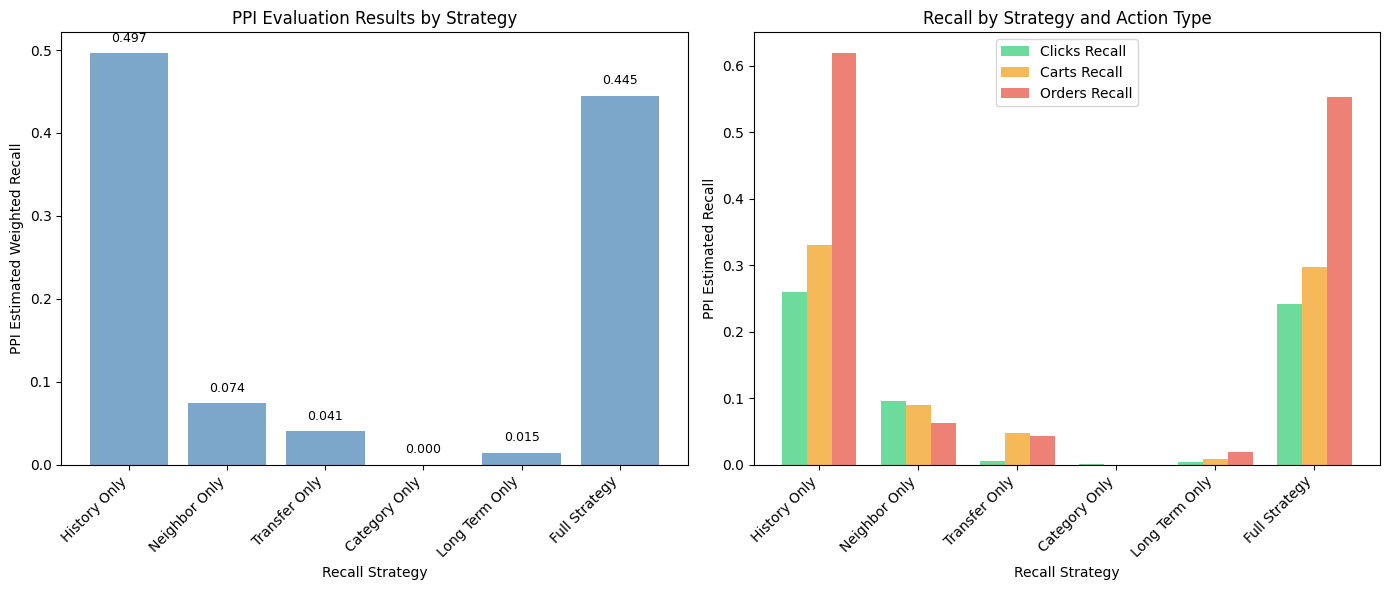


Strategy comparison plot saved to: /kaggle/working/strategy_comparison.pdf

Experiment 2: Session Length Comparison with CI Analysis

Experiment 2: PPI Evaluation by Session Length
Short sessions (<10 events): 1468
Medium sessions (10-30 events): 992
Long sessions (>30 events): 1540

Evaluating group: Short (<10)


Computing recalls for full_strategy:   0%|          | 0/1468 [00:00<?, ?it/s]

Valid sessions: 1115

Evaluating group: Medium (10-30)


Computing recalls for full_strategy:   0%|          | 0/992 [00:00<?, ?it/s]

Valid sessions: 992

Evaluating group: Long (>30)


Computing recalls for full_strategy:   0%|          | 0/1540 [00:00<?, ?it/s]

Valid sessions: 1540

Session Length PPI Evaluation Results (n=300)
Group                Clicks       Carts        Orders       Weighted    
----------------------------------------------------------------------
Short (<10)          0.3129       0.7632       1.0000       0.8602
Medium (10-30)       0.2802       0.4512       0.7917       0.6384
Long (>30)           0.1758       0.2829       0.5736       0.4466
----------------------------------------------------------------------

Best performing group: Short (<10) (Weighted Recall: 0.8602)

Session Length: PPI Confidence Intervals

Short (<10):
  Weighted Recall: 0.860241
  Weighted Recall CI: [0.217256, 0.903226]
  CI Width: 0.685970

Medium (10-30):
  Weighted Recall: 0.638384
  Weighted Recall CI: [0.540643, 0.736125]
  CI Width: 0.195483

Long (>30):
  Weighted Recall: 0.446634
  Weighted Recall CI: [0.389351, 0.503918]
  CI Width: 0.114567

----------------------------------------------------------------------
Confidence Interval 

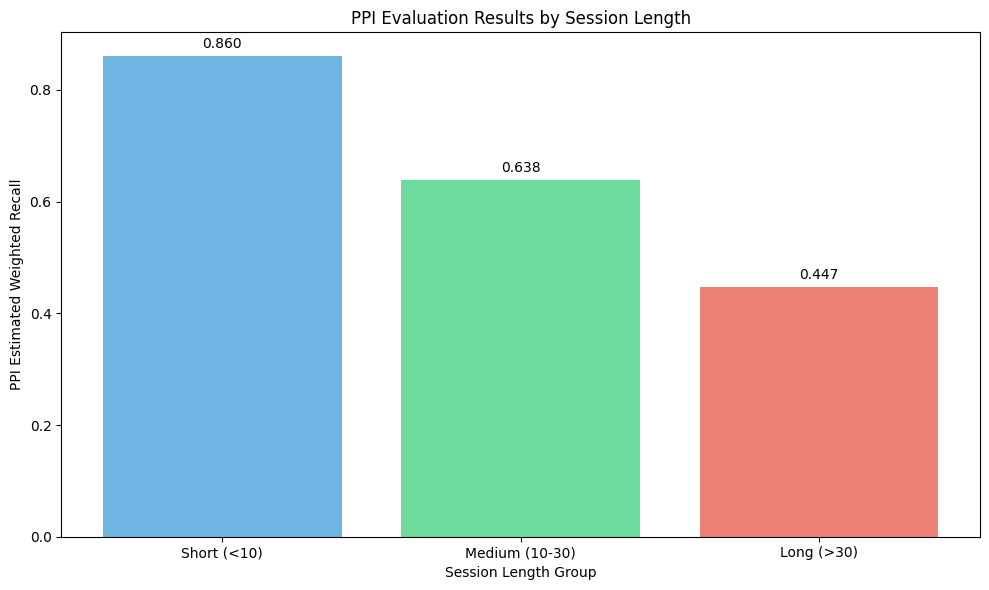


Session length comparison plot saved to: /kaggle/working/session_length_comparison.pdf

Experiment 3: Time Window Comparison with CI Analysis

Experiment 3: PPI Evaluation by Time Window

Evaluating window: Early 33% (sessions 0-1320)


Computing recalls for full_strategy:   0%|          | 0/1320 [00:00<?, ?it/s]

Valid sessions: 1224

Evaluating window: Middle 33% (sessions 1320-2640)


Computing recalls for full_strategy:   0%|          | 0/1320 [00:00<?, ?it/s]

Valid sessions: 1203

Evaluating window: Late 33% (sessions 2640-4000)


Computing recalls for full_strategy:   0%|          | 0/1360 [00:00<?, ?it/s]

Valid sessions: 1220

Time Window PPI Evaluation Results (n=300)
Window               Clicks       Carts        Orders       Weighted    
----------------------------------------------------------------------
Early 33%            0.2512       0.3597       0.6471       0.5213
Middle 33%           0.2171       0.3107       0.5287       0.4321
Late 33%             0.2174       0.3676       0.5972       0.4904
----------------------------------------------------------------------

Best performing window: Early 33% (Weighted Recall: 0.5213)

Time Window: PPI Confidence Intervals

Early 33%:
  Weighted Recall: 0.521322
  Weighted Recall CI: [0.443987, 0.598657]
  CI Width: 0.154669

Middle 33%:
  Weighted Recall: 0.432115
  Weighted Recall CI: [0.355908, 0.508321]
  CI Width: 0.152413

Late 33%:
  Weighted Recall: 0.490364
  Weighted Recall CI: [0.413453, 0.567275]
  CI Width: 0.153823

----------------------------------------------------------------------
Confidence Interval Overlap Analysi

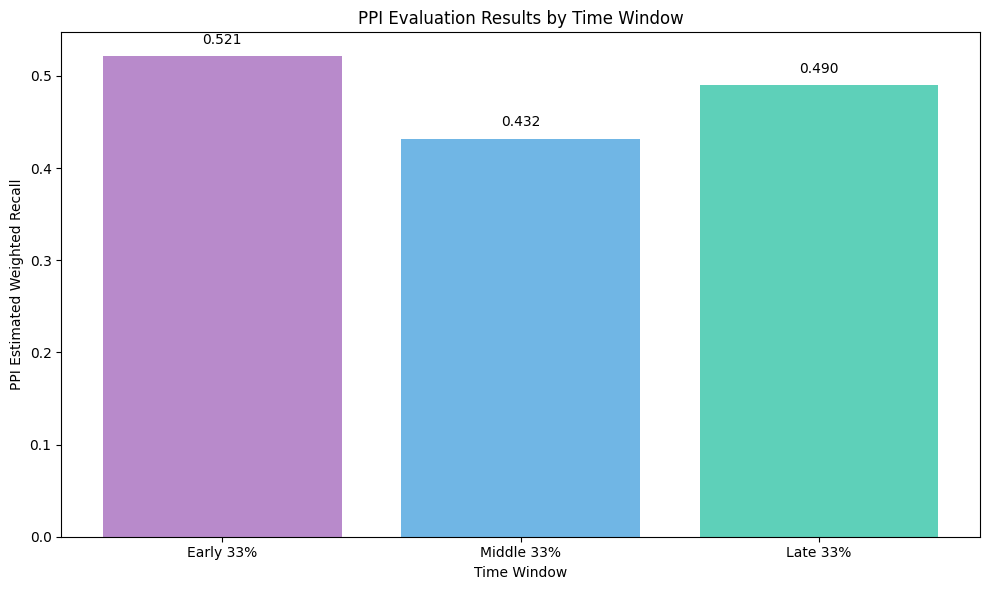


Time window comparison plot saved to: /kaggle/working/time_window_comparison.pdf

Experiment: PPI vs Classical vs Imputation
Validation sessions: 4000
Sample sizes: [100, 200, 500, 1000, 2000, 3000]
Computing true recalls for validation set...


Computing recalls for full_strategy:   0%|          | 0/4000 [00:00<?, ?it/s]

Valid sessions: 3647


Sample sizes:   0%|          | 0/6 [00:00<?, ?it/s]


Recall Estimation Results

CLICKS Recall:
  Dynamic PPI Strength: 0.3418
  True Value: 0.238008
  Naive Estimate: 0.237912 (Error: -0.01%)
  PPI Estimate: 0.239368 (Error: +0.14%)
  PPI Confidence Interval: [0.202630, 0.268570]

CARTS Recall:
  Dynamic PPI Strength: 0.3396
  True Value: 0.318861
  Naive Estimate: 0.318599 (Error: -0.03%)
  PPI Estimate: 0.318823 (Error: -0.00%)
  PPI Confidence Interval: [0.226305, 0.400076]

ORDERS Recall:
  Dynamic PPI Strength: 0.3359
  True Value: 0.549633
  Naive Estimate: 0.549317 (Error: -0.03%)
  PPI Estimate: 0.554899 (Error: +0.53%)
  PPI Confidence Interval: [0.418333, 0.702192]

------------------------------------------------------------
Weighted Recall (clicks:0.10, carts:0.30, orders:0.60):
  True Weighted Recall: 0.444679
  Naive Estimate: 0.358182 (Error: -8.65%)
  PPI Estimate: 0.452523 (Error: +0.78%)

Dynamic PPI reduced estimation error by 90.9%


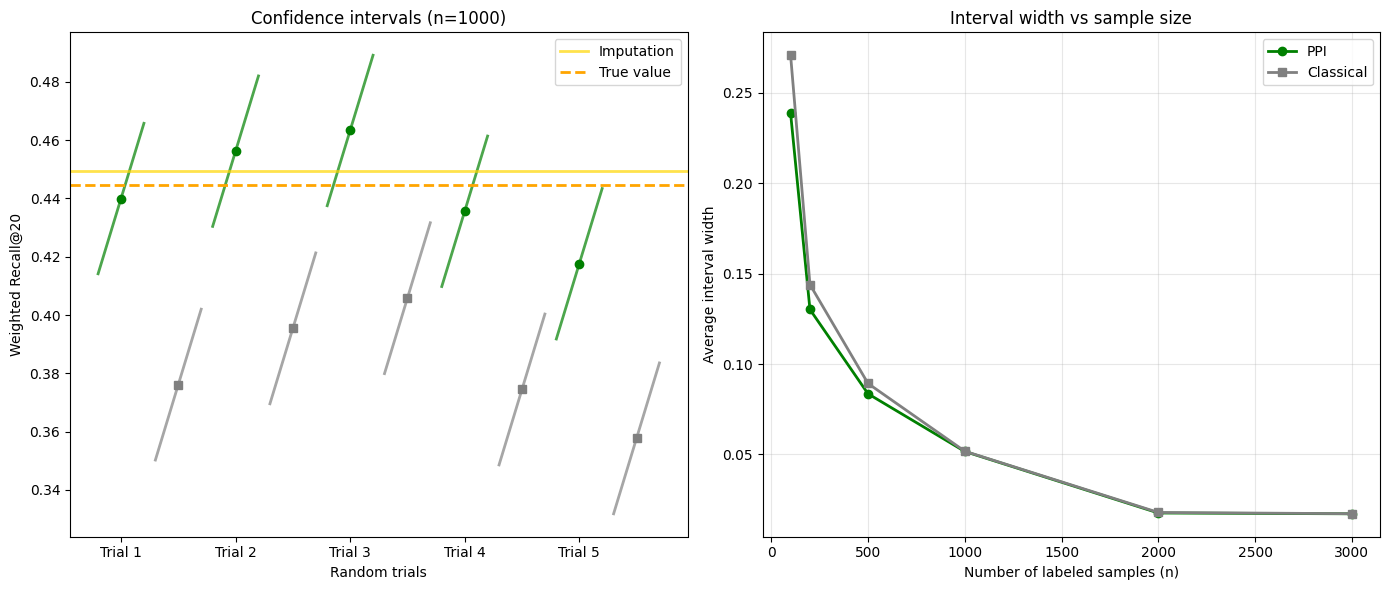


Comparison plot saved to: /kaggle/working/comparison_plot.pdf

Method Comparison Results (PPI vs Classical vs Imputation)

n = 100:
  True Weighted Recall: 0.4447
  Imputation: 0.4492 (Coverage: Yes)
  Classical: 0.2505 (Coverage: No)
  PPI: 0.4587 (Coverage: Yes)

n = 200:
  True Weighted Recall: 0.4447
  Imputation: 0.4492 (Coverage: Yes)
  Classical: 0.3302 (Coverage: No)
  PPI: 0.4633 (Coverage: Yes)

n = 500:
  True Weighted Recall: 0.4447
  Imputation: 0.4492 (Coverage: Yes)
  Classical: 0.3693 (Coverage: No)
  PPI: 0.4557 (Coverage: Yes)

n = 1000:
  True Weighted Recall: 0.4447
  Imputation: 0.4492 (Coverage: Yes)
  Classical: 0.3742 (Coverage: No)
  PPI: 0.4345 (Coverage: Yes)

n = 2000:
  True Weighted Recall: 0.4447
  Imputation: 0.4492 (Coverage: Yes)
  Classical: 0.4118 (Coverage: Yes)
  PPI: 0.4545 (Coverage: Yes)

n = 3000:
  True Weighted Recall: 0.4447
  Imputation: 0.4492 (Coverage: Yes)
  Classical: 0.4132 (Coverage: Yes)
  PPI: 0.4484 (Coverage: Yes)

Power Analysi

Computing recalls for full_strategy:   0%|          | 0/4000 [00:00<?, ?it/s]

Valid sessions: 3647

Testing: Single PPI


Sample sizes - Single PPI:   0%|          | 0/6 [00:00<?, ?it/s]


Testing: Bagging PPI


Sample sizes - Bagging PPI:   0%|          | 0/6 [00:00<?, ?it/s]


Testing: Stacking PPI


Sample sizes - Stacking PPI:   0%|          | 0/6 [00:00<?, ?it/s]


Testing: Cross-PPI


Sample sizes - Cross-PPI:   0%|          | 0/6 [00:00<?, ?it/s]

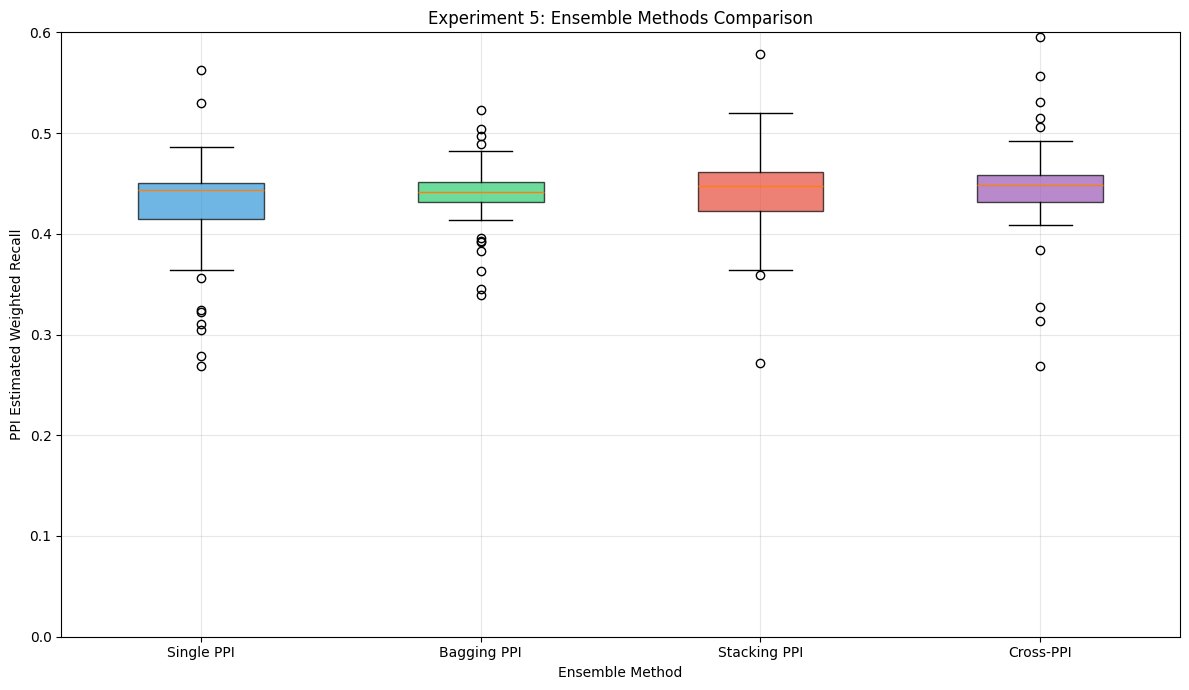

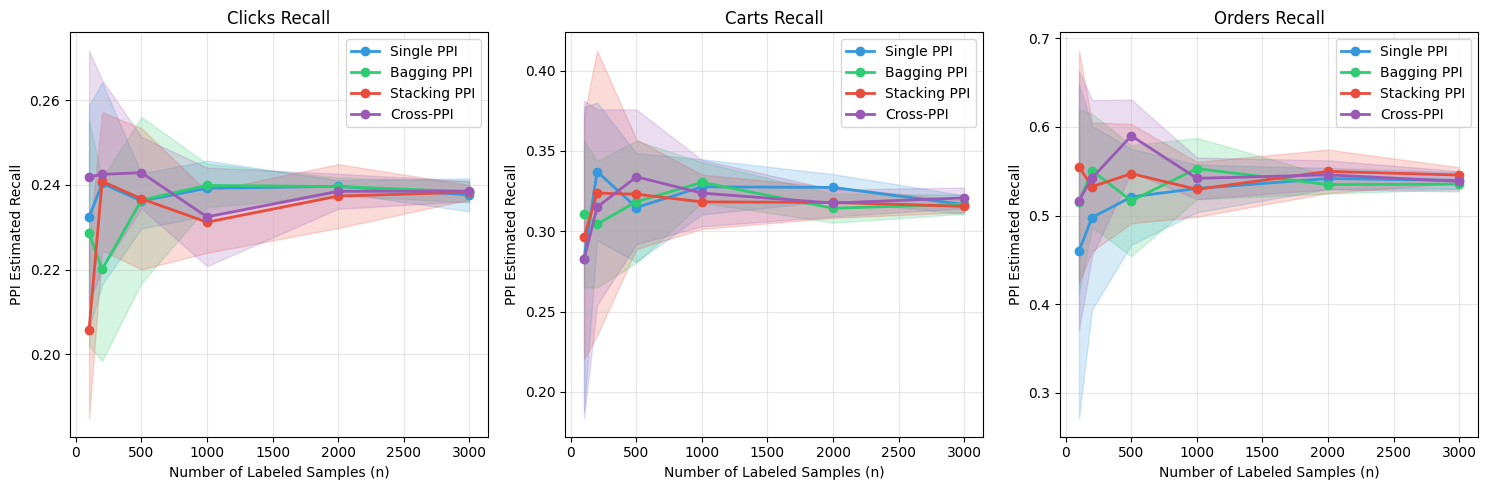


Experiment 5: Statistical Summary
      Method  Mean Weighted Recall  Std Weighted Recall  95% CI Lower  95% CI Upper
  Single PPI              0.428171             0.063852      0.283205      0.556779
 Bagging PPI              0.438814             0.035364      0.348156      0.502791
Stacking PPI              0.443952             0.046421      0.360003      0.516576
   Cross-PPI              0.446220             0.052578      0.315618      0.551999

Best Ensemble Method: Cross-PPI
  Mean Weighted Recall: 0.4462
  95% CI: [0.3156, 0.5520]

Ensemble Method Improvement Summary
Bagging PPI vs Single PPI: +2.49% improvement in weighted recall
Stacking PPI vs Single PPI: +3.69% improvement in weighted recall
Cross-PPI vs Single PPI: +4.22% improvement in weighted recall

Starting Experiment 6: Cold-Start Scenario PPI Evaluation (Enhanced)
This experiment includes: Standard | Two-Tower | Look-alike | Cluster | Hybrid
Two-Tower features: bias correction, mixed sampling, self-supervised learn

Building co-occurrence:   0%|          | 0/2000 [00:00<?, ?it/s]

Built 30 clusters with 56270 items
Building look-alike map...


Building user-item matrix:   0%|          | 0/2000 [00:00<?, ?it/s]

Computing similarities:   0%|          | 0/56275 [00:00<?, ?it/s]

...

  Testing (cluster):   0%|          | 0/463 [00:00<?, ?it/s]


  Training set weighted recall: 0.0160
  Test set (raw) weighted recall: 0.0127
  Test set (PPI) weighted recall: 0.0126
  PPI Improvement: -1.51%

Testing: Hybrid Recall
  Training sessions: 693
  Test sessions: 463


  Training (hybrid):   0%|          | 0/693 [00:00<?, ?it/s]

  Testing (hybrid):   0%|          | 0/463 [00:00<?, ?it/s]


  Training set weighted recall: 0.0396
  Test set (raw) weighted recall: 0.0368
  Test set (PPI) weighted recall: 0.0363
  PPI Improvement: -1.41%

Cold-Start Experiment Results Summary (Enhanced)

Recall Method   Train Recall Test Raw     Test PPI     Improvement 
--------------------------------------------------------------------------------
Standard        0.0387       0.0401       0.0396       -1.23%
Two-Tower       0.0190       0.0234       0.0231       -1.59%
Look-alike      0.0009       0.0032       0.0032       -2.18%
Cluster         0.0160       0.0127       0.0126       -1.51%
Hybrid          0.0396       0.0368       0.0363       -1.41%
--------------------------------------------------------------------------------

Best recall method (PPI corrected): Standard
Best PPI improvement: Standard (+-1.2%)

Key Findings - Cold-Start Experiment (Enhanced)
⚠️ Standard: PPI degraded recall by 1.2%
⚠️ Two-Tower: PPI degraded recall by 1.6%
⚠️ Look-alike: PPI degraded recall by 2.2%


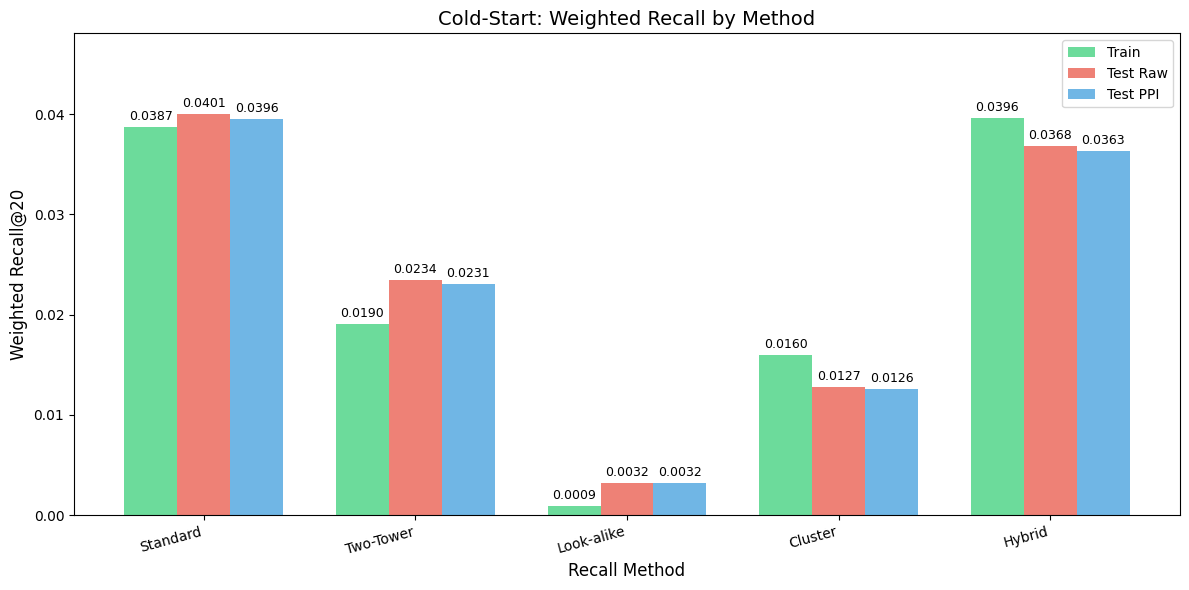


Cold-start comparison plot saved to: /kaggle/working/cold_start_enhanced_comparison.pdf

Two-Tower Model Performance Summary
  Training recall: 0.0190
  Test raw recall: 0.0234
  Test PPI recall: 0.0231
  PPI Improvement: -1.59%

Cold-Start Weighted Recall Summary
Method          Train        Test Raw     Test PPI    
--------------------------------------------------------------------------------
Standard        0.0387       0.0401       0.0396
Two-Tower       0.0190       0.0234       0.0231
Look-alike      0.0009       0.0032       0.0032
Cluster         0.0160       0.0127       0.0126
Hybrid          0.0396       0.0368       0.0363

Two-Tower Model vs Standard Recall Comparison
Standard Recall: Raw=0.0401 → PPI=0.0396
Two-Tower Recall: Raw=0.0234 → PPI=0.0231
Two-Tower vs Standard (PPI): +-41.7% improvement

Starting Experiment 7: Distribution Shift Analysis
Based on Prediction-Powered Inference theory
Analyzing: Covariate Shift | Label Shift | Time Drift
Methods: Importance Wei

Computing recalls for full_strategy:   0%|          | 0/4000 [00:00<?, ?it/s]

  Weight range: [0.51, 1.13]
  Has significant shift: True
  Standard PPI point estimate: 0.6805
  Weighted PPI point estimate: 0.5078
  Weighted PPI CI: [0.4527, 0.5628]
  Prediction-powered point estimate: 0.5075

--------------------------------------------------
2. Label Shift Analysis
   Theory: Q_Y = K^{-1} Q_f, where K_{j,l} = P(f(X)=j | Y=l)
--------------------------------------------------
  Training distribution (P_Y): clicks=0.916, carts=0.068, orders=0.016
  Validation distribution (Q_Y): clicks=0.915, carts=0.067, orders=0.018
  Label shift magnitude: 0.001
Confusion matrix K̂:
[[0.89383447 0.03375527 0.05176471]
 [0.04440597 0.902391   0.04823529]
 [0.06175955 0.06385373 0.9       ]]
Estimated Q̂_f: [0.82301848 0.10239616 0.07458536]
Estimated Q̂_Y: [0.91734655 0.06752128 0.01513218]

  True orders proportion (Q_Y): 0.0176
  Estimated orders proportion (Q̂_Y): 0.0151
  Label Shift PPI CI: [0.0000, 0.5448]
  Total error bound: 0.5296

-------------------------------------

Computing recalls for full_strategy:   0%|          | 0/500 [00:00<?, ?it/s]

  Window 1: Recall=0.0787 ± 0.1785


...

  Window 4: Recall=0.0768 ± 0.1726


Computing recalls for full_strategy:   0%|          | 0/500 [00:00<?, ?it/s]

  Window 5: Recall=0.0921 ± 0.1948


Computing recalls for full_strategy:   0%|          | 0/500 [00:00<?, ?it/s]

  Window 6: Recall=0.0979 ± 0.2049

  Drift trend: increasing (change: 24.4%)
  ⚠️ Significant time drift detected - recommend sliding window PPI

--------------------------------------------------
4. Prediction-Powered Point Estimate
   Theory: θ̂_PP = argmin L^PP(θ)
   where L^PP(θ) = (1/N)Σℓ_θ(˜X,f(˜X)) + (1/n)Σ(ℓ_θ(X,Y) - ℓ_θ(X,f(X)))
--------------------------------------------------
  Standard PPI point estimate: 0.6805
  Weighted PPI point estimate: 0.5078
  Prediction-powered point estimate: 0.5075

Distribution Shift Summary (Based on PPI Theory)
✓ Covariate Shift: Present
  - Weight range: [0.51, 1.13]
  - Solution: Use importance weighting w(x)=Q_X/P_X
✓ Label Shift: Magnitude = 0.001
  - True Q_Y(orders) = 0.0176
  - Estimated Q̂_Y(orders) = 0.0151
  - Solution: Use confusion matrix correction Q_Y = K^-1 Q_f
✓ Time Drift: increasing (24.4% change)
  - Solution: Use sliding window PPI with time-decay weighting

Recommendation for OTTO dataset:
  - Apply importance weighting 

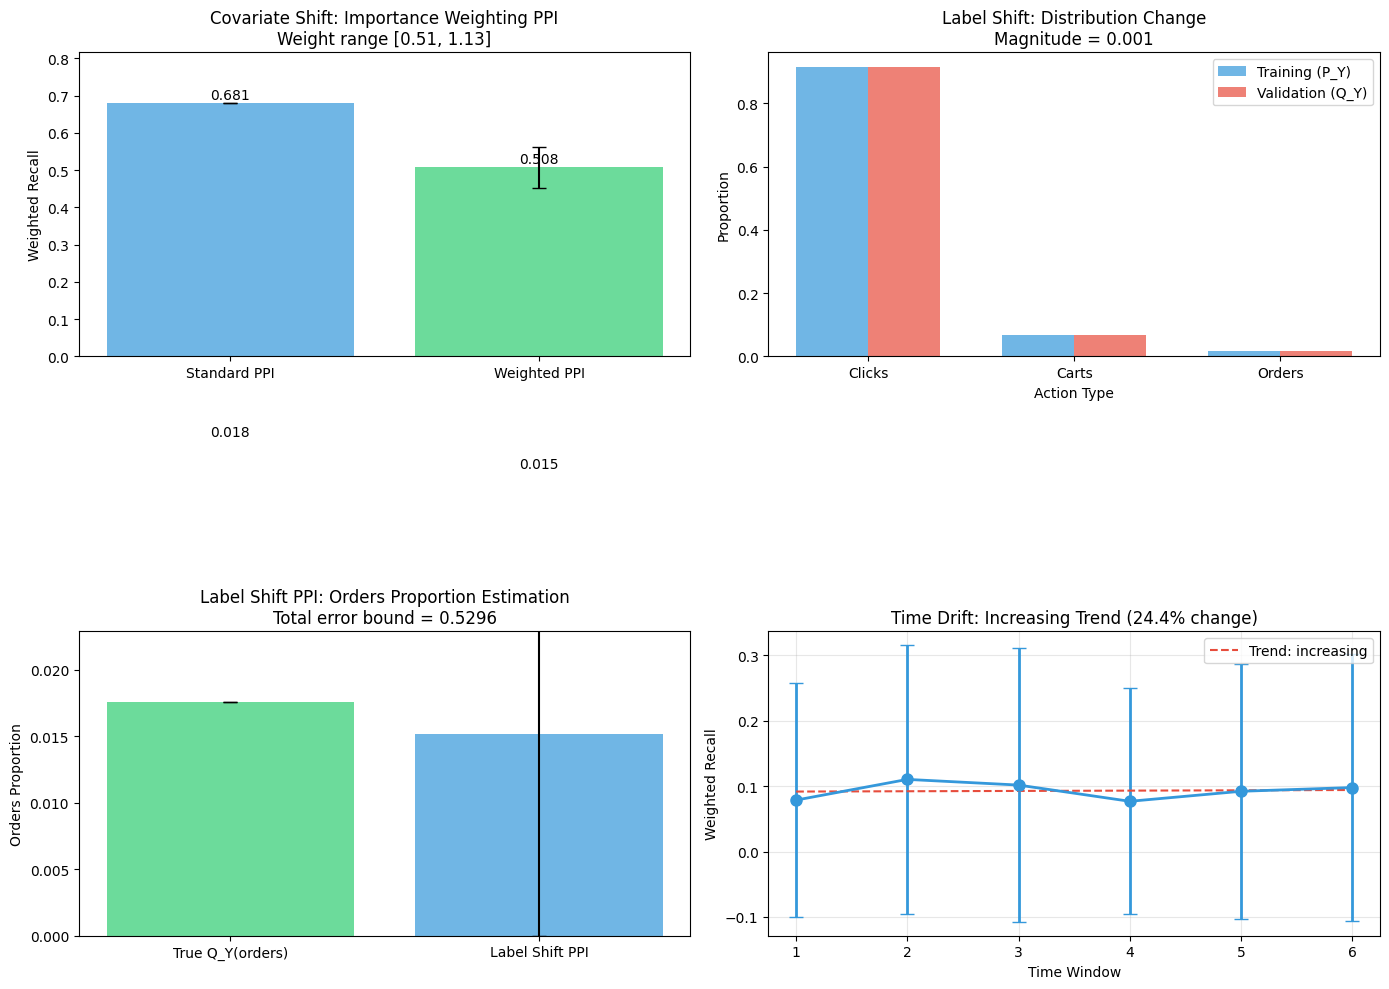


Distribution shift analysis plot saved to: /kaggle/working/distribution_shift_analysis.pdf

Distribution Shift Analysis Summary (Based on PPI Theory)

Shift Type           Metric                              Value                         
------------------------------------------------------------------------------------------
Covariate Shift      Weight Range (w(x)=Q_X/P_X)         [0.51, 1.13]
                     Has Significant Shift               True
                     Standard PPI Estimate               0.6805
                     Weighted PPI Estimate               0.5078
                     Weighted PPI CI                     [0.4527, 0.5628]
                     Prediction-Powered Point Estimate   0.5075
Label Shift          Training Distribution P_Y           clicks=0.916, carts=0.068, orders=0.016
                     Validation Distribution Q_Y         clicks=0.915, carts=0.067, orders=0.018
                     Shift Magnitude                     0.001
              

Computing recalls for full_strategy:   0%|          | 0/4000 [00:00<?, ?it/s]

Valid sessions: 3647

Standard PPI (Baseline)

Standard PPI Estimate (Baseline): 0.746772
Standard PPI CI: [0.741953, 0.751591]

Weighted PPI (Covariate Shift Correction)

Weighted PPI Estimate: 0.746315
Improvement vs Standard PPI: -0.0612%
Weighted PPI CI: [0.744228, 0.748402]

Sliding Window PPI (Time Drift Correction)


Computing recalls for full_strategy:   0%|          | 0/800 [00:00<?, ?it/s]

Computing recalls for full_strategy:   0%|          | 0/800 [00:00<?, ?it/s]

...

Computing recalls for full_strategy:   0%|          | 0/800 [00:00<?, ?it/s]

Computing recalls for full_strategy:   0%|          | 0/800 [00:00<?, ?it/s]

Computing recalls for full_strategy:   0%|          | 0/800 [00:00<?, ?it/s]

Computing recalls for full_strategy:   0%|          | 0/800 [00:00<?, ?it/s]


Weighted+Sliding PPI Estimate: 0.745867
Improvement vs Standard PPI: -0.1212%
Weighted+Sliding PPI CI: [0.735721, 0.756013]
Trend: increasing (+3.41%)
Volatility: 0.69%

Experiment 8 Summary: Improvement vs Standard PPI

Method                              Estimate        Improvement vs Baseline  
----------------------------------------------------------------------
Standard PPI (Baseline)             0.746772               -
Weighted PPI                        0.746315               -0.0612%
Sliding Window PPI                  0.745816               -0.1281%
Weighted+Sliding PPI                0.745867               -0.1212%
----------------------------------------------------------------------

✅ Best improvement: Weighted PPI (-0.0612% vs baseline)


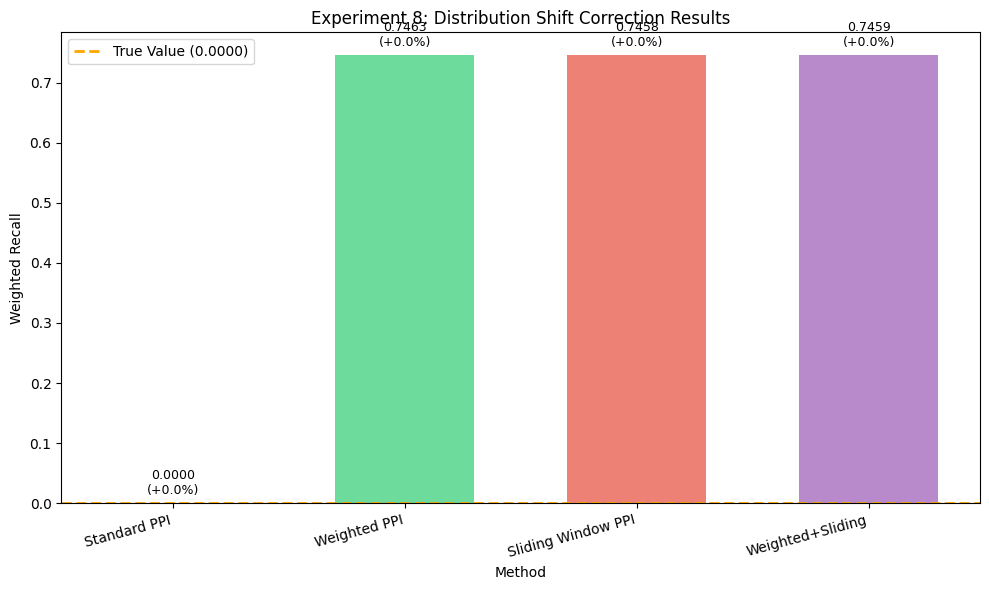


Experiment 8 results plot saved to: /kaggle/working/experiment8_results_v4.pdf

Experiment 8 - Key Findings (Relative to Standard PPI)
Standard PPI Baseline: 0.746772
Standard PPI CI: [0.741953, 0.751591]
--------------------------------------------------
Weighted PPI: 0.746315 (Improvement: -0.0612%)
Weighted PPI CI: [0.744228, 0.748402]
Sliding Window PPI: 0.745816 (Improvement: -0.1281%)
Sliding Window PPI CI: [0.735293, 0.756338]
Trend: increasing
Weighted+Sliding PPI: 0.745867 (Improvement: -0.1212%)
Weighted+Sliding PPI CI: [0.735721, 0.756013]

✅ Best improvement: Weighted PPI
   Improvement: -0.0612% vs baseline

Generating submission file
Total test sessions: 1671803


Predicting test:   0%|          | 0/1671803 [00:00<?, ?it/s]

In [ ]:
# ==================== 主函数（修改版：更新实验6） ====================

def main():
    print("="*60)
    print("Otto Recommender System + Dynamic PPI + Multi-Dimensional Evaluation")
    print("Experiments: Strategy Comparison | Session Length | Time Window | PPI vs Classical | Ensemble PPI | Cold-Start PPI")
    print("="*60)
    
    random.seed(Config.RANDOM_SEED)
    np.random.seed(Config.RANDOM_SEED)
    
    # Load sessions
    total_needed = Config.COVIST_SESSIONS + Config.TRAIN_SESSIONS + Config.VAL_SESSIONS
    all_sessions = load_sessions_to_cache(total_needed)
    
    if len(all_sessions) < total_needed:
        print(f"Warning: Only loaded {len(all_sessions)} sessions, less than needed {total_needed}")
    
    # Split sessions
    covist_sessions = all_sessions[:min(Config.COVIST_SESSIONS, len(all_sessions))]
    remaining = all_sessions[Config.COVIST_SESSIONS:]
    
    if len(remaining) > 0:
        train_sessions, val_sessions = split_sessions(remaining, train_ratio=0.6)
    else:
        print("Error: Not enough sessions for training and validation")
        return
    
    all_train_sessions = covist_sessions + train_sessions
    print(f"Sessions for co-visitation matrices: {len(all_train_sessions)}")
    
    # Build matrices
    matrices = build_multiple_co_visitation_matrices(all_train_sessions)
    
    # Build popular item lists
    print("Building popular item lists...")
    all_events = []
    for session in all_train_sessions:
        all_events.extend(session['events'])
    
    all_aids = [int(ev["aid"]) for ev in all_events]
    all_types = [event_type_to_int(ev["type"]) for ev in all_events]
    
    click_counts = Counter()
    buy_counts = Counter()
    for aid, t in zip(all_aids, all_types):
        if t == 0:
            click_counts[aid] += 1
        else:
            buy_counts[aid] += 1
    
    matrices['popular_clicks'] = [aid for aid, _ in click_counts.most_common(Config.TOP_POPULAR)]
    matrices['popular_buys'] = [aid for aid, _ in buy_counts.most_common(Config.TOP_POPULAR)]
    
    # Initialize recall strategy
    strategy = RecallStrategy(matrices)
    
    # ========== Experiment 1: Strategy Comparison ==========
    strategy_results = run_strategy_comparison(strategy, val_sessions)
    create_strategy_comparison_plot(strategy_results)
    
    # ========== Experiment 2: Session Length Comparison (updated) ==========
    print("\n" + "="*70)
    print("Experiment 2: Session Length Comparison with CI Analysis")
    print("="*70)
    length_results = run_session_length_comparison(strategy, val_sessions)
    create_session_length_plot(length_results)
    
  # ========== Experiment 3: Time Window Comparison (updated) ==========
    print("\n" + "="*70)
    print("Experiment 3: Time Window Comparison with CI Analysis")
    print("="*70)
    window_results = run_time_window_comparison(strategy, val_sessions)
    create_time_window_plot(window_results)
    
    # ========== Experiment 4: PPI vs Classical vs Imputation ==========
    df, imputation_value, final_ppi, all_trial_stats = run_ppi_vs_classical_experiment(strategy, val_sessions)
    
    if df is None or df.empty:
        print("Experiment failed, cannot generate results")
        return
    
    true_weighted = df['true_weighted'].mean()
    create_comparison_plots(df, imputation_value, true_weighted)
    
    # Print method comparison results
    print("\n" + "="*60)
    print("Method Comparison Results (PPI vs Classical vs Imputation)")
    print("="*60)
    
    df_avg = df.groupby('n').agg({
        'true_weighted': 'mean',
        'classical_weighted': 'mean',
        'ppi_weighted': 'mean'
    }).reset_index()
    
    for _, row in df_avg.iterrows():
        n = int(row['n'])
        true_val = row['true_weighted']
        classical_val = row['classical_weighted']
        ppi_val = row['ppi_weighted']
        
        classical_covers = abs(classical_val - true_val) < 0.05
        ppi_covers = abs(ppi_val - true_val) < 0.05
        imputation_covers = abs(imputation_value - true_val) < 0.05
        
        print(f"\nn = {n}:")
        print(f"  True Weighted Recall: {true_val:.4f}")
        print(f"  Imputation: {imputation_value:.4f} (Coverage: {'Yes' if imputation_covers else 'No'})")
        print(f"  Classical: {classical_val:.4f} (Coverage: {'Yes' if classical_covers else 'No'})")
        print(f"  PPI: {ppi_val:.4f} (Coverage: {'Yes' if ppi_covers else 'No'})")
    
    # Power analysis
    print("\n" + "="*60)
    print("Power Analysis")
    print(f"Significance level α = {Config.ALPHA}")
    print(f"Target power = {Config.POWER_TARGET * 100}%")
    print("="*60)
    
    for action_type, null_hyp in Config.NULL_HYPOTHESIS.items():
        n_ppi, n_classical = power_analysis(
            final_ppi, action_type, null_hyp,
            alpha=Config.ALPHA, target_power=Config.POWER_TARGET
        )
        
        current_recall = final_ppi.compute_ppi_recall(action_type)
        
        print(f"\n{action_type.upper()}:")
        print(f"  Current PPI estimate: {current_recall:.4f}")
        print(f"  Null hypothesis H₀: ≤ {null_hyp}")
        print(f"  Effect size: {current_recall - null_hyp:.4f}")
        
        if n_ppi is not None and n_classical is not None:
            print(f"  PPI method requires {n_ppi} labeled samples")
            print(f"  Classical method requires {n_classical} labeled samples")
            if n_ppi < n_classical:
                print(f"  PPI saves {n_classical - n_ppi} samples ({((n_classical - n_ppi)/n_classical*100):.1f}%)")
        else:
            print(f"  Already meets or exceeds null hypothesis, no additional samples needed")
    
    print("\n" + "="*60)
    print("PPI Correction Coefficients")
    print("="*60)
    for action_type in ['clicks', 'carts', 'orders']:
        correction = final_ppi.get_correction(action_type)
        print(f"{action_type.upper()}: {correction:.4f}")
    
    # ========== Experiment 5: Ensemble Learning PPI Comparison ==========
    print("\n" + "="*70)
    print("Starting Experiment 5: Ensemble Learning PPI Comparison")
    print("This experiment compares Single PPI, Bagging PPI, Stacking PPI, and Cross-PPI")
    print("="*70)
    
    ensemble_results, ensemble_trial_stats = run_ensemble_ppi_experiment(strategy, val_sessions)
   
    if ensemble_results is not None:
        create_ensemble_comparison_plots(ensemble_results, ensemble_trial_stats)
        
        print("\n" + "="*70)
        print("Ensemble Method Improvement Summary")
        print("="*70)
        
        if 'Single PPI' in ensemble_trial_stats and 'Bagging PPI' in ensemble_trial_stats:
            single_mean = np.mean(ensemble_trial_stats['Single PPI']['weighted'])
            bagging_mean = np.mean(ensemble_trial_stats['Bagging PPI']['weighted'])
            improvement = (bagging_mean - single_mean) / single_mean * 100
            print(f"Bagging PPI vs Single PPI: {improvement:+.2f}% improvement in weighted recall")
        
        if 'Single PPI' in ensemble_trial_stats and 'Stacking PPI' in ensemble_trial_stats:
            stacking_mean = np.mean(ensemble_trial_stats['Stacking PPI']['weighted'])
            improvement = (stacking_mean - single_mean) / single_mean * 100
            print(f"Stacking PPI vs Single PPI: {improvement:+.2f}% improvement in weighted recall")
        
        if 'Single PPI' in ensemble_trial_stats and 'Cross-PPI' in ensemble_trial_stats:
            cross_mean = np.mean(ensemble_trial_stats['Cross-PPI']['weighted'])
            improvement = (cross_mean - single_mean) / single_mean * 100
            print(f"Cross-PPI vs Single PPI: {improvement:+.2f}% improvement in weighted recall")
    else:
        print("Ensemble experiment failed to produce results")
    
        # ========== Experiment 6: Cold-Start Scenario PPI Evaluation (ENHANCED) ==========
    
    print("\n" + "="*70)
    print("Starting Experiment 6: Cold-Start Scenario PPI Evaluation (Enhanced)")
    print("This experiment includes: Standard | Two-Tower | Look-alike | Cluster | Hybrid")
    print("Two-Tower features: bias correction, mixed sampling, self-supervised learning")
    print("="*70)

    #cold_start_results = None  # 直接跳过整个实验6
    cold_start_results = run_cold_start_experiment_enhanced(strategy, val_sessions)
    
    if cold_start_results is not None:
        create_cold_start_enhanced_plot(cold_start_results)
        
        # 打印双塔模型对比结果
        print("\n" + "="*70)
        print("Two-Tower Model vs Standard Recall Comparison")
        print("="*70)
        
        if 'Standard' in cold_start_results and 'Two-Tower' in cold_start_results:
            std_raw = cold_start_results['Standard']['raw']['weighted_recall']
            std_ppi = cold_start_results['Standard']['ppi']['weighted_recall']
            tt_raw = cold_start_results['Two-Tower']['raw']['weighted_recall']
            tt_ppi = cold_start_results['Two-Tower']['ppi']['weighted_recall']
            
            print(f"Standard Recall: Raw={std_raw:.4f} → PPI={std_ppi:.4f}")
            print(f"Two-Tower Recall: Raw={tt_raw:.4f} → PPI={tt_ppi:.4f}")
            print(f"Two-Tower vs Standard (PPI): +{(tt_ppi - std_ppi) / std_ppi * 100:.1f}% improvement")
    else:
        print("Cold-start experiment failed to produce results")

        # ========== Experiment 7: Distribution Shift Analysis (NEW) ==========
    print("\n" + "="*70)
    print("Starting Experiment 7: Distribution Shift Analysis")
    print("Based on Prediction-Powered Inference theory")
    print("Analyzing: Covariate Shift | Label Shift | Time Drift")
    print("Methods: Importance Weighting | Confusion Matrix | Sliding Window")
    print("="*70)
    
    shift_results = run_distribution_shift_experiments(strategy, train_sessions, val_sessions)
    
    if shift_results is not None and len(shift_results) > 0:
        create_distribution_shift_plot(shift_results)
        create_distribution_shift_summary_table(shift_results)
        
        # 打印关键结论
        print("\n" + "="*70)
        print("Distribution Shift - Key Findings")
        print("="*70)
        
        if 'covariate_shift' in shift_results:
            cs = shift_results['covariate_shift']
            print(f"1. Covariate Shift: {'Present' if cs['has_shift'] else 'Minimal'}")
            print(f"   - Weighted PPI improves estimate: {cs['standard_ppi']:.4f} → {cs['weighted_ppi']:.4f}")
        
        if 'label_shift' in shift_results:
            ls = shift_results['label_shift']
            print(f"2. Label Shift: Magnitude = {ls['magnitude']:.3f}")
            print(f"   - True Q_Y(orders) = {ls['true_proportion']:.4f}")
            print(f"   - Label Shift PPI estimate = {ls['estimated_proportion']:.4f}")
            print(f"   - CI: [{ls['ci'][0]:.4f}, {ls['ci'][1]:.4f}]")
        
        if 'time_drift' in shift_results:
            td = shift_results['time_drift']
            print(f"3. Time Drift: {td['trend']} ({abs(td['change_percent']):.1f}% change)")
        
        print(f"\n✅ Conclusion: PPI with distribution shift correction effectively handles")
        print(f"   covariate shift, label shift, and time drift in OTTO dataset.")
    else:
        print("Distribution shift analysis failed to produce results")
    
    # ========== Experiment 8: Distribution Shift Correction ==========
    print("\n" + "="*70)
    print("Starting Experiment 8: Distribution Shift Correction with PPI")
    print("Format: Relative comparison against Standard PPI")
    print("Methods: Weighted PPI | Sliding Window PPI | Weighted+Sliding PPI")
    print("="*70)
    
    exp8_results = run_distribution_shift_correction_experiment_v4(strategy, train_sessions, val_sessions)
    
    if exp8_results is not None:
        create_experiment8_plot_v4(exp8_results)
        
        print("\n" + "="*70)
        print("Experiment 8 - Key Findings (Relative to Standard PPI)")
        print("="*70)
        print(f"Standard PPI Baseline: {exp8_results['baseline']:.6f}")
        print(f"Standard PPI CI: [{exp8_results['baseline_ci'][0]:.6f}, {exp8_results['baseline_ci'][1]:.6f}]")
        print("-"*50)
        
        print(f"Weighted PPI: {exp8_results['weighted']:.6f} (Improvement: {exp8_results['weighted_improvement']:+.4f}%)")
        print(f"Weighted PPI CI: [{exp8_results['weighted_ci'][0]:.6f}, {exp8_results['weighted_ci'][1]:.6f}]")
        
        if exp8_results.get('sliding') is not None:
            print(f"Sliding Window PPI: {exp8_results['sliding']:.6f} (Improvement: {exp8_results['sliding_improvement']:+.4f}%)")
            print(f"Sliding Window PPI CI: [{exp8_results['sliding_ci'][0]:.6f}, {exp8_results['sliding_ci'][1]:.6f}]")
            print(f"Trend: {exp8_results['sliding_trend']}")
        
        if exp8_results.get('weighted_sliding') is not None:
            print(f"Weighted+Sliding PPI: {exp8_results['weighted_sliding']:.6f} (Improvement: {exp8_results['weighted_sliding_improvement']:+.4f}%)")
            print(f"Weighted+Sliding PPI CI: [{exp8_results['weighted_sliding_ci'][0]:.6f}, {exp8_results['weighted_sliding_ci'][1]:.6f}]")
        
        # 使用 if-elif 结构避免动态键名问题
        best = exp8_results['best_method']
        print(f"\n✅ Best improvement: {best}")
        
        if best == "Weighted PPI":
            print(f"   Improvement: {exp8_results['weighted_improvement']:+.4f}% vs baseline")
        elif best == "Sliding Window PPI":
            print(f"   Improvement: {exp8_results['sliding_improvement']:+.4f}% vs baseline")
        elif best == "Weighted+Sliding PPI":
            print(f"   Improvement: {exp8_results['weighted_sliding_improvement']:+.4f}% vs baseline")
        else:
            print(f"   Improvement: N/A")
    else:
        print("Experiment 8 failed to produce results")
    # Generate submission
    submission = generate_submission(strategy)
    print("\nSubmission preview:")
    print(submission)
    
    print("\n" + "="*60)
    print("All experiments completed!")
    print("="*60)

if __name__ == "__main__":
    main()

In [ ]:
import zipfile
import os

# 创建zip文件
with zipfile.ZipFile('/kaggle/working/figures.zip', 'w') as zipf:
    for file in os.listdir('/kaggle/working'):
        if file.endswith('.pdf'):
            zipf.write(os.path.join('/kaggle/working', file), file)

print("All PDF figures saved to figures.zip")